**Aggregation Model**

In [1]:
## DATA AND PACKAGE IMPORT 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

'''

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

'''

temp_490 = pd.read_excel("Temp_binned.xlsx", sheet_name="4903659")
temp_699 = pd.read_excel("Temp_binned.xlsx", sheet_name="6990636")

sal_490 = pd.read_excel("Sal_binned.xlsx", sheet_name="4903659")
sal_699 = pd.read_excel("Sal_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth_obs = part_conc_490["depth_bin"].iloc[:60]

time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))            # probably won't use all of these profiles
#size_classes = part_conc_490.columns.to_numpy()[1:]
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])

# formatting for plots
font = {'family': 'DejaVu Serif',
        'color': 'k',
        'weight': 'normal',
        'size': 11}
legend_font = font.copy()
legend_font['size'] = font['size'] - 1
legend_font.pop('color', None)

'k'

In [2]:
## SEPARATING FLOAT 490 PROFILES INTO INDIVIDUAL UVP6 DATAFRAMES 
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1 

# Export an individual profile here (in case one needs checking!)
# f699.p8.to_excel("f699.p8.xlsx", index=False) 


In [3]:
## Creating Figures for Presentation

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())



## add ax.scatter to get points on top of the depth gradation

bathy_layers = [
('bathymetry_K_200', '#c6dbef'),
('bathymetry_J_1000', '#9ecae1'),
#('bathymetry_I_2000', '#9ecae1'),
('bathymetry_I_2000', '#6baed6'),


('bathymetry_H_3000', '#4292c6'),]
#('bathymetry_F_5000', '#2171b5'),
#('bathymetry_E_6000', '#08519c'),
#('bathymetry_D_7000', '#08306b'),]


for layer, colour in bathy_layers:

    ax.add_feature(cfeature.NaturalEarthFeature('physical',layer,'10m'),facecolor=colour,edgecolor='none')

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
#ax.add_feature(cfeature.OCEAN) #facecolor='lightblue'
# Bathymetry layers (shallow → deep)

# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree(), zorder=20)
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree(), zorder=20)

# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=21)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=21)

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='black',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016
s1_lon = -24.0004
s2_lat = 60.01922
s2_lon = -23.7194 
s3_lat = 59.43715
s3_lon = -22.6379 
s4_lat = 59.30469
s4_lon = -21.9108 
s5_lat = 60.26593
s5_lon = -21.0875

r1_lat = 56.21604
r1_lon = -26.8302
r2_lat = 57.12564
r2_lon = -26.1376
r3_lat = 57.23220
r3_lon = -28.3443
r4_lat = 59.01343
r4_lon = -24.6674 
r5_lat = 60.12009
r5_lon = -18.9309



ax.scatter(s1_lon, s1_lat, color='black', s=45, label="S1", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(s2_lon, s2_lat, color='black', s=45, label="S2", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(s3_lon, s3_lat, color='black', s=45, label="S3", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(s4_lon, s4_lat, color='black', s=45, label="S4", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(s5_lon, s5_lat, color='black', s=45, label="S5", transform=ccrs.PlateCarree(), zorder=30)

ax.scatter(r1_lon, r1_lat, color='black', s=45, label="R1", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(r2_lon, r2_lat, color='black', s=45, label="R2", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(r3_lon, r3_lat, color='black', s=45, label="R3", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(r4_lon, r4_lat, color='black', s=45, label="R4", transform=ccrs.PlateCarree(), zorder=30)
ax.scatter(r5_lon, r5_lat, color='black', s=45, label="R5", transform=ccrs.PlateCarree(), zorder=30)



# Set extent (optional: zoom to data)
ax.set_extent([
    -30, -15,
    55, 65
])

ax.text(s1_lon, s1_lat, "S1", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(s2_lon, s2_lat, "S2", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(s3_lon, s3_lat, "S3", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(s4_lon, s4_lat, "S4", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(s5_lon, s5_lat, "S5", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(r1_lon, r1_lat, "R1", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(r2_lon, r2_lat, "R2", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(r3_lon, r3_lat, "R3", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(r4_lon, r4_lat, "R4", fontsize=12, ha='left', va='bottom', zorder=31)
ax.text(r5_lon, r5_lat, "R5", fontsize=12, ha='left', va='bottom', zorder=31)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [

    # Float trajectories
    Line2D([0], [0],
           marker='o',
           color='green',
           linestyle='-',
           markersize=6,
           label='Flux_1 (490)'),

    Line2D([0], [0],
           marker='o',
           color='purple',
           linestyle='-',
           markersize=6,
           label='Flux_2 (699)'),

    # Bathymetry
    Patch(facecolor='#c6dbef', label='0-200 m'),
    Patch(facecolor='#9ecae1', label='200-1000 m'),
    Patch(facecolor='#6baed6', label='1000-2000 m'),
    Patch(facecolor='#4292c6', label='2000-3000 m')]

'''
bathy_layers = [
('bathymetry_K_200', '#c6dbef'),
('bathymetry_J_1000', '#9ecae1'),
#('bathymetry_I_2000', '#9ecae1'),
('bathymetry_I_2000', '#6baed6'),


('bathymetry_H_3000', '#4292c6'),]
#('bathymetry_F_5000', '#2171b5'),
#('bathymetry_E_6000', '#08519c'),
#('bathymetry_D_7000', '#08306b'),]
'''

ax.legend(
    handles=legend_handles,
    loc='upper left',
    fontsize=10.5, prop=legend_font)


#plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: April 2024 - Jan 2025")

plt.tight_layout()
plt.savefig("Float_Trajectories_Map.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()
                           
# lost my graph for the powerpoint - rewrite code if needed?

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

KeyboardInterrupt: 

C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\

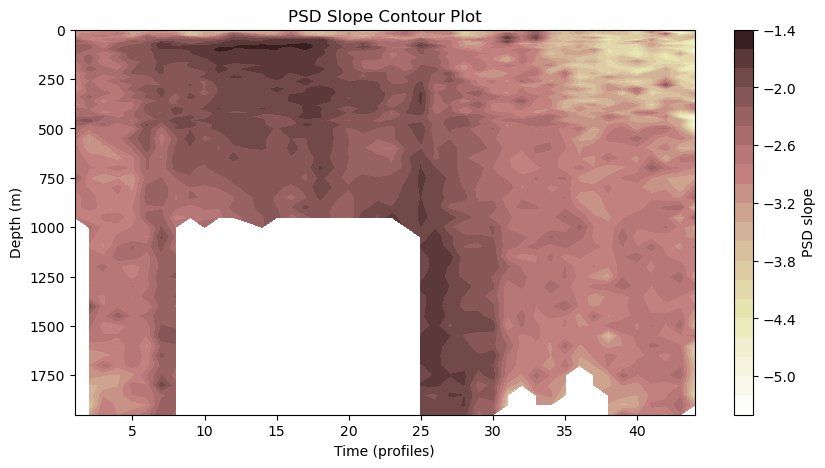

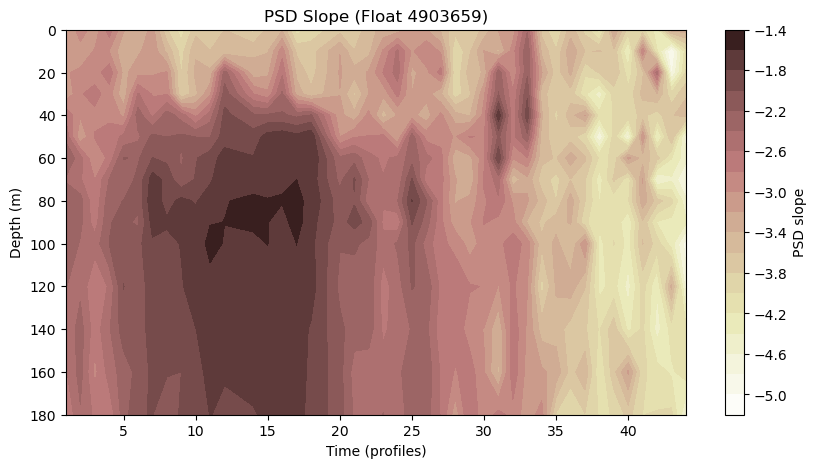

In [3]:
# BIOCARBON playing around
 

# # define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?

# what float profiles match closest with the station locations?

# calculate PSD for each depth across size bins

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    import pandas as pd

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({
        "sizes": sizes,
        "concentrations": concentrations
        })

    
    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform (SAFE in pandas)
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))


    df = df.dropna()

    # Linear regression using pandas (no np.polyfit)
    # slope = covariance(x,y) / variance(x)
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }

test_p1_f490 = pd.to_numeric(f490.p1.iloc[0, 1:], errors='coerce')
#print(psd_slope(size_classes, test_p1_f490))



# Find all .pX attributes
p_keys = [key for key in f490.__dict__.keys() if key.startswith("p")]

all_results = {}

for p_key in p_keys:
    p_df = getattr(f490, p_key)

    # Extract sizes (column headers, skip first column)
    sizes = pd.to_numeric(p_df.columns[1:], errors='coerce')

    slopes = []

    # Loop through ALL rows (depth bins)
    for row in range(p_df.shape[0]):
        concentrations = pd.to_numeric(p_df.iloc[row, 1:], errors='coerce')

        res = psd_slope(sizes, concentrations)
        slopes.append(res["slope"])

    # Store results for this dataset
    all_results[p_key] = slopes

# Create final DataFrame
slope_df = pd.DataFrame(all_results)


# just need to plot and have a look
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth_obs, errors="coerce").to_numpy()

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y)

# Z values
Z = slope_df.to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope Contour Plot")

# Invert depth axis (common in oceanography)
plt.gca().invert_yaxis()

plt.show()



# Plot from first 200 m 
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth_obs, errors="coerce").to_numpy()
Y_shallow = Y[0:15]

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y_shallow)     # specify range that is length of Y and X

# Z values
Z = slope_df.iloc[:15, :].to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.plot()
plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope (Float 4903659)")

# Invert depth axis
plt.gca().invert_yaxis()

plt.show()


**The Old Code Graveyard (where code can be useful but sits here in storage):**

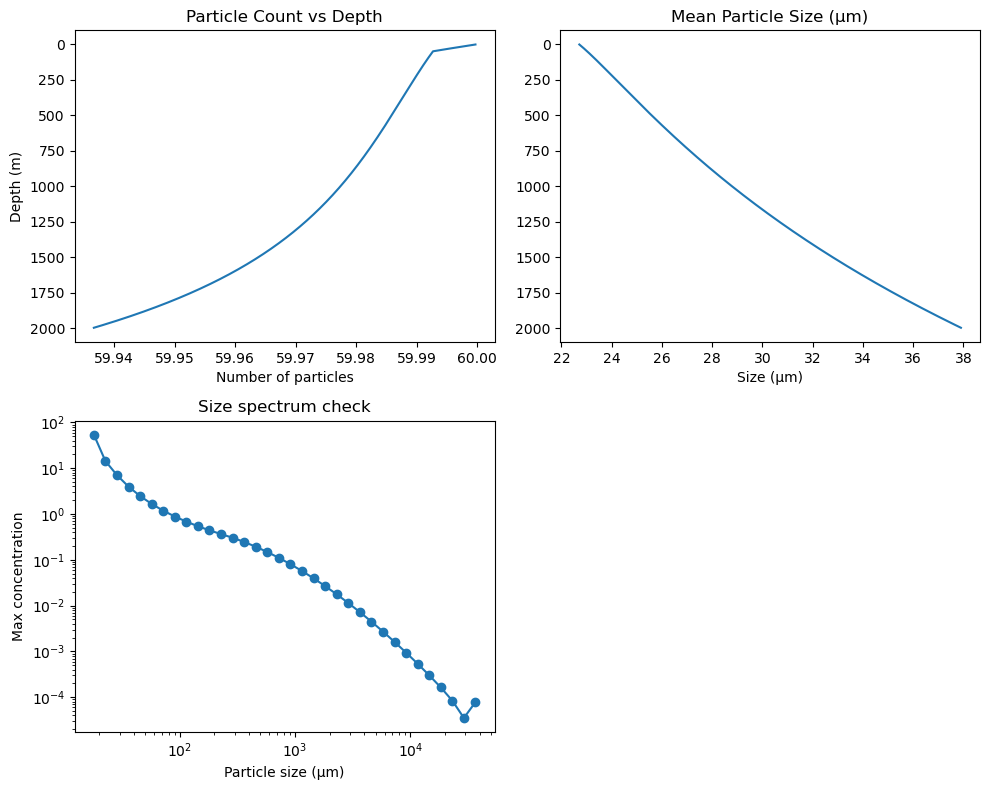

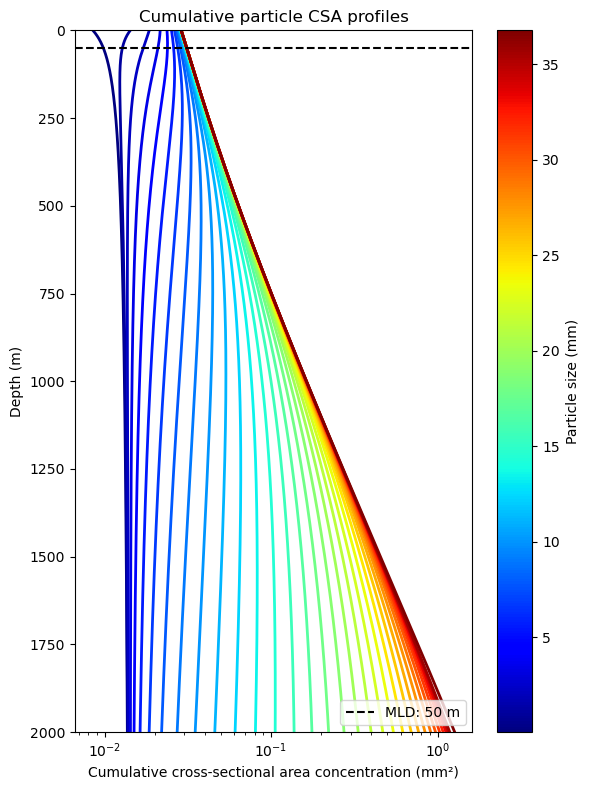

In [ ]:
# ------------------------------
# CREATES SIZE BINS
# ------------------------------
size_bounds = 2 ** np.arange(4, 15 + 1/3, 1/3)    # starting size 16 um, up to 40 mm, in 1/3 log power increments
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:])  # bin centres

radius = size_bins / 2.0  # microns               
radius_m = radius * 1e-6                          # converts radius to m for sinking velocity

n_bins = len(size_bins)                           # 35 size classes

# ---------------------------------------------------
# INITIAL PARTICLE NUMBERS, DISTRIBUTION + PROPERTIES
# ---------------------------------------------------
N0 = 60                                        # starting cross-sectional area of particles

# all particles start in smallest bin
#C = np.zeros(n_bins)
#C[0] = N0

# power-law slope for starting particle distribution
slope = 3.5                                       # n(D) ~ D^-slope, where slope is the exponent of the power-law distribution
# generate power-law distribution
C = (size_bins / size_bins[0]) ** (-slope)
# scale to total number of particles
C = C / np.sum(C) * N0


# -------------------------------------------------------
# INITIAL CSA DISTRIBUTION (for using instead of numbers)
# -------------------------------------------------------

'''
N0 = 30000

M0 = 60

slope = 3.5
Df = 2.0

particle_mass = size_bins**Df

M = (size_bins / size_bins[0]) ** (-slope)
M = M / np.sum(M) * M0
'''

# Mass
"""
particle_mass = size_bins**Df                                       # particle mass of each size bin = size^Df, currently assuming a constant Df between particles
M = N * particle_mass                                               # number of particles in each size class * mass of each size bin (total mass per bin)
"""


# Parameters
Df = 2  # fractal dimension                
rho_f = 1025    # seawater density (kg/m^3)                      
mu = 1e-3       # viscosity (Pa·s)
g = 9.81        # force due to gravity
stick = 0.2

# Density based on fractal dimension
def particle_density(r):
    # reference radius (smallest particle)
    r0 = radius_m[0]
    rho0 = 1050   # density at smallest size

    rho_eff = rho0 * (r / r0)**(Df - 3)

    return max(rho_eff, rho_f + 1)   # prevent particle density < seawater density


# Turbulent shear values                       ## will adapt shear values above MLD and another below MLD, this might need to be included as W m2 or similar
surface_G = 10.0
deep_G = 1.0
MLD = 50  # mixed layer depth (m)    # adapt so this can be read from the relevant float profile/whichever is selected as reference

# ---------------------------------------------------
# DEFINE KERNELS
# ---------------------------------------------------

# experimenting with fractal dimension scaling for settling velocity
def settling_velocity(r):
    rho_eff = particle_density(r)
    return (2/9) * (rho_eff - rho_f) * g * r**2 / mu

def shear_rate(depth):
    return surface_G if depth < MLD else deep_G

def jackson_kernel(r1, r2, depth):
    G = shear_rate(depth)
    
    beta_shear = 1.3 * G * (r1 + r2)**3     # shear aggregation
    
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)
    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)  # diff. settling

    return beta_shear + beta_settle         # total aggregation
    # can add brownian motion if we think it would be relevant

"""
# ------------------------------
# JACKSON KERNEL                                                    # Old kernel which combines the two kernels together
# ------------------------------

def jackson_kernel(r1, r2, depth):                                  # 

    G = shear_rate(depth)                                           # Shear rate for a given depth (either 1 or 10)

    beta_shear = 1.3 * G * (r1 + r2)**3                             # radius of 1 particle and radius of other particle * shear rate

    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)

    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)

    return beta_shear + beta_settle
"""


dz = 2                                    # change in depth (adjust to capture different changes in depth from UVP sample rate?)
z_max = 2000                                # max depth
nz = int(z_max / dz)                        # number of depth steps

# store concentrations at each depth
C_profile = np.zeros((nz, n_bins))       

particle_counts = []
mean_sizes = []
depths = []

# ---------------------------------------------------
# MAIN MODEL LOOP
# ---------------------------------------------------

for z_step in range(nz):
    depth = z_step * dz
    
    C_new = np.zeros_like(C)

    for i in range(n_bins):                        # compares every size bin pair
        for j in range(i, n_bins):

            if C[i] == 0 or C[j] == 0:             # skip if no particles
                continue

            r1, r2 = radius_m[i], radius_m[j]      # collision rates

            beta = jackson_kernel(r1, r2, depth)

            # convert depth step to time via sinking
            w = settling_velocity((r1 + r2) / 2)
            if w <= 0:
                continue

            dt_local = dz / w

            collisions = beta * C[i] * C[j] * dt_local   # no. of collisions

            if i == j:
                collisions *= 0.5  # avoid double counting

            # sticking probability
            agg = stick * collisions

            # ---- limit aggregation ----
            if i == j:
                agg = min(agg, C[i] / 2)      # conserves particle removal
            else:
                agg = min(agg, C[i], C[j])

            # remove particles
            C_new[i] -= agg                   # removes particle from original bin after aggregation
            C_new[j] -= agg

            # new aggregated size
            # new_size = size_bins[i] + size_bins[j]

            m1 = size_bins[i]**Df
            m2 = size_bins[j]**Df

            new_size = (m1 + m2)**(1 / Df)   # not just specifying new_size as diameters added together

            
            # ---- bin assignment (nearest bin centre) ----
            k = np.argmin(np.abs(size_bins - new_size))
            C_new[k] += agg
            """
             # aggregate mass                                    # new mass of aggregate
            new_particle_mass = (particle_mass[i] + particle_mass[j])

            # maybe build a check here that the mass of the new aggregate matches the mass removed from the model?

            # convert aggregate mass -> aggregate size          # 
            new_size = new_particle_mass**(1 / Df)
            """

            '''
            # ---- bin assignment (next bin centre up) ----
            k = np.searchsorted(size_bins, new_size)

            if k >= n_bins:
                C_new[-1] += agg

            elif k == 0:
                C_new[0] += agg

            else:
                lower = size_bins[k-1]
                upper = size_bins[k]

                if upper == lower:
                    frac = 0.5
                else:
                    frac = (new_size - lower) / (upper - lower)

                C_new[k] += agg * frac
                C_new[k-1] += agg * (1 - frac)
                '''

            
    # update concentrations
    C += C_new
    
    # diffusion between size bins
    diffusion = 0.02  # small smoothing factor
    C_diff = np.zeros_like(C)

    for i in range(1, n_bins - 1):
        spread = diffusion * C[i]

        C_diff[i] -= 2 * spread
        C_diff[i-1] += spread
        C_diff[i+1] += spread

    C += C_diff

    # prevent negatives
    C[C < 0] = 0

    # save profile at this depth
    C_profile[z_step, :] = C.copy()     


    # OPTIONAL: allow bin growth (dynamic classes)
    #size_bins = size_bins * (1 + 0.001 * dz)

    # track diagnostics
    total_particles = np.sum(C)
    mean_size = np.sum(C * size_bins) / total_particles if total_particles > 0 else 0

    particle_counts.append(total_particles)
    mean_sizes.append(mean_size)
    depths.append(depth)


## Plotting Figures
    
plt.figure(figsize=(10, 8))

# Particle count vs depth

plt.subplot(2, 2, 1)
plt.plot(particle_counts, depths)
plt.gca().invert_yaxis()
plt.title("Particle Count vs Depth")
plt.xlabel("Number of particles")
plt.ylabel("Depth (m)")

# Mean particle size vs depth

plt.subplot(2, 2, 2)
plt.plot(mean_sizes, depths)
plt.gca().invert_yaxis()
plt.title("Mean Particle Size (µm)")
plt.xlabel("Size (µm)")

# Size Bin behaviour plot

plt.subplot(2, 2, 3)
plt.plot(size_bins, np.max(C_profile, axis=0), marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Particle size (µm)")
plt.ylabel("Max concentration")
plt.title("Size spectrum check")

plt.tight_layout()
plt.show()



# Individual Concentrations per size class over depth
# Calculating Cross-sectional area

# convert size to radius in mm
radius_mm = (size_bins / 2.0) / 1000.0  

# cross-sectional area per particle (mm²)
area_per_particle = np.pi * radius_mm**2  

# compute CSA concentration at each depth (nz x n_bins)
cross_sectional_area = C_profile * area_per_particle



# ---------------------------
# CUMULATIVE STACK PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 8))

# ---- TRANSPOSE FIRST ----
csa_T = cross_sectional_area.T   # (size_bin, depth)

# ---- cumulative stack ----
cumulative = np.cumsum(csa_T, axis=0)

# colour gradient
cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, len(size_bins)))

# plot each size boundary
for i in range(len(size_bins)):
    ax.plot(cumulative[i, :], depths,
            color=colors[i],
            linewidth=2)

# MLD line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD: {MLD} m")

# formatting
ax.set_xlabel("Cumulative cross-sectional area concentration (mm²)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, z_max)
ax.set_xscale("log")
ax.set_title("Cumulative particle CSA profiles")

ax.legend(loc="lower right")

# colourbar
norm = plt.Normalize(vmin=min(size_bins/1000), vmax=max(size_bins/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

ax.invert_yaxis()
plt.tight_layout()
plt.show()
                                                                                                                                        

# if bin growth is needed
# size_bins = size_bins * (1 + growth_rate * dz)


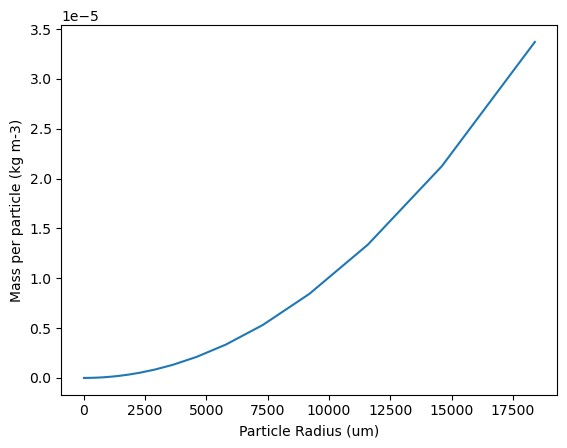

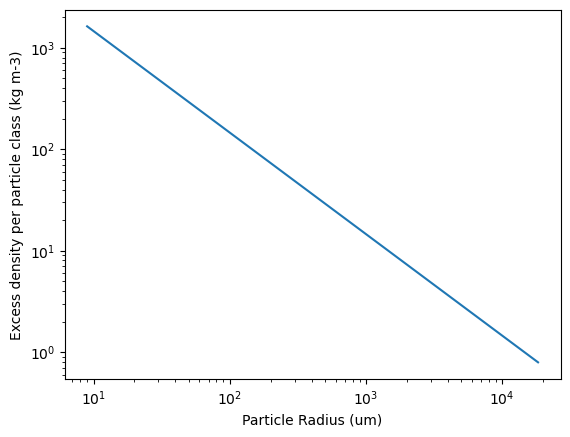

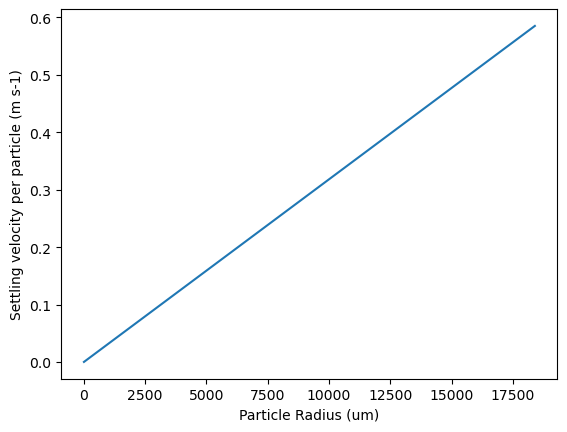

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


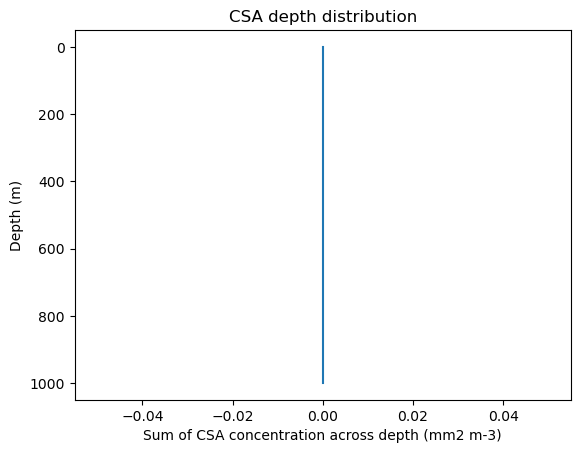

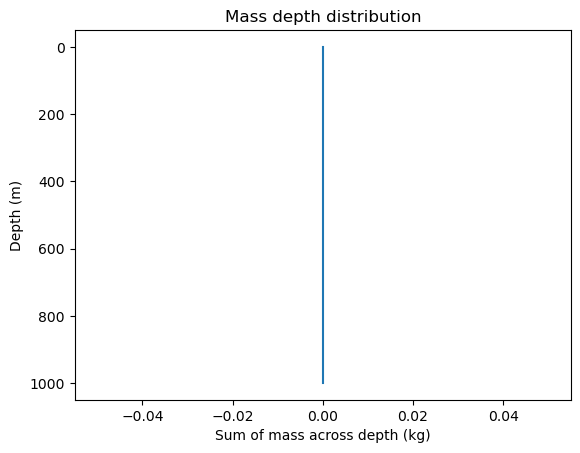

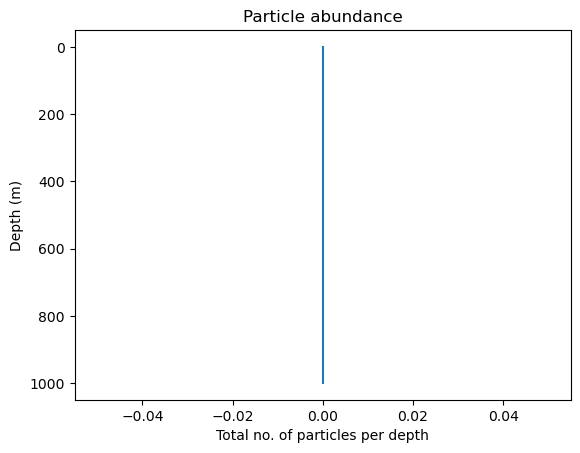

C:\Users\Steffi Hodnett\AppData\Local\Temp\ipykernel_4228\631757875.py:507: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


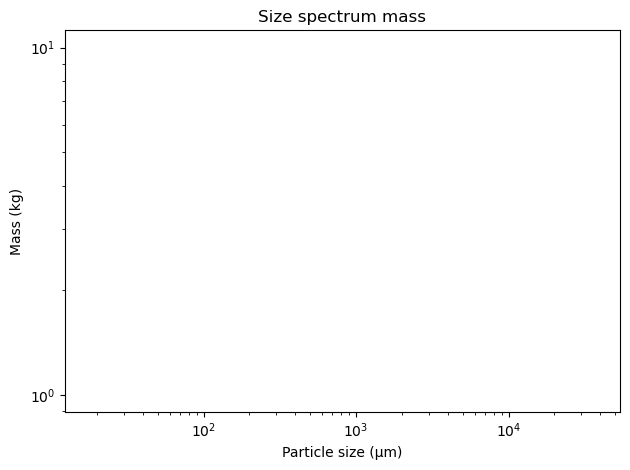

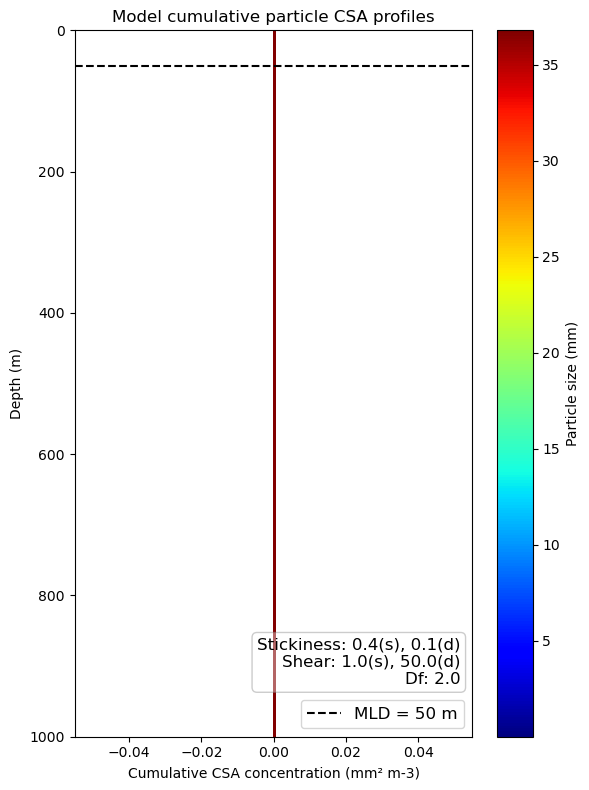

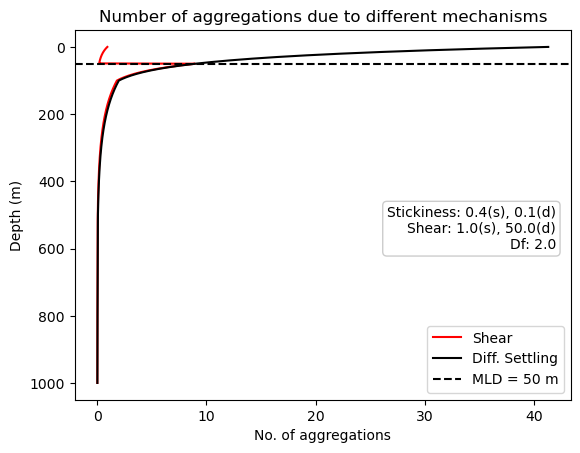

In [ ]:
# MASS MODEL

# ------------------------------
# SIZE BINS
# ------------------------------

size_bounds = 2 ** np.arange(4, 15 + 1/3, 1/3)
# size_bounds = 2 ** np.arange(4, 11, 1)                            # specifies size bins in microns
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:])             # calculates mid-size diameter of each bin as geometric mean (due to log spacing)

radius = size_bins / 2.0                                            # calculates radius from diameter (um)
radius_m = radius * 1e-6                                            # converts radius into metres
radius_mm = radius / 1000                                           # converts radius into mm

area_per_particle = np.pi * radius_mm**2                            # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin

n_bins = len(size_bins)                                             # specifying the number of size bins


# ------------------------------
# PARAMETERS
# ------------------------------
Df = 2.0                                                            # Fractal Dimension
rho_f = 1025                                                        # Seawater Density (kg m-3)
rho0 = 2650                                                         # Primary Particle Density (kg m-3)
mu = 1e-3                                                           # Viscosity of seawater
g = 9.81                                                            # Acceleration due to gravity
surface_a = 0.0                                                     # Stickiness (probability of successful collisions) at the surface
deep_a = 0.1                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1.0                                                    # Turbulent Shear at the surface
deep_G = 50.0                                                        # Turbulent Shear at depth
MLD = 50                                                            # Mixed Layer Depth


# ------------------------------
# INITIAL CSA DISTRIBUTION
# ------------------------------

# Use a CSA spectrum more consistent with UVP data (uses a shallower slope)

CSA0 = 60 #(mm2 m-3)                                                # total starting particle cross-sectional area concentration

CSA_slope = 1.0    # can change back to 3 or 3.5                    # specifies how aggressively the starting distribution varies between small and large particles

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up

# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class

# Mass
r0 = radius_m[0]    #m

V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg

particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle
M = N * particle_mass    # particles m-3 * kg = kg m-3 actually density of particle weight per litre

# -------------------------------------------------------------------
# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
# -------------------------------------------------------------------

def particle_density(r):
    """
    Calculates the density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]                                         # reference particle = radius of smallest particle in range    
    #rho0 = 2650                                              # smallest primary particle assigned a reference density of 1050 kg m-3, slightly denser than seawater                                        # size of each particle relative to the primary one
    # rho_eff = (rho0 * ((r / r0)**(Df - 3))) - rho_f          # primary particle density x scaling factor to the power of Df - 3 (radial density equation)
    delta_rho = (rho0 - rho_f) * (r / r0)**(Df - 3)
    #rho_eff = rho_f + (rho0 - rho_f) * relative_size**(Df - 3)

    return delta_rho                                           # spits out excess density of particle
                                                                                                            
                                                                                                                                 
excess_densities = []                                                      # This checks the density of the different size classes of particles - need to fix the drop below seawater density
for r in radius_m:                                                  # possibly need to include rule accounting for water density inside aggregate SCH 3/7/26
    density = particle_density(r)
    excess_densities.append(density)

fig, ax = plt.subplots()
ax.plot(radius, particle_mass)
# ax.set_xscale("log")
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout
plt.show()

fig, ax = plt.subplots()
ax.plot(radius, excess_densities)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout
plt.show()


# ------------------------------
# SETTLING
# ------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """

    rho_eff = particle_density(r)                                   

    return (2/9) * (rho_eff) * g * r**2 / mu                # The Stokes formula, incorporating excess density

sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

fig, ax = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax.plot(radius, sink_velocities)                                    # Currently 
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Settling velocity per particle (m s-1)")
plt.tight_layout
plt.show() 


# ------------------------------
# SHEAR
# ------------------------------

def shear_rate(depth):

    if depth < MLD:                                                 # Pretty self-explanatory, MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
# ------------------------------
# COLLISION KERNELS
# ------------------------------

def shear_kernel(r1, r2, depth):                                    # Need to update for it to be curvilinear rather than rectilinear, for better realism
    """
    Turbulent shear collision kernel.
    """
    G = shear_rate(depth)
    return 1.3 * G * (r1 + r2)**3           # should this be 6 instead of 1.3?


def settling_kernel(r1, r2):
    """
    Differential settling collision kernel.
    """
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)

    return np.pi * (r1 + r2)**2 * abs(w1 - w2) # should this be x 4?


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear:
        beta += shear_kernel(r1, r2, depth)

    if use_settling:
        beta += settling_kernel(r1, r2)

    return beta

# ------------------------------
# DEPTH GRID
# ------------------------------

dz = 1                                                              # Depth step
z_max = 1000                                                        # Max depth
nz = int(z_max / dz)                                                # Number of depth points

# ------------------------------
# STORAGE
# ------------------------------

# N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                                  # Profile of mass, appended at each depth step
M_profile[0, :] = M     # initialise surface spectrum  ####NEW
CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step

particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []

def number_concentration(M):
    N = np.zeros_like(M)
    mask = particle_mass > 0
    N[mask] = M[mask] / particle_mass[mask]
    return N

# --------------------------------------
# SENSITIVITY ANALYSIS - KERNEL SWITCHES
# --------------------------------------

shear = True                                                    # Set to False or True depending on the variation
settling = True

shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)

# ------------------------------
# MAIN MODEL LOOP
# ------------------------------

for z_step in range(nz):                                        # for each depth point, convert to absolute depth (and calculate aggregation rates)

    depth = z_step * dz
    M = M_profile[z_step, :].copy()
        
    M_new = np.zeros_like(M)                                    # records any changes to mass as a result of aggregation

    N = number_concentration(M)

    # diagnostic number concentration
    #N = np.zeros_like(M)                                        # collisions require particle numbers, so calculating here

    #mask = particle_mass > 0                                    # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles 
    #N[mask] = M[mask] / particle_mass[mask]                     # Calculating no. of particles from mass for a bin / mass per particle


    for i in range(n_bins):                                     # For each particle bin

        for j in range(i, n_bins):                              # For each other particle bin, and particles within their own size bins

            if N[i] <= 0 or N[j] <= 0:                          # If no particles in either bin at this depth, move on
                continue

            r1 = radius_m[i]
            r2 = radius_m[j]


            # Running Aggregation Kernels
            #beta = jackson_kernel(r1, r2, depth)
            beta = jackson_kernel(r1, r2, depth, use_shear=shear, use_settling=settling) # Combined kernel

            beta_shear = shear_kernel(r1, r2, depth)            # Turbulent shear aggregation
            beta_settle = settling_kernel(r1, r2)               # Differential settling aggregation

            beta = 0.0                                          # Collision kernel per pair  ###### elaborate

            if shear:                                           # Flipping the switches earlier controls which processes are represented
                beta += beta_shear

            if settling:
                beta += beta_settle

            # dt_local = dz / w
            w = settling_velocity((r1 + r2) / 2)
            dt_local = 3600                                     # 1 hour available for collisions (what happens if this is changed? base it on Argo float ascension speed?)

            # Tracking relative contribution of shear vs differential settling as an aggregation driver
            shear_collision_profile[z_step] += (beta_shear * N[i] * N[j] * dt_local)
            settling_collision_profile[z_step] += (beta_settle * N[i] * N[j] * dt_local)               

            if w <= 0:                                          # if the resulting aggregate would be buoyant, skip it
                continue

            collisions = beta * N[i] * N[j] * dt_local          # Computes no. of collisions - if beta, particle number and time at depth are larger = more collisions

            if i == j:
                collisions *= 0.5                               # Applies half-counting

            # aim to expand this to include a different stickiness for >MLD and <MLD
            agg = stickiness(depth) * collisions


            if i == j:                                          # don't allow more collisions than particles present
                agg = min(agg, N[i] / 2)
            else:
                agg = min(agg, N[i], N[j])

            # exact mass removed
            mass_i = agg * particle_mass[i]                     # calculate mass removed, e.g. no. of aggregations * particle mass
            mass_j = agg * particle_mass[j]                     # for the other size class in each pair

            total_mass = mass_i + mass_j                        # total mass of aggregate (assumes steady state)

            # remove mass                                       # removes mass from parent bins
            M_new[i] -= mass_i
            M_new[j] -= mass_j
                        
            # Resolves into length properly
            new_particle_mass = particle_mass[i] + particle_mass[j]
            # radius of new aggregate (m)
            new_radius = r0 * (new_particle_mass / m0)**(1 / Df)
            # convert to diameter in microns to match size_bins
            new_size = 2 * new_radius * 1e6

            # destination bin                                   # This can be edited to distribute mass more evenly....
            k = np.argmin(
            np.abs(size_bins - new_size)
            )

            
        # add exactly the same mass
            M_new[k] += total_mass                              # ...and this too


    M += M_new
    

    def remin_rate(depth):

        if depth < 100:
            return 0.01

        elif depth < 500:
            return 0.003

        else:
            return 0.001
    

    lambda_rem = remin_rate(depth)

    M -= lambda_rem * M * dz


    lambda_size = (lambda_rem * (size_bins / size_bins[0])**(-0.5))

    loss = lambda_size * M * dz

    M -= loss

    # ------------------------------
    # DIFFUSION
    # ------------------------------

    diffusion = 0.02

    M_diff = np.zeros_like(M)

    for i in range(n_bins):

        spread = diffusion * M[i]

        if i > 0:
            M_diff[i] -= spread
            M_diff[i-1] += spread

        if i < n_bins-1:
            M_diff[i] -= spread
            M_diff[i+1] += spread

    M += M_diff
    """
    print(
    depth,
    np.sum(M),
    np.max([settling_velocity(r) for r in radius_m])
    )
    """
    # ------------------------------
    # SINKING FLUX
    # ------------------------------

    M_sink = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        flux_out = M[i] * w                # kg m-2 s-1

        #transfer = flux_out * dt_local / dz   # kg m-3

        fraction = min(
            settling_velocity(radius_m[i]) * dt_local / dz,
            1.0
        )

        transfer = M[i] * fraction

        transfer = min(transfer, M[i])     # prevent negative mass

        M_sink[i] -= transfer              # remove from current layer

        if z_step < nz - 1:
            M_profile[z_step + 1, i] += transfer

    M += M_sink
    M_profile[z_step, :] = M

    fractions = []

    for i in range(n_bins):
        fractions.append(
            min(settling_velocity(radius_m[i]) * dt_local / dz, 1.0)
        )

    print(np.min(fractions))
    print(np.max(fractions))
    """
    print(
    z_step,
    np.sum(M),
    np.sum(M_profile[z_step+1,:]) if z_step < nz-1 else 0
    )
    """
    #mask = particle_mass > 0

    #N[mask] = M[mask] / particle_mass[mask]

    # prevent negatives
    # M[M < 0] = 0
    
    # ------------------------------
    # DERIVED CSA
    # ------------------------------
    # save profiles
    # N_profile[z_step, :] = N
    N = number_concentration(M)
    CSA = N * area_per_particle
    M_profile[z_step, :] = M
    CSA_profile[z_step, :] = CSA
  
    # diagnostics
    total_number = np.sum(N) 
    total_mass = np.sum(M) 

    mean_size = (
        np.sum(N * size_bins) / total_number
        if total_number > 0 else 0
    )

    particle_counts.append(total_number)
    particle_masses.append(total_mass)
    mean_sizes.append(mean_size)
    depths.append(depth)

parameters = f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}"

# --------------------------------
# CROSS-SECTIONAL AREA DEPTH CHECK
# --------------------------------
total_CSA = np.sum(CSA_profile, axis=1)

fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()

# ------------------------------
# MASS CONSERVATION CHECK
# ------------------------------
fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()

# ------------------------------
# NUMBER OF PARTICLES CHECK
# ------------------------------

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()

# ------------------------------
# SIZE BIN BEHAVIOUR CHECK
# ------------------------------

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()


# ------------------------------
# CSA CUMULATIVE PLOT
# ------------------------------

fig, ax = plt.subplots(figsize=(6,8))

cumulative = np.cumsum(CSA_profile.T, axis=0)

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):

    ax.plot(
        cumulative[i, :],
        depths,
        color=colors[i],
        linewidth=2
    )

ax.axhline(
    y=MLD,
    color="black",
    linestyle="--",
    label=f"MLD = {MLD} m"
)

#ax.set_xscale("log")
ax.invert_yaxis()

ax.set_xlabel("Cumulative CSA concentration (mm² m-3)")
ax.set_ylabel("Depth (m)")
norm = plt.Normalize(
    vmin=min(size_bins/1000),
    vmax=max(size_bins/1000)
)
ax.set_title(f"Model cumulative particle CSA profiles")
ax.legend(loc="lower right", fontsize=12)
ax.set_ylim(0, 1000)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

plt.colorbar(sm, ax=ax, label="Particle size (mm)")
ax.text(0.97, 0.07, 
        f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12,
        bbox=dict(
            boxstyle='round, pad=0.3',
            facecolor="white",
            edgecolor="grey",
            alpha=0.4,
            linewidth=1
        ))

ax.invert_yaxis()
plt.tight_layout()
plt.show()

# -------------------------------------------
# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT
# -------------------------------------------

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of aggregations due to different mechanisms")
ax.set_xlabel("No. of aggregations")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, 
        f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle='round, pad=0.3',
            facecolor="white",
            edgecolor="grey",
            alpha=0.4,
            linewidth=1
        ))
ax.legend()
ax.invert_yaxis()
plt.show()




[1.00000000e+00 1.25992105e+00 1.58740105e+00 2.00000000e+00
 2.51984210e+00 3.17480210e+00 4.00000000e+00 5.03968420e+00
 6.34960421e+00 8.00000000e+00 1.00793684e+01 1.26992084e+01
 1.60000000e+01 2.01587368e+01 2.53984168e+01 3.20000000e+01
 4.03174736e+01 5.07968337e+01 6.40000000e+01 8.06349472e+01
 1.01593667e+02 1.28000000e+02 1.61269894e+02 2.03187335e+02
 2.56000000e+02 3.22539789e+02 4.06374669e+02 5.12000000e+02
 6.45079578e+02 8.12749339e+02 1.02400000e+03 1.29015916e+03
 1.62549868e+03 2.04800000e+03 2.58031831e+03]
850000.0


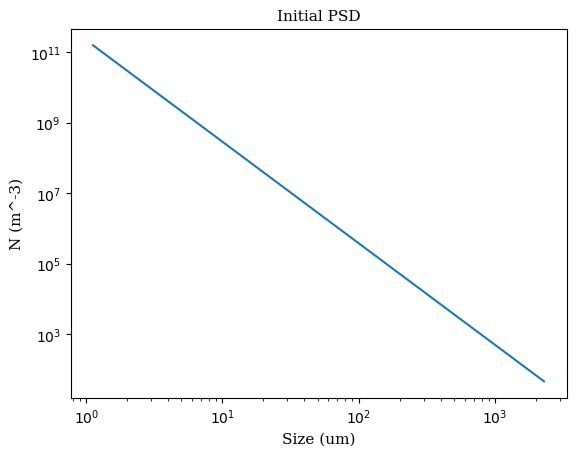

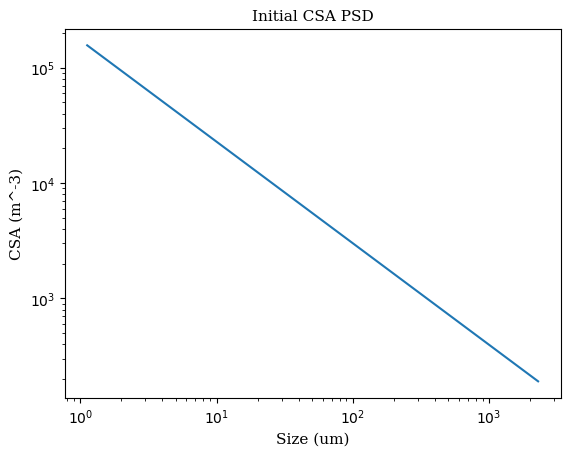

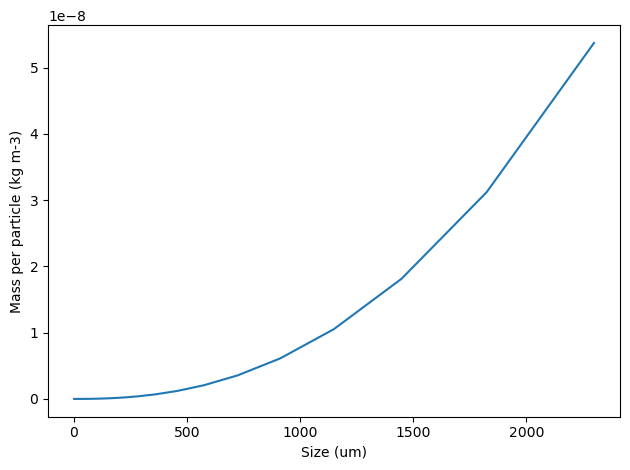

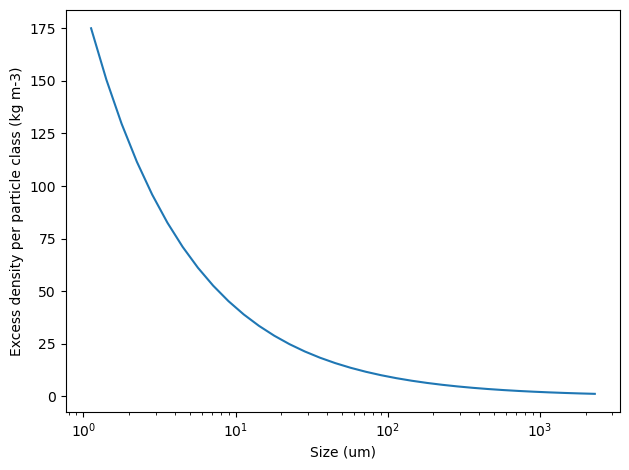

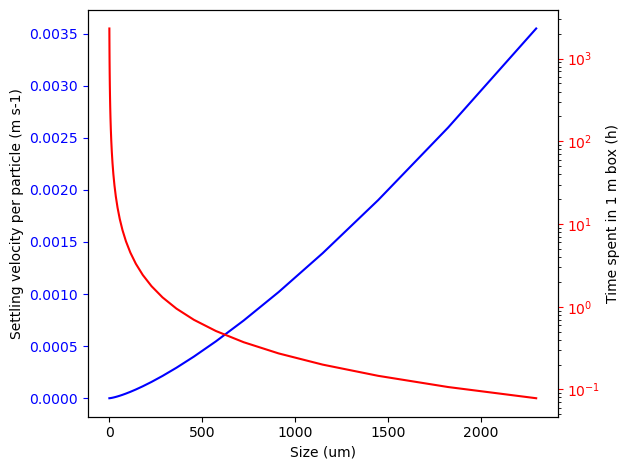

0.0011766694412905588
0.0004285073340030686


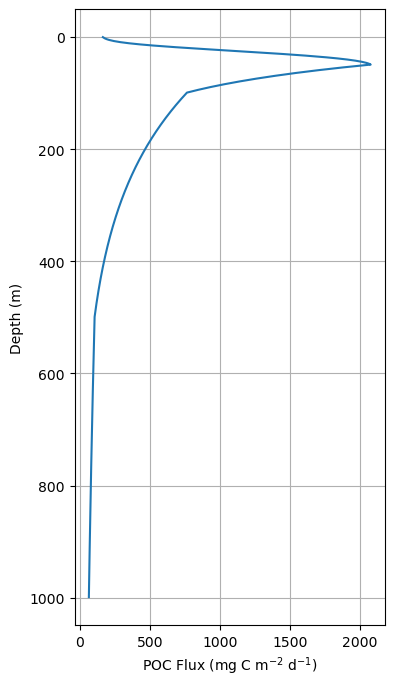

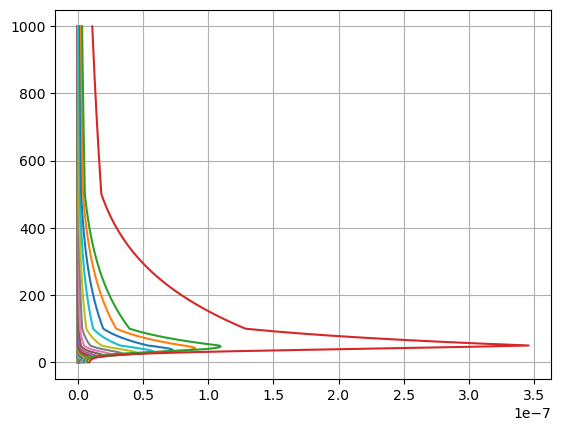

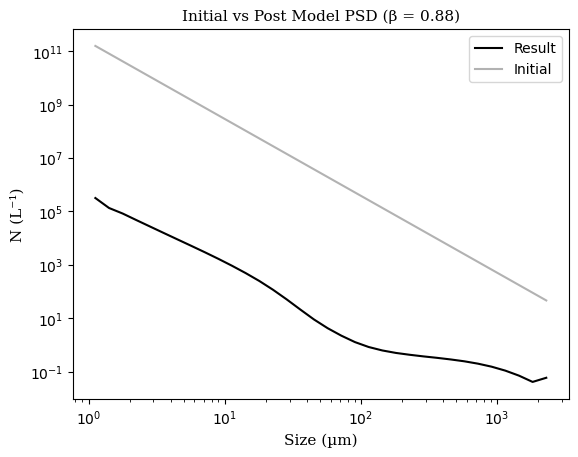

flux at 50m: 2075.0003543207977
flux at 1000m: 64.9990981836077


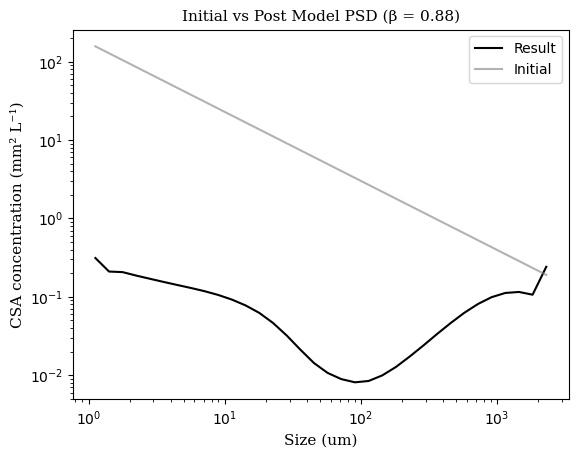

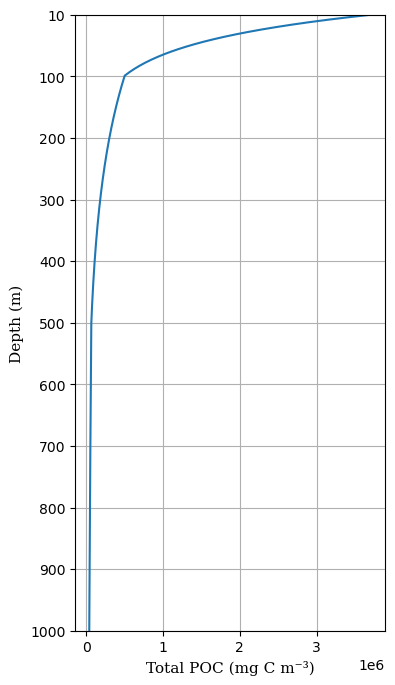

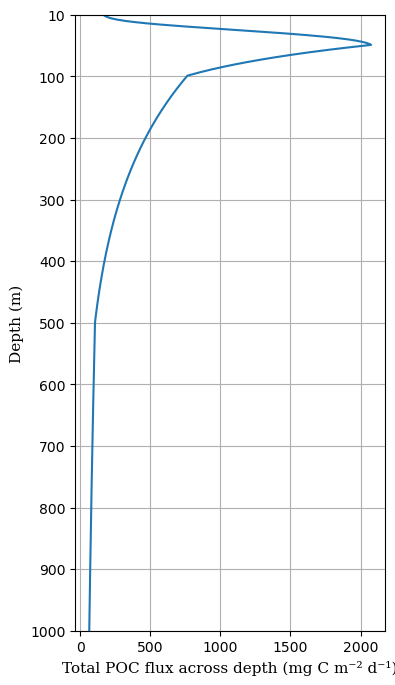

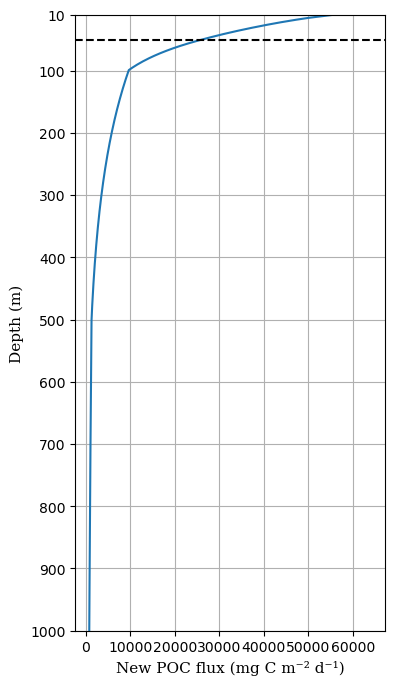

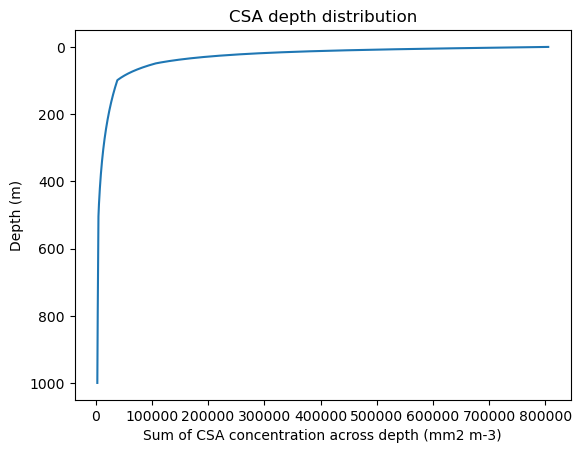

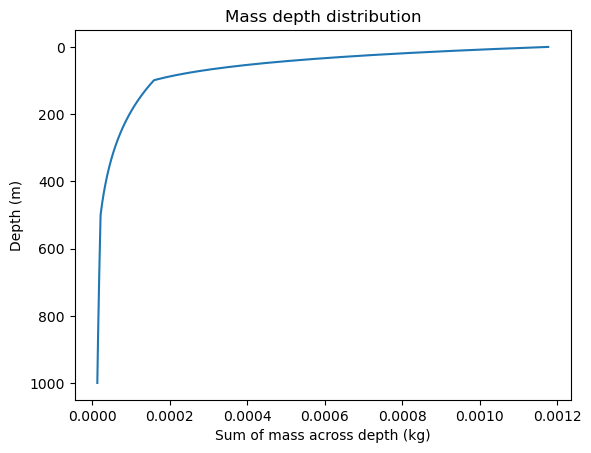

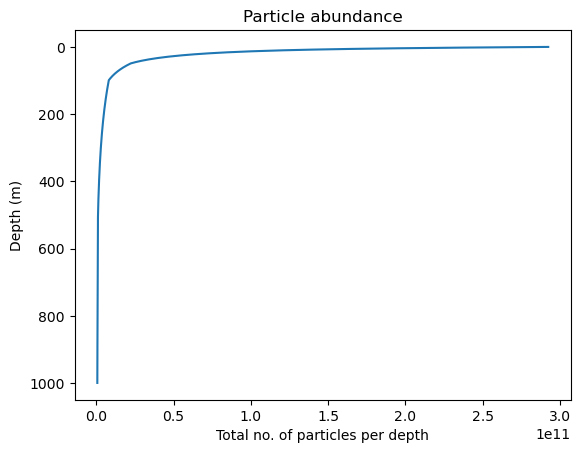

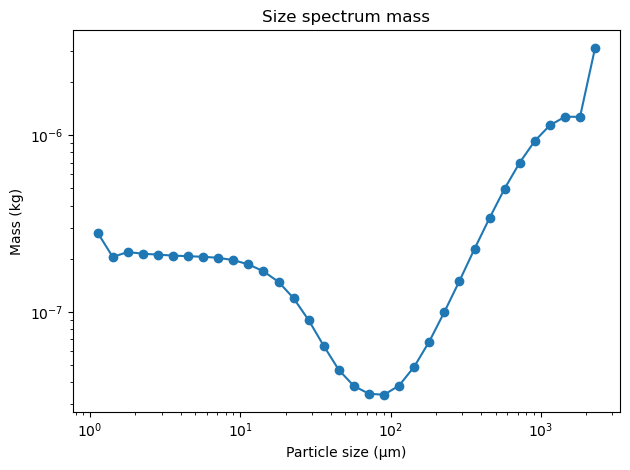

[np.float64(-2.866172482086495), np.float64(-2.8491329089344397), np.float64(-2.828882973610964), np.float64(-2.805491384558962), np.float64(-2.7791429291823833), np.float64(-2.75014293813741), np.float64(-2.7189377154108003), np.float64(-2.6860597338506182), np.float64(-2.6521623442693394), np.float64(-2.617800913196617), np.float64(-2.5835331259881773), np.float64(-2.5498142907306853), np.float64(-2.517011197377309), np.float64(-2.4853903908463253), np.float64(-2.45515581730291), np.float64(-2.4264413570338994), np.float64(-2.399337918058844), np.float64(-2.373911624993771), np.float64(-2.3502068446803364), np.float64(-2.3282269246016707), np.float64(-2.3079748054748306), np.float64(-2.2894296790094915), np.float64(-2.272554591101063), np.float64(-2.25729006010543), np.float64(-2.2435611994843794), np.float64(-2.231293770596477), np.float64(-2.2204019880659467), np.float64(-2.210796759515758), np.float64(-2.202385991255889), np.float64(-2.195077321407961), np.float64(-2.1887803185882

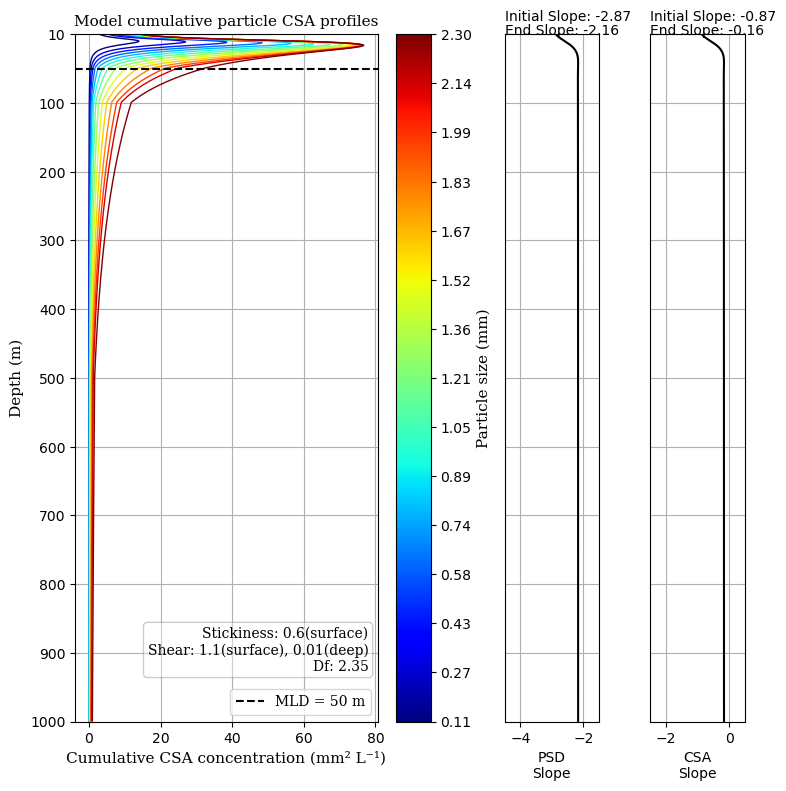

10 2298.802274937595 36.63782784143312
50 2298.802274937595 1068.27341035428
100 2298.802274937595 403.1368481837719
200 2298.802274937595 248.96095185571411


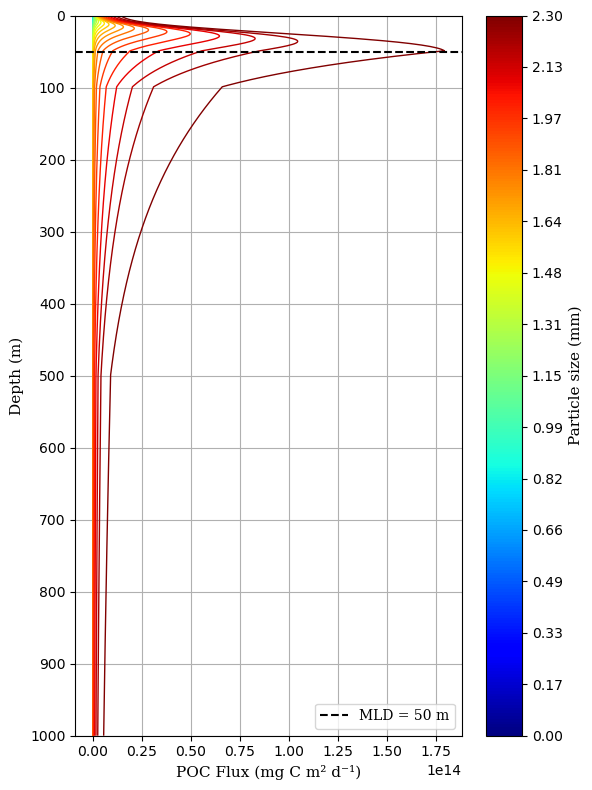

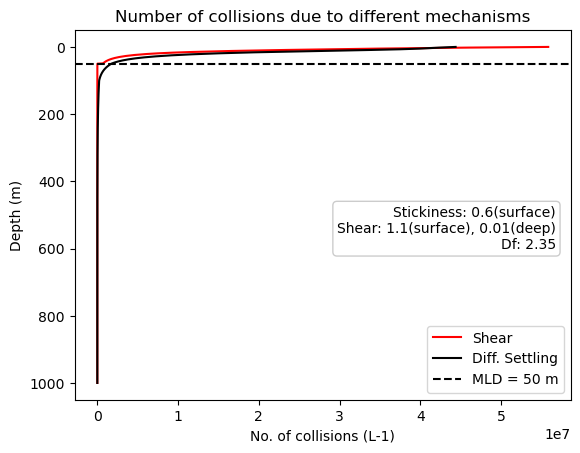

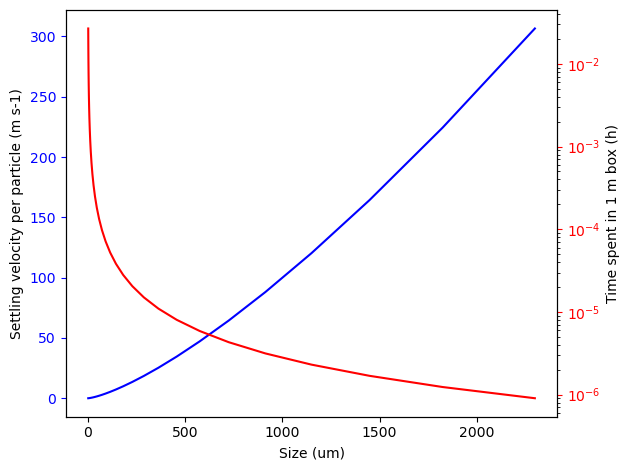

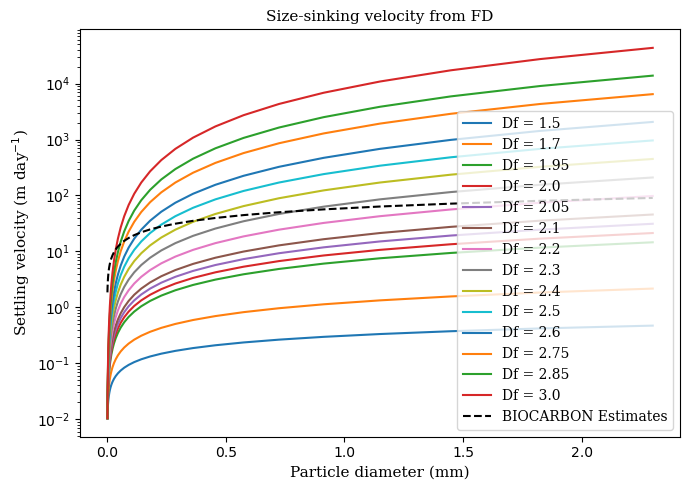

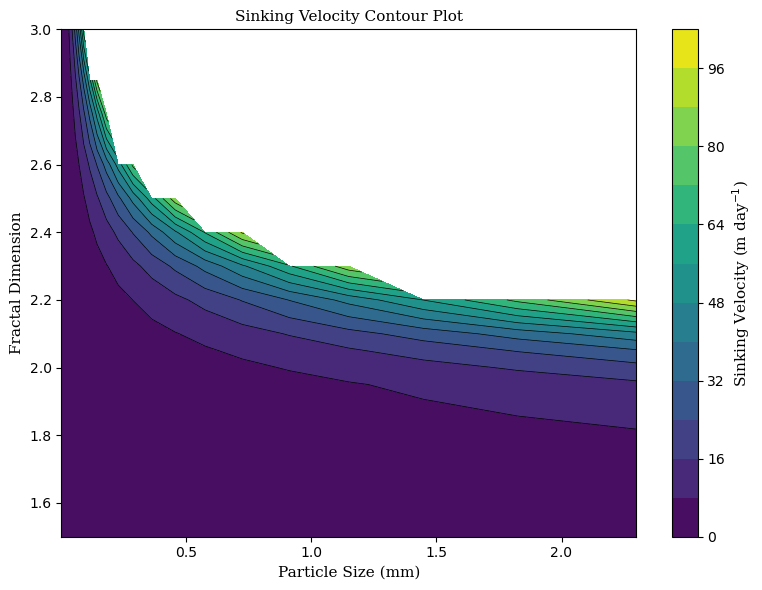

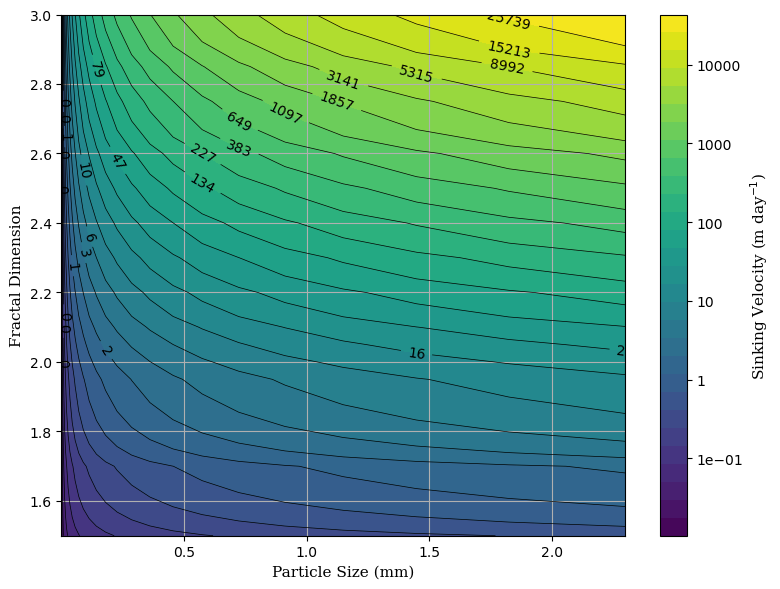

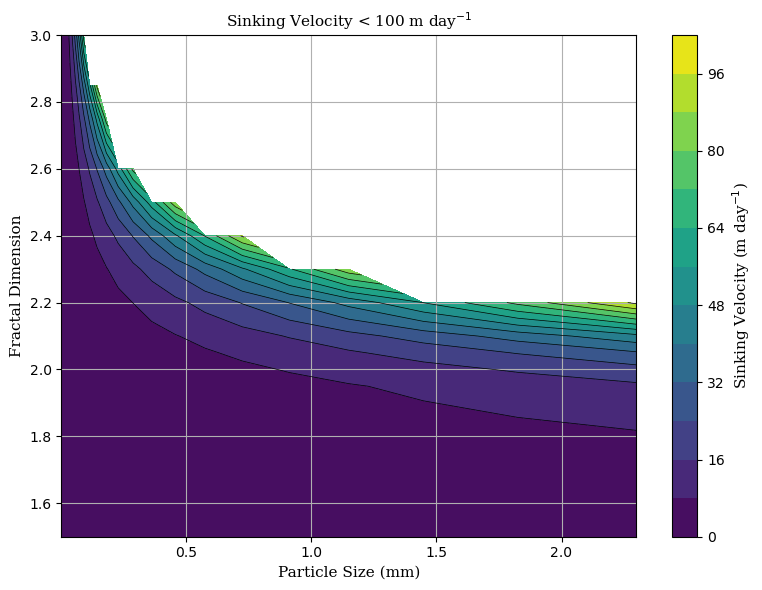

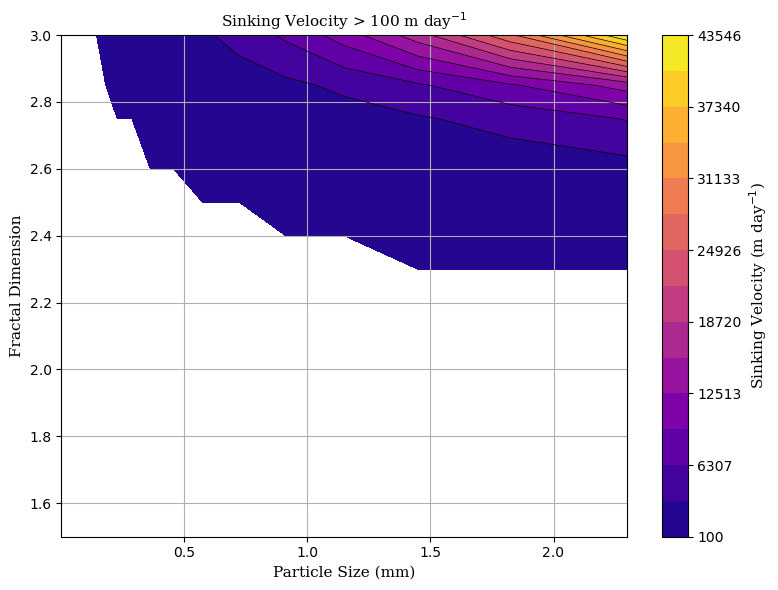

'\n# Playing around\n#one = "CSA1mil_turb1.1"\n#two = "CSA1mil_turb1.8"\n#three = "CSA1mil_turb2.5"\n#four = "CSA1mil_turb3.5"\n\n\n# Writing respective runs to files\n\nM_profile = pd.DataFrame(M_profile)\nCSA_profile = pd.DataFrame(CSA_profile)\nPSD_slope_results = pd.DataFrame(PSD_results)\nCSA_slope_results = pd.DataFrame(CSA_results)\n#mg_POC = pd.DataFrame(mg_POC)\ninitial_CSA = pd.DataFrame(initial_CSA)\nCSA = pd.DataFrame(CSA)\nturb_agg = pd.DataFrame(shear_collision_profile)\ndiff_agg = pd.DataFrame(settling_collision_profile)\nsink_velocities = pd.DataFrame(sink_velocities)\nmean_sink_velocities = pd.DataFrame(mean_sink_velocities)\n\nmean_diameter_profile = pd.DataFrame(csa_weighted_mean_profile)\n\nwith pd.ExcelWriter(f"Model_Output_{three}.xlsx") as writer:\n    M_profile.to_excel(writer, sheet_name=\'Mass\', index=False)\n    CSA_profile.to_excel(writer, sheet_name=\'CSA\', index=False)\n    PSD_slope_results.to_excel(writer, sheet_name="PSD Slope", index=False)\n    CSA_

In [ ]:
# FLUX MODEL (plz work - update, it works yay)

# ------------------------------
# SIZE BINS
# ------------------------------

size_bounds = 2 ** np.arange(0, 11 + 1/3, 1/3) #um     # OG 4       # 1 um to 33000 um (0, 15 bins) # change back to 11 + 1/3 if not working 
print(size_bounds)
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:]) # um        # calculates mid-size diameter of each bin as geometric mean (due to log spacing)
n_bins = len(size_bins)                                             # specifying the number of size bins

radius = size_bins / 2.0 #um                                       # calculates radius from diameter (um)
radius_m = radius / 1e6  #m                                        # converts radius into metres
radius_mm = radius / 1000  #mm                                     # converts radius into mm

area_per_particle = np.pi * radius_mm**2  # mm2                    # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin


# ------------------------------
# PARAMETERS
# ------------------------------
Df = 2.35                                                               # Fractal Dimension
rho_f = 1025                         # kg m-3                       # Seawater Density (kg m-3)
rho0 = 1200 # 1050                   # kg m-3  #(Li et al, 2004)    # Primary Particle Density (kg m-3)
mu = 1e-3                            # Pa s                         # Viscosity of seawater
g = 9.81                             # m s-2                        # Acceleration due to gravity
surface_a = 0.6        #0.6                                           # Stickiness (probability of successful collisions) at the surface
deep_a = 0.01                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1.1           #1.1           # 1 s-1   (Maerz et al 2020)   # Turbulent Shear at the surface
deep_G = 0.01                        # s-1   (Maerz et al 2020)     # Turbulent Shear at depth
MLD = 50                             # m                            # Mixed Layer Depth
POC_fraction = 0.25                   # can be varied, ideally 0.2 - 0.4

# ------------------------------
# INITIAL CSA DISTRIBUTION
# ------------------------------

# Use a CSA spectrum more consistent with UVP data (uses a shallower slope)

CSA0 = 850000 #(mm2 m-3) #300000   #850000                          # total surface starting particle cross-sectional area concentration

CSA_slope = 0.88 #to try initiation of smaller particles change to 0.5 if not working  # higher = steep, more small particles, lower = gentler, more large particles           # specifies how aggressively the starting distribution varies between small and large particles

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up

# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class

print(np.sum(CSA))

# Mass
r0 = radius_m[0]    #reference particle (m)
V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg
particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle (mass propor. to r^x)
M = N * particle_mass    # particles m-3 * kg = kg m-3 

# if this doesn't work, convert back to total mass




initial_N = N.copy()
fig, ax = plt.subplots()
ax.loglog(size_bins, initial_N)
ax.set_title("Initial PSD", fontdict=font)
ax.set_xlabel("Size (um)", fontdict=font)
ax.set_ylabel("N (m^-3)", fontdict=font)

initial_CSA = CSA.copy()
fig, ax = plt.subplots()
ax.loglog(size_bins, initial_CSA)
ax.set_title("Initial CSA PSD", fontdict=font)
ax.set_xlabel("Size (um)", fontdict=font)
ax.set_ylabel("CSA (m^-3)", fontdict=font)


# -------------------------------------------------------------------
# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
# -------------------------------------------------------------------

def particle_density(r):
    """
    Calculates the excess density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]  # m                                      # reference particle = radius of smallest particle in range                                                                                         
    rho = (rho0 - rho_f) * (r / r0)**(Df - 3) # kg m-3 * (m/m)^2 = kg m-3 
    return rho
    """
    if delta_rho > rho_f:
        return (delta_rho)                                         # spits out excess density of particle
    else:
        return (rho_f)                                             # spits out excess density of particle
    """                                                                                                     
                                                                                                                                 
excess_densities = []                                                      
for r in radius_m:                                                  
    density = particle_density(r)
    excess_densities.append(density)

fig, ax = plt.subplots()
ax.plot(size_bins, particle_mass)
#ax.set_xscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(size_bins, excess_densities)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout()
plt.show()

'''
new_volume = []
for r in radius_m:
    V = (4/3) * np.pi * r**3      #[] x [] x m3 = m3
    new_volume.append(V)

print(new_volume)

POC_mass = []
for d, v in zip(excess_densities, new_volume):
    excess_mass = d * v
    POC_mass.append(excess_mass * POC_fraction)
POC_mass = np.array(POC_mass)
POC_init = N * POC_mass
'''        
    

# ------------------------------
# SETTLING
# ------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """
    rho_eff = particle_density(r) # kg m-3                                   

    return (2/9) * (rho_eff) * g * r**2 / mu # kg m-3 * m s-2 * m^2 / (Pa s) = m s-1               # The Stokes formula, incorporating excess density

sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

sink_velocities = np.array(sink_velocities)
time_at_depth = 1 / sink_velocities # m / m-s = s
time_at_depth = time_at_depth / 3600

fig, ax1 = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax2 = ax1.twinx()
ax1.plot(size_bins, sink_velocities, color="blue")                                    # Currently 
ax2.plot(size_bins, time_at_depth, color="red")
ax1.set_xlabel("Size (um)")
ax1.set_ylabel("Settling velocity per particle (m s-1)")
ax2.set_ylabel("Time spent in 1 m box (h)")
ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')
ax2.set_yscale("log")
plt.tight_layout()
plt.show()


# ------------------------------
# SHEAR
# ------------------------------

def shear_rate(depth):

    if depth < MLD:                                                 # Pretty self-explanatory, MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
# ------------------------------
# COLLISION KERNELS
# ------------------------------

def shear_kernel(r1, r2, depth, use_shear=True):                                    # Need to update for it to be curvilinear rather than rectilinear, for better realism
    """
    Turbulent shear collision kernel.
    """
    if use_shear:
        G = shear_rate(depth)
        return 1.3 * G * (r1 + r2)**3  # s-1 * m^3 = m^3 s-1              
    else:
        return 0.0


def settling_kernel(r1, r2, use_settling=True):
    """
    Differential settling collision kernel.
    """
    if use_settling:
        w1 = settling_velocity(r1)
        w2 = settling_velocity(r2)
        return np.pi * (r1 + r2)**2 * abs(w1 - w2) # m^2 * m s-1 = m^3 s-1 
    else:
        return 0.0


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear == True:
        beta += shear_kernel(r1, r2, depth, use_shear=use_shear)
    if use_shear == False:
        beta += 0.0

    if use_settling == True:
        beta += settling_kernel(r1, r2, use_settling=use_settling)
    if use_settling == False:
        beta += 0.0

    return beta

# ------------------------------
# DEPTH GRID
# ------------------------------

dz = 1 # m                                                          # Depth step
z_max = 1000 # m                                                    # Max depth
nz = int(z_max / dz)

# ------------------------------
# STORAGE
# ------------------------------

N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                                  # Profile of mass, appended at each depth step
Flux_profile = np.zeros((nz, n_bins))
#POC_profile = np.zeros((nz, n_bins))
#POC_flux_profile = np.zeros((nz, n_bins))
for i in range(n_bins):

    w = settling_velocity(radius_m[i])

    Flux_profile[0, i] = M[i] * w

    # initial POC concentration
    #POC_profile[0, i] = POC_init[i]

    # initial POC flux
    #POC_flux_profile[0, i] = POC_init[i] * w

CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step

particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []
mean_sink_velocities = []

def number_concentration(M):
    N = np.zeros_like(M)                                             
                                                                    
    mask = particle_mass > 0                                        # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles
    N[mask] = M[mask] / particle_mass[mask]                         # Calculating no. of particles from mass for a bin / mass per particle
    return N

# --------------------------------------
# SENSITIVITY ANALYSIS - KERNEL SWITCHES
# --------------------------------------

shear = True                                               # Set to False or True depending on the variation
settling = True

shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)


collision_matrix = np.zeros((n_bins, n_bins))
mass_transfer_matrix = np.zeros((n_bins, n_bins))
time_matrix = np.zeros((n_bins, n_bins))



# ------------------------------
# MAIN MODEL LOOP
# ------------------------------

for z_step in range(nz):                                       # for each depth point, convert to absolute depth (and calculate aggregation rates)

    depth = z_step * dz # m                                        # Absolute depth
    F = Flux_profile[z_step, :].copy()   # kg m-2 s-1

    #POC1 = POC_profile_previous_M[z_step, :].copy()
    #POC_1 = POC_profile[z_step, :].copy()
    #POC_profile_new_M[z_step, :].copy()

    M = np.zeros_like(F)
    '''
    dt_local = 86400

    dt_sub = dt_local / n_substeps
    '''
    for i in range(n_bins):
        w = settling_velocity(radius_m[i]) # m s-1               # converts flux into mass
        M[i] = F[i] / w # kg m-2 s-1 / m s-1 = kg m-3

    M_new = np.zeros_like(M)
    #POC1 = np.zeros_like(M)
    
    N = number_concentration(M)
    '''
    for substep in range(n_substeps):

        M_new = np.zeros_like(M)                                    # records any changes to mass as a result of aggregation

        N = number_concentration(M) # particles m-3
    '''
    for i in range(n_bins):                                     # For each particle bin

        for j in range(i, n_bins):                              # For each other particle bin, and particles within their own size bins

                if N[i] <= 0 or N[j] <= 0:                          # If no particles in either bin at this depth, move on
                    continue

                r1 = radius_m[i]
                r2 = radius_m[j]

                # Running Aggregation Kernels
                beta = jackson_kernel(r1, r2, depth, use_shear=shear, use_settling=settling) # Combined kernel

                beta_shear = shear_kernel(r1, r2, depth, use_shear=shear)            # Turbulent shear aggregation
                beta_settle = settling_kernel(r1, r2, use_settling=settling)               # Differential settling aggregation

                beta = 0.0 # m-3 s-1                                        

                if shear:                                           # Flipping the switches earlier controls which processes are represented
                    beta += beta_shear

                if settling:
                    beta += beta_settle

                ##### Diagnosing: if setting the settling velocity to that of the primary particles instead of aggregate increases aggregation rates
                w_mean = (np.mean([settling_velocity(r1), settling_velocity(r2)]))  # m s-1 1 e-12
                dt_local = min((dz / w_mean), 86400)  # m / (m s-1) = s, time available for collisions at this depth step
                #dt_local = dz / w_mean 

                #dt_local = 3600
                time_matrix[i, j] += dt_local
                
                shear_contrib = beta_shear * N[i] * N[j] * dt_local
                settling_contrib = beta_settle * N[i] * N[j] * dt_local

                if i == j:
                    shear_contrib *= 0.5
                    settling_contrib *= 0.5

                #shear_contrib *= stickiness(depth)
                #settling_contrib *= stickiness(depth)

                shear_collision_profile[z_step] += shear_contrib
                settling_collision_profile[z_step] += settling_contrib

                '''
                # Tracking relative contribution of shear vs differential settling as an aggregation driver
                shear_collision_profile[z_step] += (beta_shear * N[i] * N[j] * dt_local) # m-3 s-1 * m-3 * m-3 * s = m-3
                settling_collision_profile[z_step] += (beta_settle * N[i] * N[j] * dt_local) # m-3 s-1 * m-3 * m-3 * s = m-3

                
                # Apply half counting and stickiness to shear and settling profiles
                if i == j:
                    shear_collision_profile[z_step] *= 0.5
                    settling_collision_profile[z_step] *= 0.5
                
                shear_collision_profile[z_step] *= stickiness(depth)
                settling_collision_profile[z_step] *= stickiness(depth)
                '''
                

                #if w <= 0:                                          # if the resulting aggregate would be buoyant, skip it
                    #continue

                collisions = beta * N[i] * N[j] * dt_local           # Computes no. of collisions - if beta, particle number and time at depth are larger = more collisions
                # [] * [] * s = [] = no. of collisions m-3


                if i == j:
                    collisions *= 0.5                               # Applies half-counting

                # stickiness
                agg = stickiness(depth) * collisions
                
                if i == j:                                          # don't allow more collisions than particles present
                    agg = min(agg, N[i] / 2)
                else:
                    agg = min(agg, N[i], N[j])
                

                # exact mass removed
                mass_i_deficit = agg * particle_mass[i]                     # calculate mass removed, e.g. no. of aggregations * particle mass
                mass_j_deficit = agg * particle_mass[j]                     # for the other size class in each pair

                total_mass_deficit = mass_i_deficit + mass_j_deficit        # from all the aggregations, what is the mass deficit in origin bins from particles colliding                

                # remove mass                                       # removes mass from parent bins
                M_new[i] -= mass_i_deficit
                M_new[j] -= mass_j_deficit
                

                ### What new particle will be created from the aggregation of a particle pair?

                # Resolves into length properly
                new_particle_mass = particle_mass[i] + particle_mass[j]
                # radius of new aggregate (m)
                new_radius = r0 * (new_particle_mass / m0)**(1 / Df)
                # convert to diameter in microns to match size_bins
                new_size = 2 * new_radius * 1e6

                mass_transfer_matrix[i,j] += (agg *(particle_mass[i] + particle_mass[j]))
        
                ## Where will the particle go?

                # Find surrounding bins
                k_upper = np.searchsorted(size_bins, new_size)

                # Handle edge cases
                if k_upper <= 0:
                    M_new[0] += total_mass_deficit
                    continue

                if k_upper >= n_bins:                       # if the new size is bigger than the largest bin, add it to the last bin
                    M_new[-1] += total_mass_deficit
                    continue

                k_lower = k_upper - 1                       # why is this here? because the upper bin is the first bin that is larger than the new size, so the lower bin is the one just below it

                size_lower = size_bins[k_lower]             # the lower size that is smaller than the new size
                size_upper = size_bins[k_upper]             # the upper size that is larger than the new size

                # Linear interpolation weights              # why is this here? because the new size is between two bins, so we need to distribute the mass between them based on how close it is to each bin
                w_upper = (
                    (new_size - size_lower) / (size_upper - size_lower))

                w_lower = 1.0 - w_upper

                # Distribute mass between neighbouring bins
                M_new[k_lower] += total_mass_deficit * w_lower      # assigning mass to the respective bin based on how close the new size is to each bin
                M_new[k_upper] += total_mass_deficit * w_upper
                
                collision_matrix[i,j] += collisions

                #particle_number = number_concentration(M_new)

            #fig, ax = plt.subplots()

    #N = number_concentration(M + M_new)
    #N += particle_number
    M += M_new
    #N = number_concentration(M)
    #POC = POC_fraction * M
    #N * POC_mass
    #POC1 += (M_new * POC_fraction)   # I would think you'd need to change this so it is after respiration
    #POC2 += (particle_number * POC_mass)

    
    def remin_rate(depth):    

        if depth < 100:
            return 0.02 #0.01    (1% of mass per 1m is lost)

        elif depth < 500:
            return 0.005 #0.003  (0.3% of mass per 1m is lost)

        else:
            return 0.001         #(0.1% of mass per 1m is lost)
    
    lambda_rem = remin_rate(depth) #dimensionless   # set to 0.01 for every depth
    loss = lambda_rem * M #[] * kg m-3 = kg m-3
        
    M -= loss
    

    '''
    k_rem = 1e-6   # s^-1

    loss = M[i] * k_rem * dt_local
    M[i] -= loss
    '''
    #POC = POC_fraction * M

    # Carbon remineralisation

    #POC_loss = lambda_rem * POC
    #POC -= POC_loss

    # ------------------------------
    # DIFFUSION
    # ------------------------------
    '''
    diffusion = 0.01

    M_diff = np.zeros_like(M)

    for i in range(n_bins):

        spread = diffusion * M[i]

        if i > 0:
            M_diff[i] -= spread
            M_diff[i-1] += spread

        if i < n_bins-1:
            M_diff[i] -= spread
            M_diff[i+1] += spread

    M += M_diff
    '''
    # ------------------------------
    # SINKING FLUX
    # ------------------------------
 
    F_new = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        F_new[i] = w * M[i]

    # send downward
    if z_step < nz - 1:

        Flux_profile[z_step + 1, :] += F_new

    '''
    POC_flux = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        POC_flux[i] = (POC_fraction * M[i] * w)

    if z_step < nz - 1:

        # incoming concentration for next cell

        # store POC concentration and flux at this depth

        POC_profile[z_step, :] = POC

        POC_flux_profile[z_step, :] = POC_flux

        # pass concentration to next depth cell

        if z_step < nz - 1:
            POC_profile[z_step + 1, :] += POC

    '''
    
    M_profile[z_step, :] = M

    N = number_concentration(M)
    CSA = N * area_per_particle
    CSA_profile[z_step, :] = CSA

    

    # ------------------------------
    # DERIVED TOTAL VALUES
    # ------------------------------
  
    # diagnostics
    total_number = np.sum(N) 
    total_mass = np.sum(M)
  
    particle_counts.append(total_number)
    particle_masses.append(total_mass)
    depths.append(depth)


    # Mean sinking speed
    N_per_litre = N / 1000
    mean_sink_velocity = (np.sum(N_per_litre * sink_velocities) / np.sum(N_per_litre)) * 86400
    mean_sink_velocities.append(mean_sink_velocity)

'''
# -----------------------------------------------------
# SCHEMATIC FOR ASSESSING STEADY STATE BALANCE
# -----------------------------------------------------
from matplotlib.patches import Rectangle

# =====================================================
# LOOP THROUGH ALL DEPTH BINS
# =====================================================
z_start = 0
z_end = 200
for z_check in range(z_start, z_end):

    # ---------------------------------------------
    # Depth information
    # ---------------------------------------------

    depth_top = z_check * dz
    depth_bottom = depth_top + dz
    depth_mid = depth_top + dz/2

    # ---------------------------------------------
    # Incoming state
    # ---------------------------------------------

    F_in = np.sum(Flux_profile[z_check, :])
    M_in = np.sum(M_profile[z_check, :])

    # ---------------------------------------------
    # Remineralisation
    # ---------------------------------------------

    lambda_rem = remin_rate(depth_mid)

    remin_loss = np.sum(lambda_rem * M_profile[z_check, :] * dz)
    print(remin_loss)

    # ---------------------------------------------
    # Outgoing state
    # ---------------------------------------------

    F_out = np.sum(Flux_profile[z_check + 1, :])
    M_out = np.sum(M_profile[z_check + 1, :])

    # ---------------------------------------------
    # Balance check
    # ---------------------------------------------

    residual = M_in - remin_loss - M_out

    # ---------------------------------------------
    # Plot schematic
    # ---------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 6))

    # Main box
    box = Rectangle(
        (0.30, 0.30),
        0.40,
        0.40,
        facecolor="lightblue",
        edgecolor="black",
        linewidth=2
    )

    ax.add_patch(box)

    # Incoming arrow
    ax.arrow(
        0.05, 0.50,
        0.20, 0.00,
        width=0.01,
        color="green"
    )

    # Outgoing arrow
    ax.arrow(
        0.70, 0.50,
        0.20, 0.00,
        width=0.01,
        color="blue"
    )

    # Remin arrow
    ax.arrow(
        0.50, 0.30,
        0.00, -0.20,
        width=0.01,
        color="red"
    )

    # Labels

    ax.text(
        0.5,
        0.76,
        f"{depth_top:.1f}-{depth_bottom:.1f} m",
        ha="center",
        fontsize=13,
        weight="bold"
    )

    ax.text(
        0.03,
        0.58,
        f"Incoming\n"
        f"F = {F_in:.3e}\n"
        f"M = {M_in:.3e}",
        fontsize=10
    )

    ax.text(
        0.75,
        0.58,
        f"Outgoing\n"
        f"F = {F_out:.3e}\n"
        f"M = {M_out:.3e}",
        fontsize=10
    )

    ax.text(
        0.57,
        0.12,
        f"Remin loss\n"
        f"{remin_loss:.3e}",
        ha="center",
        color="red",
        fontsize=10
    )

    ax.text(
        0.50,
        0.46,
        f"Residual\n"
        f"{residual:.3e}",
        ha="center",
        fontsize=11
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    plt.title(
        f"Mass Balance Diagnostic: z = {z_check}"
    )

    plt.tight_layout()

    plt.savefig(f"mass_balance_depth_{z_check:04d}.png", dpi=150, bbox_inches="tight")

    plt.close()



plt.imshow(np.log10(collision_matrix + 1))
plt.colorbar(label="log10(collisions m^-3)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.imshow(np.log10(mass_transfer_matrix + 1e-30))
plt.colorbar(label="log10(mass transferred)")
plt.show()

plt.imshow(np.log10(time_matrix + 1))
plt.colorbar(label="Log10 Time (s)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()
'''

# diagnostics

print(np.sum(M_profile[0,:]))
print(np.sum(M_profile[50,:]))

# ------------------------------------------------
# CONVERT TOTAL MASS -> EXCESS MASS
# ------------------------------------------------

excess_fraction = (rho0 - rho_f) / rho0

M_excess_profile = M_profile * excess_fraction

POC_profile = (POC_fraction * M_excess_profile)
POC_mg = (POC_profile * 1e6 * 86400) # kg -> mg
total_POC = np.sum(POC_mg, axis=1) # mg C m^-2 d^-1

POC_flux_profile = (POC_mg * sink_velocities)
total_POC_flux = np.sum(POC_flux_profile, axis=1)


# trying to plot
fig, ax = plt.subplots(figsize=(4,8))

ax.plot(total_POC_flux, depths)
ax.invert_yaxis()

ax.set_xlabel(
    "POC Flux (mg C m$^{-2}$ d$^{-1}$)"
)

ax.set_ylabel("Depth (m)")
ax.grid()

plt.show()



# --------------------------------
# PLOTTING OUTPUTS
# --------------------------------

parameters = f"Stickiness: {surface_a}(surface)\nShear: {surface_G}(surface), {deep_G}(deep)\nDf: {Df}"

# PARTICLE SIZE DISTRIBUTION
fig, ax = plt.subplots()
ax.loglog(size_bins, N / 1000, color="black", label="Result")
ax.loglog(size_bins, initial_N, color="grey", alpha=0.6, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (µm)", fontdict=font)
ax.set_ylabel("N (L⁻¹)", fontdict=font)
#ax.text(10e2.5, 10e3, f"β = {CSA_slope}")
ax.legend()

plt.savefig(f"PSD_before_after_slope{CSA_slope:.0e}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


# CSA PARTICLE SIZE DISTRIBUTION
fig, ax = plt.subplots()
ax.loglog(size_bins, CSA / 1000, color="black", label="Result")
ax.loglog(size_bins, initial_CSA / 1000, color="grey", alpha=0.6, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (um)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
#ax.text(10e2.5, 10e3, f"β = {CSA_slope}")
ax.legend()



# CARBON DEPTH CHECK

print("flux at 50m:", (np.max(total_POC_flux)))
print("flux at 1000m:", total_POC_flux[990])

fig, ax = plt.subplots(figsize=(4, 8))
ax.plot(total_POC, depths)
ax.set_xlabel("Total POC (mg C m⁻³)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_title("Carbon with depth", fontdict=font)
ax.set_ylim(0, 1000)
ax.set_yticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.set_yticklabels([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.invert_yaxis()
ax.grid()

plt.show()    # maybe do another plot to split POC flux into fast and slow sinking



# CARBON DEPTH CHECK

fig, ax = plt.subplots(figsize=(4, 8))
ax.plot(total_POC_flux, depths)
ax.set_xlabel("Total POC flux across depth (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_title("Carbon flux with depth", fontdict=font)
ax.set_ylim(0, 1000)
ax.set_yticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.set_yticklabels([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.invert_yaxis()
ax.grid()

plt.show()    # maybe do another plot to split POC flux into fast and slow sinking
'''




# MEAN SINKING SPEED CHECK
fig, ax = plt.subplots(figsize=(4, 8))
ax.plot(mean_sink_velocities, depths)
ax.invert_yaxis()
ax.set_xlabel("Mean sinking speed (m d⁻¹ L⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
#ax.set_title("Mean sinking speed with depth", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.invert_yaxis()
ax.grid()

plt.show()

'''
# TESTER POC FLUX CHECK

new_poc_flux = mean_sink_velocities * total_POC

fig, ax = plt.subplots(figsize=(4, 8))
ax.plot(new_poc_flux, depths)
ax.invert_yaxis()
ax.set_xlabel("New POC flux (mg C m⁻² d⁻¹)", fontdict=font)
ax.set_ylabel("Depth (m)", fontdict=font)
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
#ax.set_title("New POC flux with depth", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.invert_yaxis()
ax.grid()

plt.show()







# CROSS-SECTIONAL AREA DEPTH CHECK

total_CSA = np.sum(CSA_profile, axis=1)  


fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()


# MASS CONSERVATION CHECK

fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()


# NUMBER OF PARTICLES CHECK

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()


# SIZE BIN BEHAVIOUR CHECK

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()


CSA_results = []
for d in range(CSA_profile.shape[0]): 
    CSA_PSD = psd_slope(size_bins, CSA_profile[d, :], use_cumulative=False)
    CSA_results.append(CSA_PSD["slope"])

# if you want to calculate PSD based on numbers for every depth - code here
PSD_results = []
for z in range(CSA_profile.shape[0]):
    N_per_size = CSA_profile[z, :] / area_per_particle
    PSD = psd_slope(size_bins, N_per_size, use_cumulative=False)
    PSD_results.append(PSD["slope"])
print(PSD_results)


# CSA CUMULATIVE PLOT (ONLY OVER A CERTAIN SIZE RANGE)

CSA_profile = CSA_profile / 1000 # into mm2 l-1
cmap = plt.cm.jet

fig, (ax, ax_psd, ax_csa) = plt.subplots(1, 3, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [4, 1, 1]}) #2, 1?


# specifying filter for sizes
cutoff = 100  # anything above this size bin will be plotted
mask = size_bins > cutoff
CSA_filtered = CSA_profile[:, mask]
cumulative = np.cumsum(CSA_filtered.T, axis=0)
colors = cmap(np.linspace(0, 1, np.sum(mask)))

for i in range(np.sum(mask)):
    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=1)

# plotting MLD as line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")

# axis range treatment 
ax.set_ylim(0, 1000)
ax.set_yticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.set_yticklabels(["10", "100", "200", "300", "400", "500", "600", "700", "800", "900", "1000"])
ax.invert_yaxis()
ax.grid()
#ax.set_xlim(0, 50)

# titles and labels
ax.set_title("Model cumulative particle CSA profiles", fontdict=font)
ax.set_xlabel("Cumulative CSA concentration (mm² L⁻¹)", fontdict=font)
ax.set_ylabel("Depth (m)", fontdict=font)
ax.legend(loc="lower right", prop=legend_font)
ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontdict=legend_font,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))

### PSD (NUMBER METHOD)
ax_psd.plot(PSD_results[0:], depths[0:], color="black", linewidth=1.5)
ax_psd.set_xlim(-4.5, -1.5)
ax_psd.set_xlabel("PSD\nSlope")
ax_psd.tick_params(axis="y", left=False, labelleft=False)
ax_psd.text(-4.5, -20, f"Initial Slope: {PSD_results[0]:.2f}")
ax_psd.text(-4.5, 0, f"End Slope: {PSD_results[-1]:.2f}" )
ax_psd.grid()


### PSD (CSA METHOD)
ax_csa.plot(CSA_results[0:], depths[0:], color="black", linewidth=1.5)
ax_csa.set_xlim(-2.5, 0.5)
ax_csa.set_xlabel("CSA\nSlope")
ax_csa.tick_params(axis="y", left=False, labelleft=False)
ax_csa.text(-2.5, -20, f"Initial Slope: {CSA_results[0]:.2f}")
ax_csa.text(-2.5, 0, f"End Slope: {CSA_results[-1]:.2f}" )
ax_csa.grid()

# color bar
norm = plt.Normalize(vmin=min(size_bins[mask] / 1000), vmax=max(size_bins[mask] / 1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label="Particle size (mm)")
cbar.set_label('Particle size (mm)', fontdict=font)
ticks = np.linspace(min(size_bins[mask] / 1000), max(size_bins[mask] / 1000), 15)
cbar.ax.set_yticks(ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])



# plotting and saving
plt.tight_layout()
plt.savefig(f"CSA{CSA0:.0e}_Df{Df}_{cutoff}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()





# ------------------------------------------------
# CSA-weighted mean diameter at all depths
# ------------------------------------------------

size_bins_mm = size_bins / 1000

csa_weighted_mean_profile = []

for z in range(CSA_profile.shape[0]):

    CSA_at_depth = CSA_profile[z, :]

    # avoid division by zero
    if np.sum(CSA_at_depth) > 0:

        mean_diameter = (
            np.sum(size_bins_mm * CSA_at_depth)
            / np.sum(CSA_at_depth)
        )

    else:

        mean_diameter = np.nan

    csa_weighted_mean_profile.append(mean_diameter)

csa_weighted_mean_profile = np.array(csa_weighted_mean_profile)







'''
# CSA CUMULATIVE PLOT (ALL PARTICLES)

fig, (ax, ax_psd, ax_csa) = plt.subplots(1, 3, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [4, 1, 1]})
cumulative = np.cumsum(CSA_profile.T, axis=0)
colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):
    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=1)

# plotting MLD as line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")

# axis range treatment
ax.set_ylim(0, 1000)
ax.set_yticks(np.arange(0, 1001, 100))
ax.invert_yaxis()

# titles and labels
#ax.set_title("Model cumulative particle CSA profile", fontdict=font)
ax.set_xlabel("Cumulative CSA concentration (mm² l⁻¹)", fontdict=font)
ax.set_ylabel("Depth (m)", fontdict=font)
ax.legend(loc="lower right", prop=legend_font)
ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontdict=legend_font,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))

### PSD (NUMBER METHOD)
ax_psd.plot(PSD_results[1:], depth_obs[1:], color="black", linewidth=1.5)
ax_psd.set_xlim(-4.5, -1.5)
ax_psd.set_xlabel("PSD\nSlope")
ax_psd.tick_params(axis="y", left=False, labelleft=False)
ax_psd.grid()

### PSD (CSA METHOD)
ax_csa.plot(CSA_results[1:], depth_obs[1:], color="black", linewidth=1.5)
ax_csa.set_xlim(-2.5, 0.5)
ax_csa.set_xlabel("CSA\nSlope")
ax_csa.tick_params(axis="y", left=False, labelleft=False)
ax_csa.text(-2, 0, f"Slope {CSA_results[1]}")
ax_csa.grid()

# color bar
norm = plt.Normalize(vmin=min(size_bins/1000), vmax=max(size_bins/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label="Particle size (mm)")
cbar.set_label('Particle size (mm)', fontdict=font)
ticks = np.linspace(min(size_bins / 1000), max(size_bins / 1000), 15)
cbar.ax.set_yticks(ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])


## trying out log colour bar
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter

vmin = np.min(size_bins / 1000)
vmax = np.max(size_bins / 1000)

norm = LogNorm(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Particle size (mm)', fontdict=font)

ticks = np.logspace(np.log10(vmin), np.log10(vmax), 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.3g}" for t in ticks])




# plotting and saving
plt.tight_layout()
plt.savefig(f"CSA{CSA0:.0e}_Df{Df}_all.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()
'''
for z in [10, 50, 100, 200]:

    flux = POC_flux_profile[z,:]

    print(
        z,
        size_bins[np.argmax(flux)],
        np.max(flux)
    )


# DIFFERENT CONTRIBUTIONS OF SIZE CLASSES TO POC FLUX

fig, ax = plt.subplots(figsize=(6,8))
#mg_POC = (total_POC * 1e6) * 86400  # check this multiplication if there are issues
cumulative = np.cumsum(POC_flux_profile.T, axis=0)
cumulative = (cumulative * 1e6) * 86400

colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):
    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=1)

# plotting MLD as line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")

# axis range treatment
ax.set_ylim(0, 1000)
ax.set_yticks(np.arange(0, 1001, 100))
ax.invert_yaxis()

# titles and labels
#ax.set_title("Model cumulative particle CSA profile", fontdict=font)
ax.set_xlabel("POC Flux (mg C m² d⁻¹)", fontdict=font)
ax.set_ylabel("Depth (m)", fontdict=font)
ax.legend(loc="lower right", prop=legend_font)
#ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontdict=legend_font,
        #bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.grid()

# color bar
norm = plt.Normalize(vmin=min(size_bins/1000), vmax=max(size_bins/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label="Particle size (mm)")
cbar.set_label('Particle size (mm)', fontdict=font)
ticks = np.linspace(min(size_bins / 1000), max(size_bins / 1000), 15)
cbar.ax.set_yticks(ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.tight_layout()
plt.show()

















# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT
shear_collision_profile = shear_collision_profile / 1000
settling_collision_profile = settling_collision_profile / 1000

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of collisions due to different mechanisms")
ax.set_xlabel("No. of collisions (L-1)")
#ax.set_xscale("log")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.legend()
ax.invert_yaxis()
plt.show()


# SIZE VS SINKING SPEED PLOT
sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r) * 86400  # m day-1
    sink_velocities.append(speed)

sink_velocities = np.array(sink_velocities)
time_at_depth = 1 / sink_velocities # m / m-s = s
time_at_depth = time_at_depth / 3600

fig, ax1 = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax2 = ax1.twinx()
ax1.plot(size_bins, sink_velocities, color="blue")                                    # Currently 
ax2.plot(size_bins, time_at_depth, color="red")
ax1.set_xlabel("Size (um)")
ax1.set_ylabel("Settling velocity per particle (m s-1)")
ax2.set_ylabel("Time spent in 1 m box (h)")
ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')
ax2.set_yscale("log")
plt.tight_layout()
plt.show() 


Df_values = [1.5, 1.7, 1.95, 2.0, 2.05, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.75, 2.85, 3.0]
fig, ax = plt.subplots(figsize=(7,5))
size_bins_mm = size_bins / 1000
line_equations = []
for Df in Df_values:
    sink_velocities_later = []
    for r in radius_m:
        w = settling_velocity(r) * 86400
        sink_velocities_later.append(w)   # m day-1
    sink_velocities_later = np.array(sink_velocities_later)
    ax.plot(size_bins_mm, sink_velocities_later, label=f"Df = {Df}")
    #slope, intercept = np.polyfit(size_bins_mm, sink_velocities_later, 1)
    #line_equation = f"y = {slope:.2f}x + {intercept:.2f}"
    #line_equations.append(line_equation)

#print(line_equations)

nathan_curve = 59 * size_bins_mm**0.51
ax.plot(size_bins_mm, nathan_curve, label="BIOCARBON Estimates", color="black", linestyle="--")
#ax.set_yticks(np.arange(0, 275, 25))
#ax.set_xlim(0, 1.5)
ax.set_yscale("log")

ax.set_xlabel("Particle diameter (mm)", fontdict=font)
ax.set_ylabel("Settling velocity (m day$^{-1}$)", fontdict=font)
ax.set_title("Size-sinking velocity from FD", fontdict=font)

ax.legend(prop=legend_font)

# plotting and saving
plt.tight_layout()
plt.savefig("Size_sinkingspeed_Df_all.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()



# SIZE VS SINKING SPEED PLOT WITH EXCESS DENSITY CHANGES
# Range of fractal dimensions to investigate

# Create velocity matrix
# Rows = Df values
# Columns = size bins
WS = np.zeros((len(Df_values), len(radius_m)))

for i, Df_current in enumerate(Df_values):
    for j, r in enumerate(radius_m):
        rho_eff = (rho0 - rho_f) * (r / radius_m[0])**(Df_current - 3)
        WS[i, j] = (2/9) * rho_eff * g * r**2 / mu

WS = WS * 86400  # m d-1

# Numerical derivatives
dws_ddf, dws_dsize = np.gradient(
    WS,
    Df_values,
    size_bins
)
'''
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------------
# Sensitivity to Df
# ----------------------------------

size_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33] #[0, 2, 4, 6, 8, 10, 12, 14, 10, 15, 20, 25, 30]   # maybe change to every 2

for idx in size_indices:

    ax[0].plot(
        Df_values,
        dws_ddf[:, idx],
        label=f'{size_bins_mm[idx]:.0f} mm' )

ax[0].set_xlabel('Fractal Dimension')
ax[0].set_ylabel(r'$\partial w_s / \partial D_f$')
ax[0].set_title('Sensitivity of Settling Velocity to Fractal Dimension')
ax[0].legend(fontsize=8)

# ----------------------------------
# Sensitivity to Size # outputs need analysing
# ----------------------------------

Df_indices = [0,1,2,3,4,5,6,7,8]

for idx in Df_indices:

    ax[1].plot(
        size_bins,
        dws_dsize[idx, :],
        label=f'Df = {Df_values}'
    )

ax[1].set_xscale('log')
ax[1].set_xlabel('Particle Size (μm)')
ax[1].set_ylabel(r'$\partial w_s / \partial size$')
ax[1].set_title('Sensitivity of Settling Velocity to Particle Size')
ax[1].legend(fontsize=8)

# plotting and saving
plt.tight_layout()
plt.savefig("Size_Df_sensitivity_line.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()
'''


# Contour plot of Sinking velocity sensitivity

fig, ax = plt.subplots(figsize=(8, 6))

WS_masked = np.ma.masked_greater_equal(WS, 100)

contours = ax.contourf(
    size_bins_mm,
    Df_values,
    WS_masked, # all WS values below 100? 
    levels=15,
    cmap='viridis'
)

cbar = plt.colorbar(contours)
cbar.set_label('Sinking Velocity (m day$^{-1}$)', fontdict=font)

ax.contour(size_bins_mm, Df_values, WS_masked, levels=15, colors='k', linewidths=0.5)

ax.set_xlabel('Particle Size (mm)', fontdict=font)
ax.set_ylabel('Fractal Dimension', fontdict=font)
ax.set_title('Sinking Velocity Contour Plot', fontdict=font)

# plotting and saving
plt.tight_layout()
plt.savefig("Size_Df_sensitivity_contour.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()



'''
# Log contour plot of Sinking velocity sensitivity
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(8, 6))

#WS_masked = np.ma.masked_greater_equal(WS, 100)

contours = ax.contourf(
    size_bins_mm,
    Df_values,
    WS, # all WS values below 100? 
    levels = np.logspace(np.log10(WS.min()), np.log10(WS.max()), 20),
    cmap='viridis',
    norm=LogNorm(vmin=np.nanmin(WS), vmax=np.nanmax(WS)))

cbar = plt.colorbar(contours)
cbar.set_label('Sinking Velocity (m day$^{-1}$)', fontdict=font)

ax.contour(size_bins_mm, Df_values, WS, levels=25, colors='k', linewidths=0.5)

ax.set_xlabel('Particle Size (mm)', fontdict=font)
ax.set_ylabel('Fractal Dimension', fontdict=font)
ax.set_title('Sinking Velocity Contour Plot', fontdict=font)

# plotting and saving
plt.tight_layout()
plt.savefig("Size_Df_sensitivity_contour.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()
'''



from matplotlib.colors import LogNorm
import numpy as np

# Remove invalid values for log scaling
WS_log = np.ma.masked_less_equal(WS, 0)

vmin = WS_log.min()
vmax = WS_log.max()

levels = np.logspace(
    np.log10(vmin),
    np.log10(vmax),
    30
)

fig, ax = plt.subplots(figsize=(8, 6))

contours = ax.contourf(
    size_bins_mm,
    Df_values,
    WS_log,
    levels=levels,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap='viridis'
)

from matplotlib.ticker import LogLocator, LogFormatter

cbar = plt.colorbar(contours)
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.update_ticks()
cbar.set_label('Sinking Velocity (m day$^{-1}$)', fontdict=font)

labels = ax.contour(
    size_bins_mm,
    Df_values,
    WS_log,
    levels=levels,
    colors='k',
    linewidths=0.5
)

ax.clabel(labels)

ax.set_xlabel('Particle Size (mm)', fontdict=font)
ax.set_ylabel('Fractal Dimension', fontdict=font)
ax.grid()

plt.tight_layout()
plt.show()








# ----------------------------------
# Sinking velocities below 100 m d-1
# ----------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

WS_low = np.ma.masked_greater_equal(WS, 100)

contours = ax.contourf(
    size_bins_mm,
    Df_values,
    WS_low,
    levels=15,
    cmap='viridis'
)

cbar = plt.colorbar(contours)
cbar.set_label('Sinking Velocity (m day$^{-1}$)', fontdict=font)

ax.contour(
    size_bins_mm,
    Df_values,
    WS_low,
    levels=15,
    colors='k',
    linewidths=0.5
)

ax.set_xlabel('Particle Size (mm)', fontdict=font)
ax.set_ylabel('Fractal Dimension', fontdict=font)
ax.set_title('Sinking Velocity < 100 m day$^{-1}$', fontdict=font)
ax.grid()

plt.tight_layout()
plt.savefig(
    "Size_Df_sensitivity_contour_under100.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ----------------------------------
# Sinking velocities above 100 m d-1
# ----------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

WS_high = np.ma.masked_less_equal(WS, 100)

levels_high = np.linspace(
    100,
    np.nanmax(WS),
    15
)

contours = ax.contourf(
    size_bins_mm,
    Df_values,
    WS_high,
    levels=levels_high,
    cmap='plasma'
)

cbar = plt.colorbar(contours)
cbar.set_label('Sinking Velocity (m day$^{-1}$)', fontdict=font)

ax.contour(
    size_bins_mm,
    Df_values,
    WS_high,
    levels=levels_high,
    colors='k',
    linewidths=0.5
)

ax.set_xlabel('Particle Size (mm)', fontdict=font)
ax.set_ylabel('Fractal Dimension', fontdict=font)
ax.set_title('Sinking Velocity > 100 m day$^{-1}$', fontdict=font)
ax.grid()

plt.tight_layout()
plt.savefig(
    "Size_Df_sensitivity_contour_over100.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

#-------------------------------
# SENSITIVITY ANALYSES
#-------------------------------

# ------------------------------------------
# F490 P3
# ------------------------------------------


# # STICKINESS RUNS
#zero = "F490_P3_a_0"
#no_agg = "F490_P3_no_agg"
#lower = "F490_P3_a_0.05"
#low = "F490_P3_a_0.15"
#base_unit = "F490_P3_a_0.25"   # could add a B in front of the parameter to indicate base
#mid = "F490_P3_a_0.35"
#high = "F490_P3_a_0.5"        # and just comment back in which run you're doing and it will save it
#mid_high = "F490_P3_a_0.6"
#higher = "F490_P3_a_0.75"
#high3 = "F490_P3_a_0.9"
#one = "F490_P3_a_1.0"


# Fractal Dimension Runs
#no_agg = "F490_P3_no_agg"
#low = "F490_P3_df_1.35"
#low1 = "F490_P3_df_1.5"
#low2 = "F490_P3_df_1.7"
#low3 = "F490_P3_df_1.95"     
#base_unit = "F490_P3_df_2.1"
#high = "F490_P3_df_2.25"
#high1 = "F490_P3_df_2.35"
#high2 = "F490_P3_df_2.5"
#high3 = "F490_P3_df_2.75"
#high4 = "F490_P3_df_3.00"


# Turbulence Runs
#no_agg = "F490_P3_no_agg"
#low = "F490_P3_G_0"
#low1 = "F490_P3_G_0.2"
#low2 = "F490_P3_G_0.4"
#base_unit = "F490_P3_G_0.65"     
#high0 = "F490_P3_G_0.8"
#high = "F490_P3_G_1.1"
#high2 = "F490_P3_G_1.4"
#high3 = "F490_P3_G_1.7"
#high4 = "F490_P3_G_2.0"
#high5 = "F490_P3_G_2.5"
#high6 = "F490_P3_G_3.0"


# Conc Runs
#x075 = "F490_P3_C_075" #225,000
#x05 = "F490_P3_C_05" #150,000
#x025 = "F490_P3_C_025" #75,000
#base_unit = "F490_P3_C_1" #300,000    # base_unit
#x125 = "F490_P3_C_125" #375,000
#x15 = "F490_P3_C_15" #450,000
#x2 = "F490_P3_C_2" #600,000


# Primary Particle Density
#organic = "F490_P3_PP_1050"
#base_unit = "F490_P3_PP_1200"  # baseline
#high = "F490_P3_PP_1600"
#mineral = "F490_P3_PP_2700"




# ------------------------------------------
# F490 P16
# ------------------------------------------

# # STICKINESS RUNS
#zero = "F490_P16_a_0"
#no_agg = "F490_P16_no_agg"
#lower = "F490_P16_a_0.05"
#low = "F490_P16_a_0.15"
#mid0 = "F490_P16_a_0.25"
#mid = "F490_P16_a_0.35"
#high = "F490_P16_a_0.5"        # and just comment back in which run you're doing and it will save it
#base_unit = "F490_P16_a_0.6"    
#higher = "F490_P16_a_0.75"
#high1 = "F490_P16_a_0.9"
#one = "F490_P16_a_1.0"


# Fractal Dimension Runs

#low2 = "F490_P16_df_1.7"
#low3 = "F490_P16_df_1.95"     
#mid = "F490_P16_df_2.1"
#high = "F490_P16_df_2.25"
#base_unit = "F490_P16_df_2.35"    # base unit
#high2 = "F490_P16_df_2.5"
#high3 = "F490_P16_df_2.75"
#high4 = "F490_P16_df_3.00"


# Turbulence Runs
#no_agg = "F490_P16_no_agg"
#low = "F490_P16_G_0"
#low1 = "F490_P16_G_0.2"
#low2 = "F490_P16_G_0.4"
#low3 = "F490_P16_G_0.65"     
#low4 = "F490_P16_G_0.8"
#base_unit = "F490_P16_G_1.1" 
#high2 = "F490_P16_G_1.4"
#high3 = "F490_P16_G_1.7"
#high4 = "F490_P16_G_2.0"
#high5 = "F490_P16_G_2.5"
#high6 = "F490_P16_G_3.0"


# Conc Runs
#x075 = "F490_P16_C_075" #637500
#x05 = "F490_P16_C_05" #425,000
#x025 = "F490_P16_C_025" #212500
#x1 = "F490_P16_C_1"     # base_unit #850000
#x125 = "F490_P16_C_125" #1,062,500
#x15 = "F490_P16_C_15" #1,275,000
#x2 = "F490_P16_C_2" #1,700,000


# Primary Particle Density
#organic = "F490_P16_PP_1050"
#base_unit = "F490_P16_PP_1200"  # baseline
#high = "F490_P16_PP_1600"
#mineral = "F490_P16_PP_2700"

'''
# Playing around
#one = "CSA1mil_turb1.1"
#two = "CSA1mil_turb1.8"
#three = "CSA1mil_turb2.5"
#four = "CSA1mil_turb3.5"


# Writing respective runs to files

M_profile = pd.DataFrame(M_profile)
CSA_profile = pd.DataFrame(CSA_profile)
PSD_slope_results = pd.DataFrame(PSD_results)
CSA_slope_results = pd.DataFrame(CSA_results)
#mg_POC = pd.DataFrame(mg_POC)
initial_CSA = pd.DataFrame(initial_CSA)
CSA = pd.DataFrame(CSA)
turb_agg = pd.DataFrame(shear_collision_profile)
diff_agg = pd.DataFrame(settling_collision_profile)
sink_velocities = pd.DataFrame(sink_velocities)
mean_sink_velocities = pd.DataFrame(mean_sink_velocities)

mean_diameter_profile = pd.DataFrame(csa_weighted_mean_profile)

with pd.ExcelWriter(f"Model_Output_{three}.xlsx") as writer:
    M_profile.to_excel(writer, sheet_name='Mass', index=False)
    CSA_profile.to_excel(writer, sheet_name='CSA', index=False)
    PSD_slope_results.to_excel(writer, sheet_name="PSD Slope", index=False)
    CSA_slope_results.to_excel(writer, sheet_name='CSA PSD Slope', index=False)
    #mg_POC.to_excel(writer, sheet_name='POC Flux', index=False)
    initial_CSA.to_excel(writer, sheet_name="Initial CSA", index=False)
    CSA.to_excel(writer, sheet_name="Start and End CSA", index=False)
    turb_agg.to_excel(writer, sheet_name="Turb Aggs Profile", index=False)
    diff_agg.to_excel(writer, sheet_name="Diff Aggs Profile", index=False)
    sink_velocities.to_excel(writer, sheet_name="Sink Velocities", index=False)
    mean_sink_velocities.to_excel(writer, sheet_name="Mean Sink Velocities", index=False)
    mean_diameter_profile.to_excel(writer, sheet_name="Mean Diameter", index=False)
'''


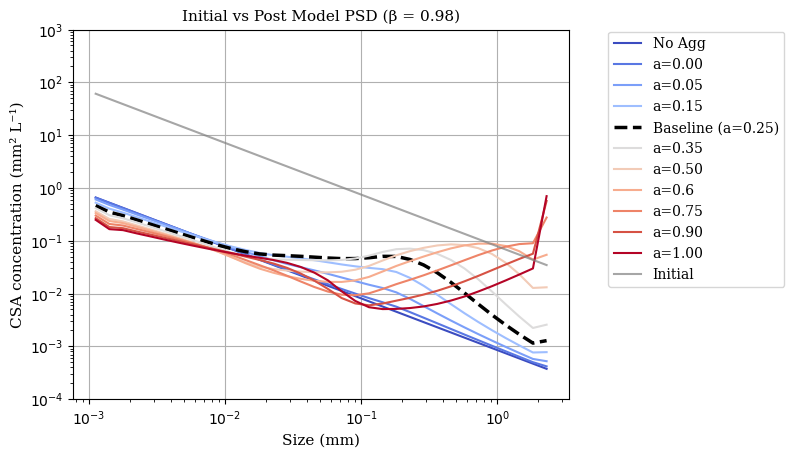

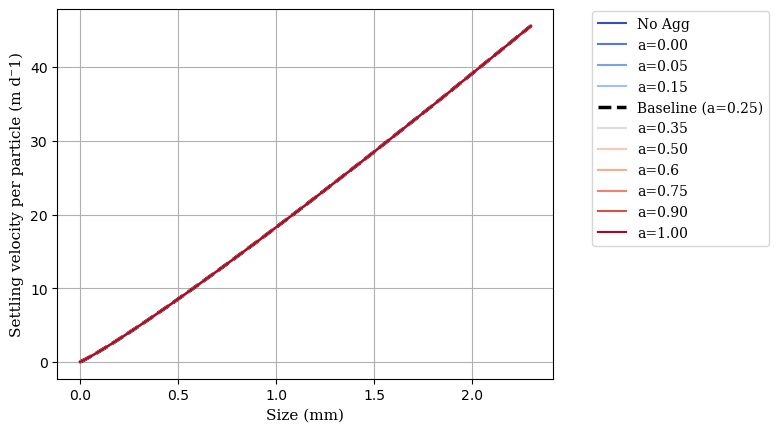

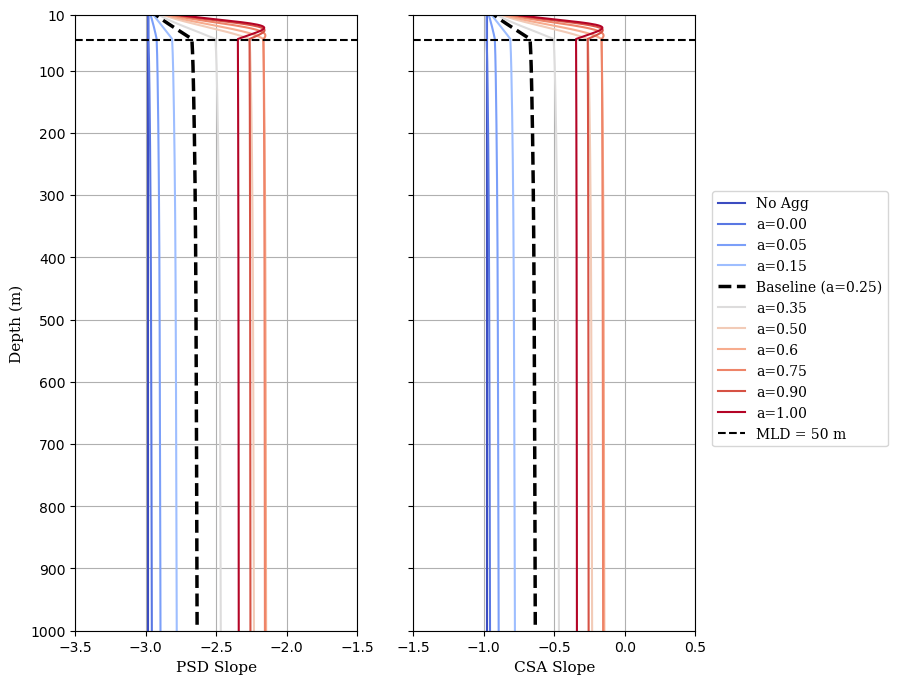

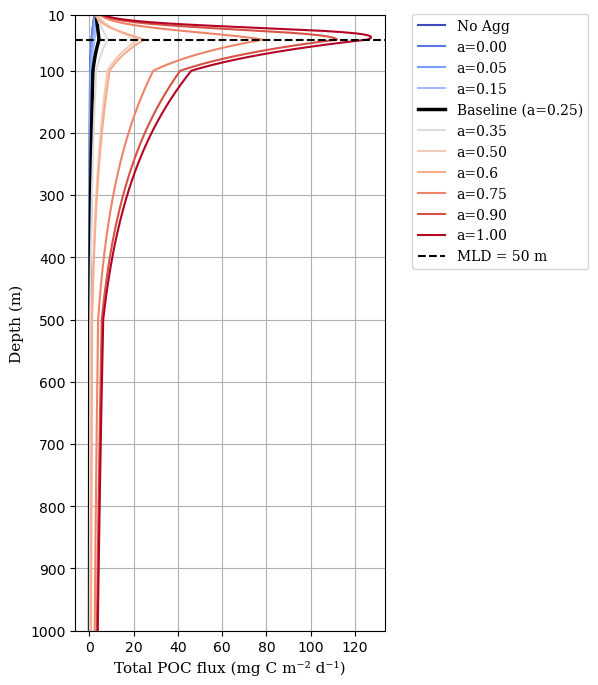

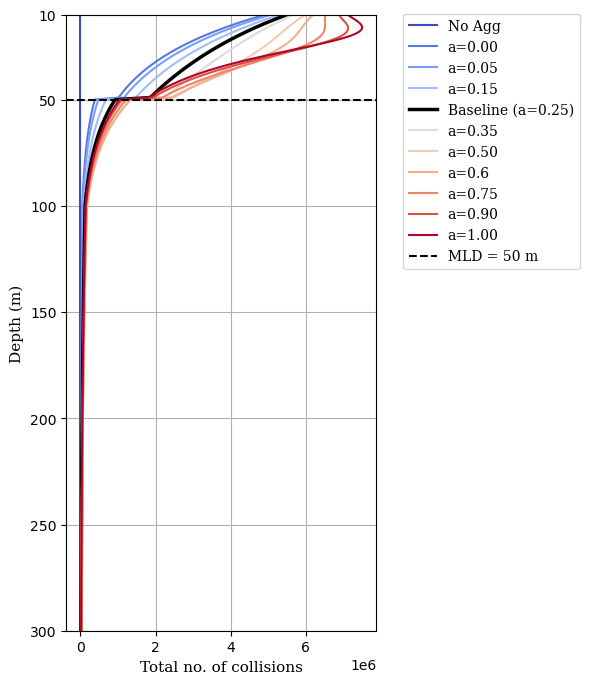

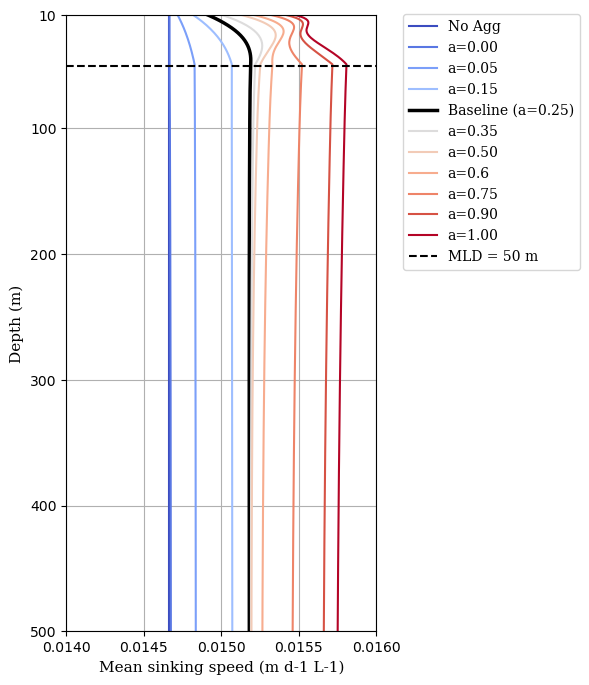

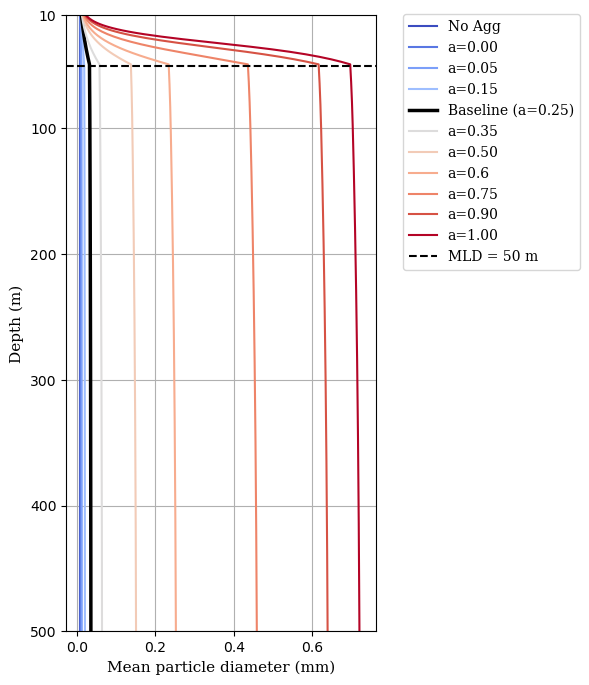

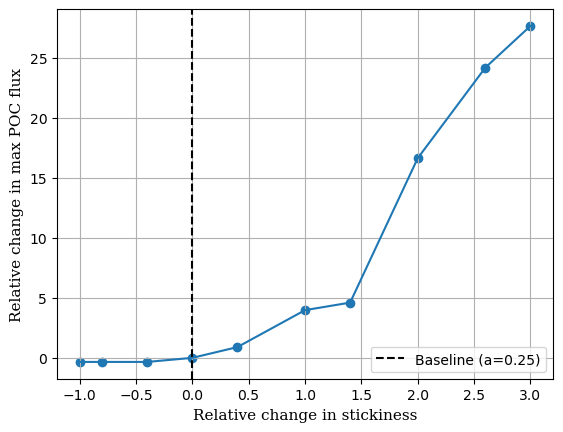

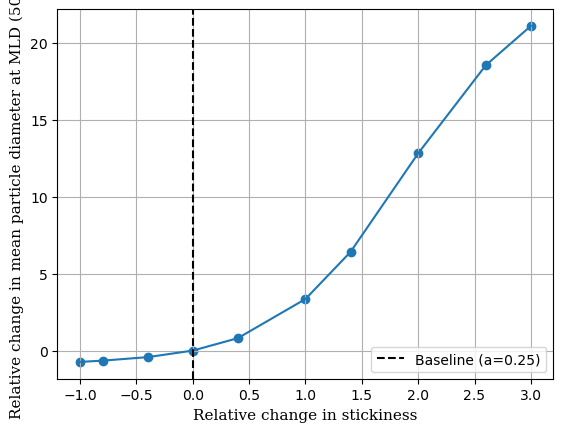

<class 'pandas.core.frame.DataFrame'>
(1000, 1)
(10,) (10,)


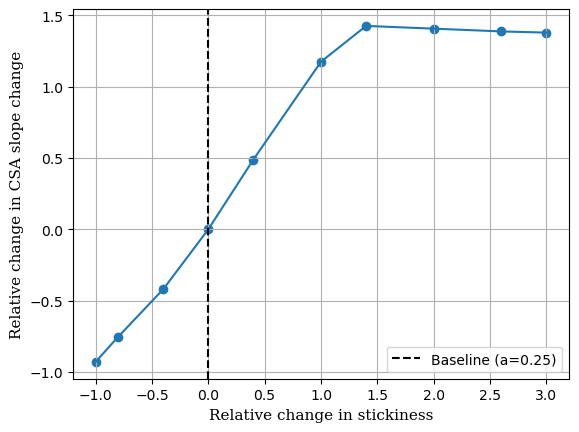

In [79]:
# SENSITIVITY ANALYSIS FOR PRE-BLOOM STICKINESS

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# STICKINESS # change this for each parameter

pre_bloom_stickiness_runs = {
    "No Agg": "F490_P3_no_agg",
    "a=0.00": "F490_P3_a_0",
    "a=0.05": "F490_P3_a_0.05",
    "a=0.15": "F490_P3_a_0.15",
    "a=0.25": "F490_P3_a_0.25",     # baseline
    "a=0.35": "F490_P3_a_0.35",
    "a=0.50": "F490_P3_a_0.5",
    "a=0.6": "F490_P3_a_0.6",
    "a=0.75": "F490_P3_a_0.75",
    "a=0.90": "F490_P3_a_0.9",
    "a=1.00": "F490_P3_a_1.0",
}

pre_bloom_agg_results = {label: load_run(filename)
                         for label, filename in pre_bloom_stickiness_runs.items()}

#print(pre_bloom_agg_results["a=0.25"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_agg_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.25)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = 0.98)", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.set_ylim(10**-4, 10**3)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.25)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d⁻1)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.25)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.25)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.25)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.25)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xlim(0.014, 0.016)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_agg_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.25":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.25)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xlim(0.014, 0.015)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_stickiness = 0.25 
baseline_poc = np.max(pre_bloom_agg_results["a=0.25"]["poc_flux"]) 

delta_pre_bloom_stickiness = []
delta_poc_stick = []

for label, run in pre_bloom_agg_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_stickiness.append((parameter - baseline_stickiness) / baseline_stickiness)

    delta_poc_stick.append((max_poc - baseline_poc) / baseline_poc)

# Sort by stickiness value for plotting
order = np.argsort(delta_pre_bloom_stickiness)

delta_parameter = np.array(delta_pre_bloom_stickiness)[order]
delta_poc_stick = np.array(delta_poc_stick)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_stickiness, delta_poc_stick)
ax.plot(delta_pre_bloom_stickiness, delta_poc_stick)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.25)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_stickiness = 0.25
baseline_diameter = (pre_bloom_agg_results["a=0.25"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_stickiness = []
delta_diameter_stick = []

for label, run in pre_bloom_agg_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    stickiness = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)
    delta_diameter_stick.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_stickiness)

delta_pre_bloom_stickiness = np.array(delta_pre_bloom_stickiness)[order]
delta_diameter_stick = np.array(delta_diameter_stick)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_stickiness, delta_diameter_stick)
ax.plot(delta_pre_bloom_stickiness, delta_diameter_stick)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.25)")

ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD ({MLD:.0f} m)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
baseline_stickiness = 0.25 # change this when needed


print(type(pre_bloom_agg_results["a=0.25"]["csa_slope"]))
print(np.asarray(pre_bloom_agg_results["a=0.25"]["csa_slope"]).shape)



baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_agg_results["a=0.25"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_stickiness = []
delta_csa_change_stick = []

for label, run in pre_bloom_agg_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    stickiness = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)

    delta_csa_change_stick.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by stickiness value for plotting 
order = np.argsort(delta_pre_bloom_stickiness)

delta_pre_bloom_stickiness = np.array(delta_pre_bloom_stickiness)[order]
delta_csa_change_stick = np.array(delta_csa_change_stick)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_stickiness), np.shape(delta_csa_change_stick))

ax.scatter(delta_pre_bloom_stickiness, delta_csa_change_stick)
ax.plot(delta_pre_bloom_stickiness, delta_csa_change_stick)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.25)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


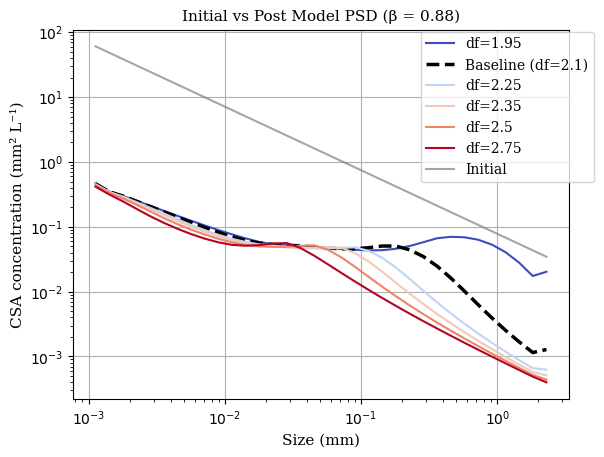

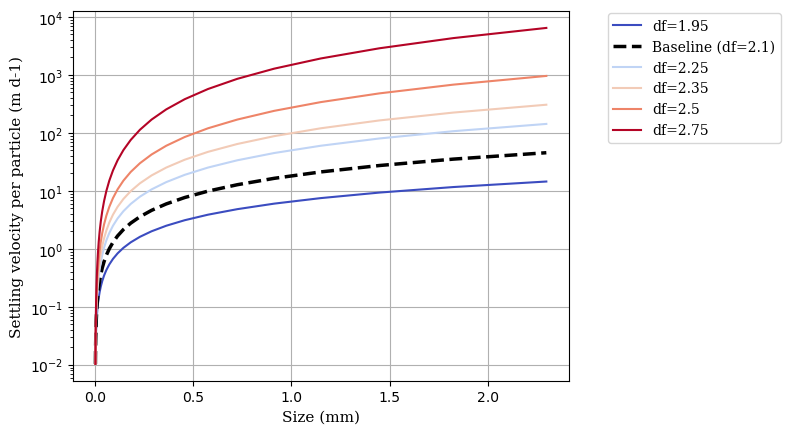

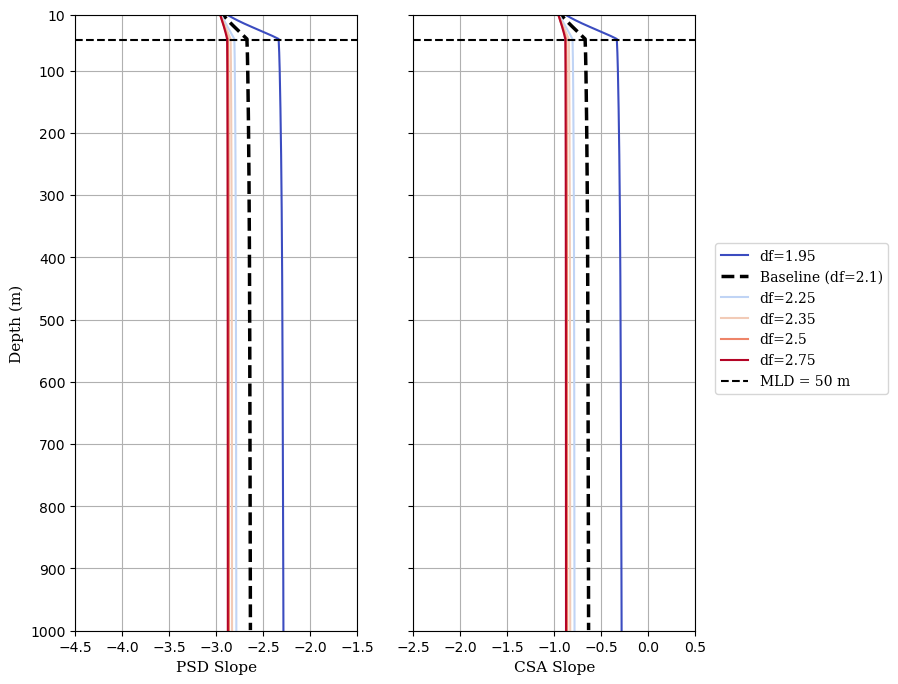

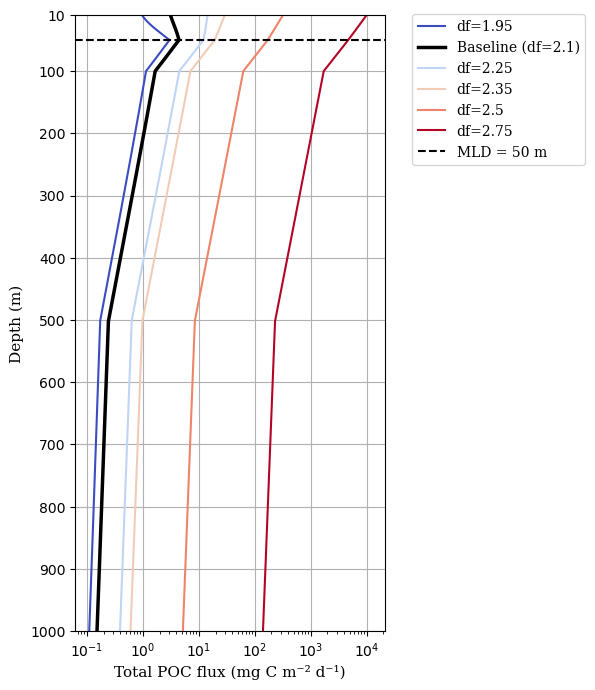

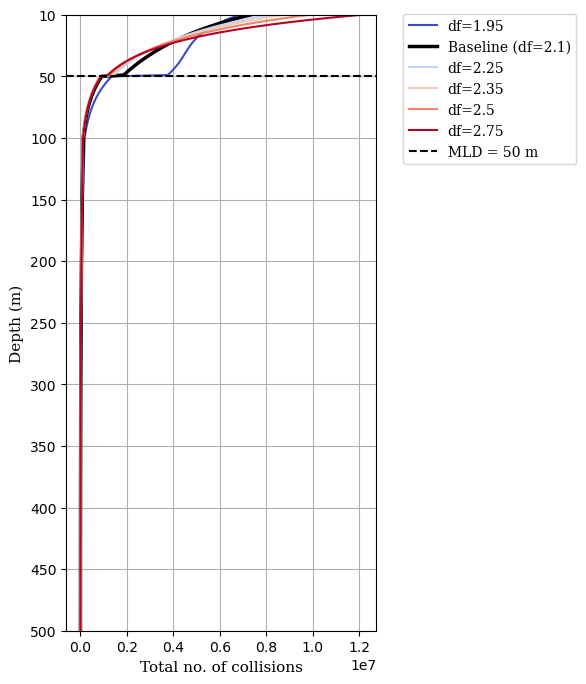

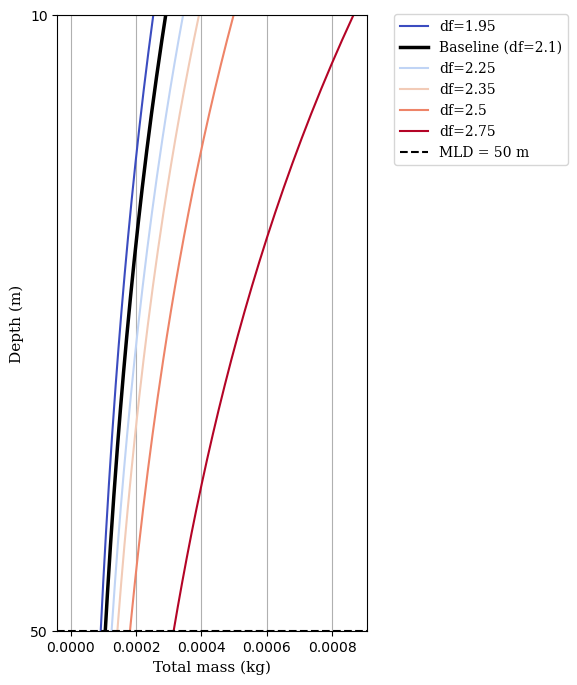

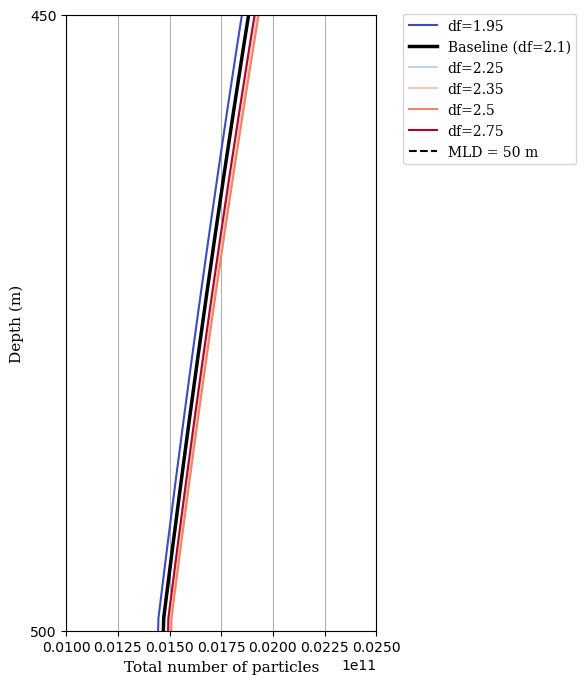

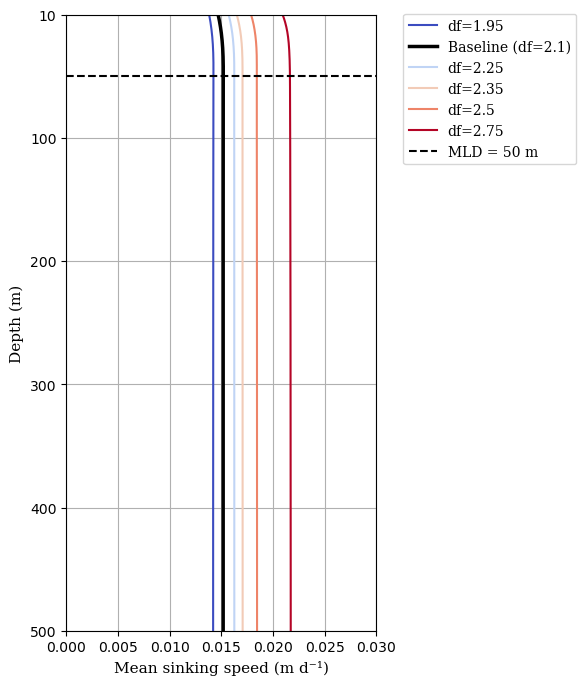

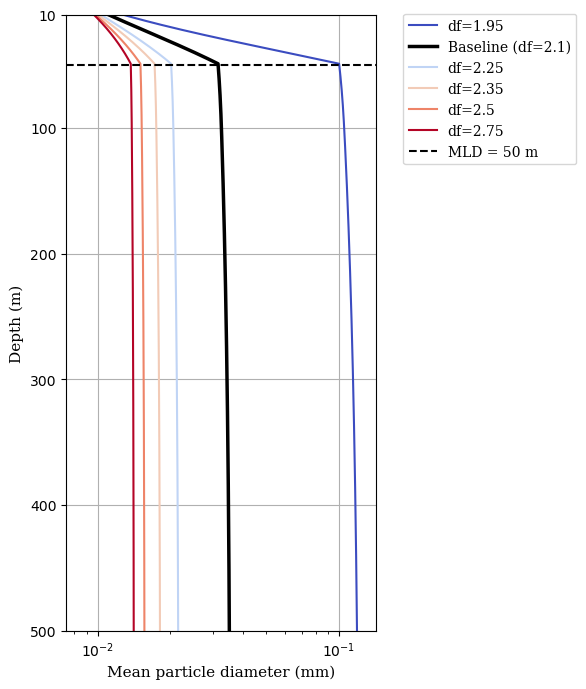

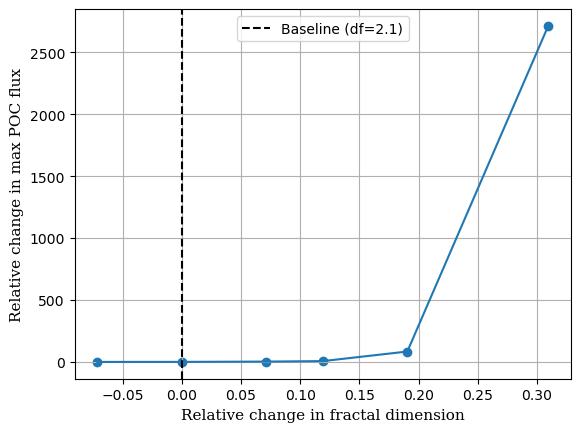

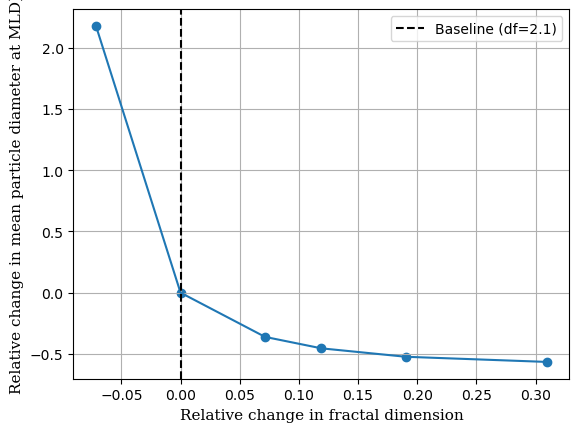

(6,) (6,)


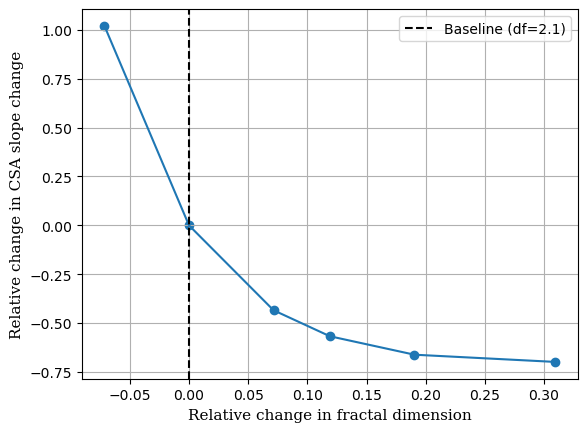

In [80]:
# SENSITIVITY ANALYSIS FOR PRE-BLOOM FRACTAL DIMENSION 

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# DF RUNS # change this for each parameter

pre_bloom_df_runs = {
    #"No Agg": "F490_P3_no_agg",
    #"df=1.35": "F490_P3_df_1.35",
    #"df=1.5": "F490_P3_df_1.5",
    #"df=1.7": "F490_P3_df_1.7",
    "df=1.95": "F490_P3_df_1.95",     # baseline
    "df=2.1": "F490_P3_df_2.1",
    "df=2.25": "F490_P3_df_2.25",
    "df=2.35": "F490_P3_df_2.35",
    "df=2.5": "F490_P3_df_2.5",
    "df=2.75": "F490_P3_df_2.75",
    #"df=3.00": "F490_P3_df_3.00",
}

pre_bloom_df_results = {label: load_run(filename)
                         for label, filename in pre_bloom_df_runs.items()}

#print(pre_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_df_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (df=2.1)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_df_results["df=1.95"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()




### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
            color = "black"
            lw = 2.5
            ls = "--"
            label = "Baseline (df=2.1)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
            color = "black"
            lw = 2.5
            ls = "--"
            label = "Baseline (df=2.1)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-4.5, -1.5)
ax[1].set_xlim(-2.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_xscale("log")
#ax.set_xlim(10**-1, 10**7)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()







### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 500)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### SUM OF MASS DEPTH PLOT 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(np.sum(run["mass"], axis=1), depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total mass (kg)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 50)
ax.set_yticks([0, 50]) #, 100, 150, 200, 250, 300, 350, 400, 450, 500])
ax.set_yticklabels(["10", "50"]) #, "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





# Number of particles at depth

N_dictionary = {}

for label, run in pre_bloom_df_results.items():

    M_profile = run["mass"]

    # Shape: (34, n_depths)
    N_profile = M_profile.div(particle_mass, axis=1) 

    # Shape: (n_depths,)
    N_total_profile = N_profile.sum(axis=1)

    N_dictionary[label] = N_total_profile


fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, N_total_profile) in zip(colors, N_dictionary.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(N_total_profile, depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total number of particles", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(450, 500)
ax.set_yticks([450, 500])
ax.set_yticklabels(["450", "500"])
#ax.set_ylim(0, 500)
#ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
#ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.ticklabel_format(style="sci", axis="x", scilimits=(11, 11))
#ax.set_xscale("log")
ax.set_xlim(1000000000, 2500000000)      #135000000000
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()






### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 500)
#ax.set_xscale("log")
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_yticklabels([10, 100, 200, 300, 400, 500])
ax.set_xlim(0, 0.03)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.1":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.1)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_df = 2.1 
baseline_poc = np.max(pre_bloom_df_results["df=2.1"]["poc_flux"]) 

delta_pre_bloom_df = []
delta_poc_df = []

for label, run in pre_bloom_df_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_df.append((parameter - baseline_df) / baseline_df)

    delta_poc_df.append((max_poc - baseline_poc) / baseline_poc)

# Sort by df value for plotting
order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_df = np.array(delta_pre_bloom_df)[order]
delta_poc_df = np.array(delta_poc_df)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_df, delta_poc_df)
ax.plot(delta_pre_bloom_df, delta_poc_df)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.1)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_df = 2.1
baseline_diameter = (pre_bloom_df_results["df=2.1"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_df = []
delta_diameter_df = []

for label, run in pre_bloom_df_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_df.append((df - baseline_df) / baseline_df)
    delta_diameter_df.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_df = np.array(delta_pre_bloom_df)[order]
delta_diameter_df = np.array(delta_diameter_df)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_df, delta_diameter_df)
ax.plot(delta_pre_bloom_df, delta_diameter_df)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.1)")

ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
baseline_df = 2.1 # change this when needed


baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_df_results["df=2.1"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_df = []
delta_csa_change_df = []

for label, run in pre_bloom_df_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_df.append((df - baseline_df) / baseline_df)

    delta_csa_change_df.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_df = np.array(delta_pre_bloom_df)[order]
delta_csa_change_df = np.array(delta_csa_change_df)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_df), np.shape(delta_csa_change_df))

ax.scatter(delta_pre_bloom_df, delta_csa_change_df)
ax.plot(delta_pre_bloom_df, delta_csa_change_df)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.1)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


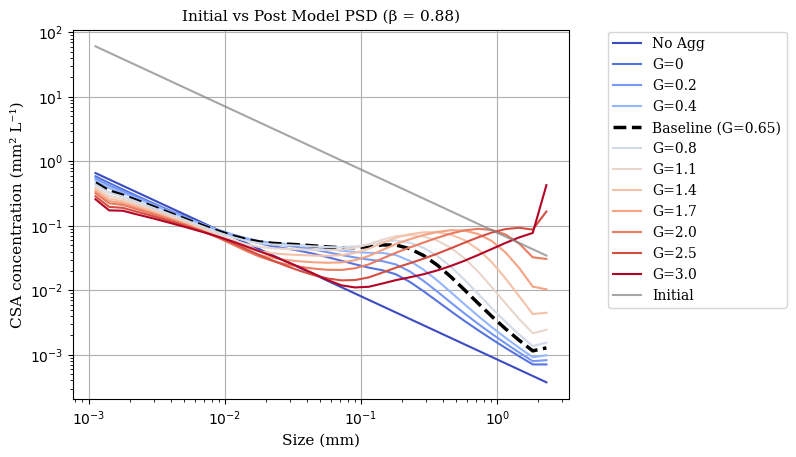

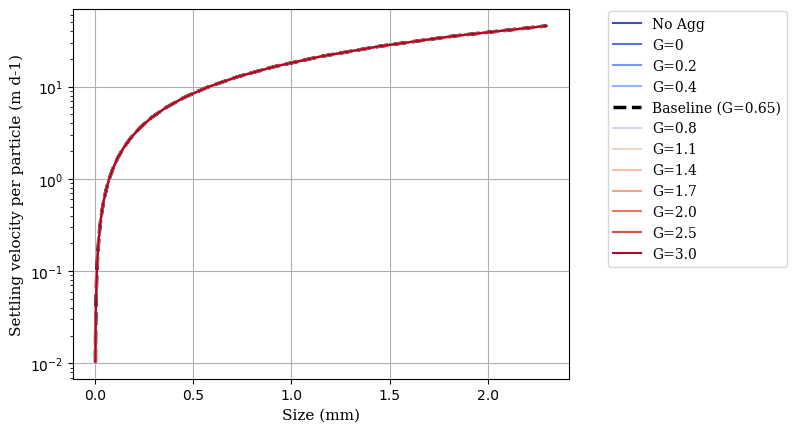

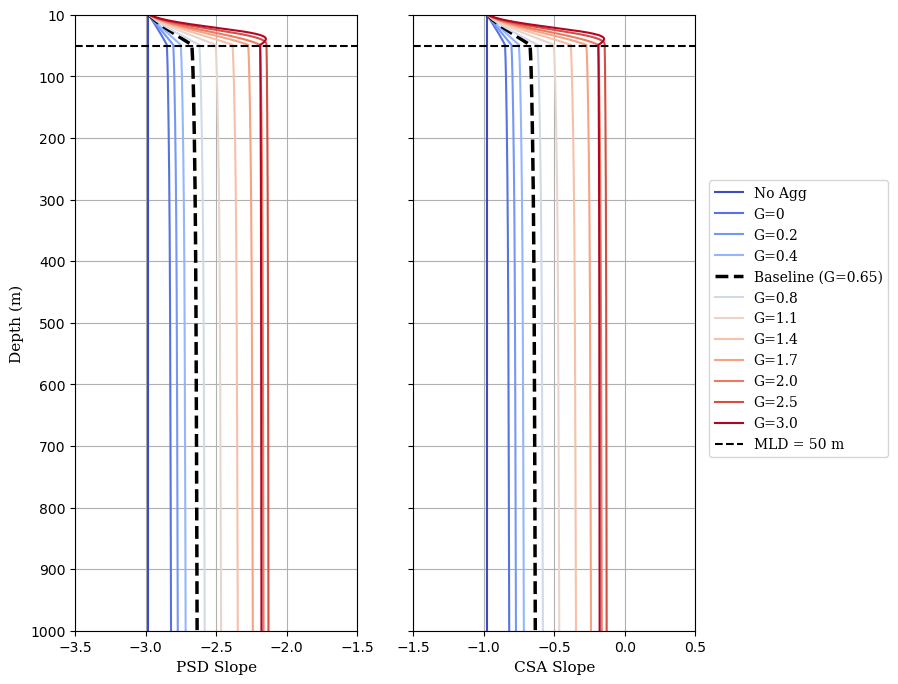

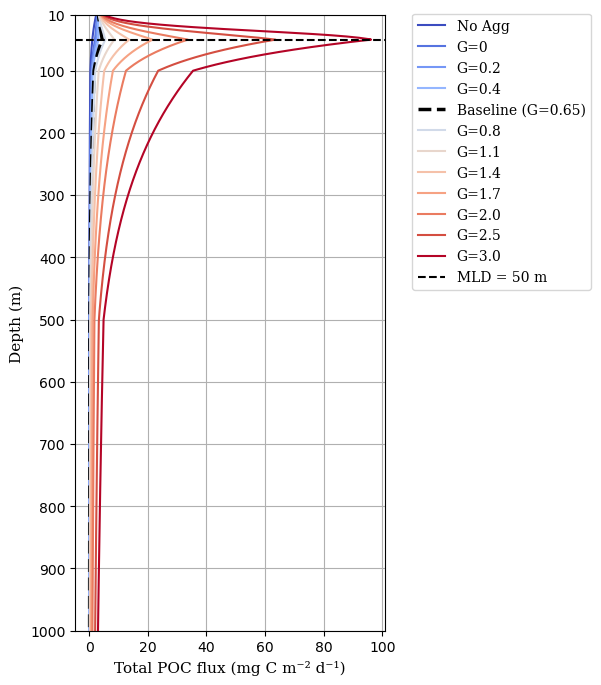

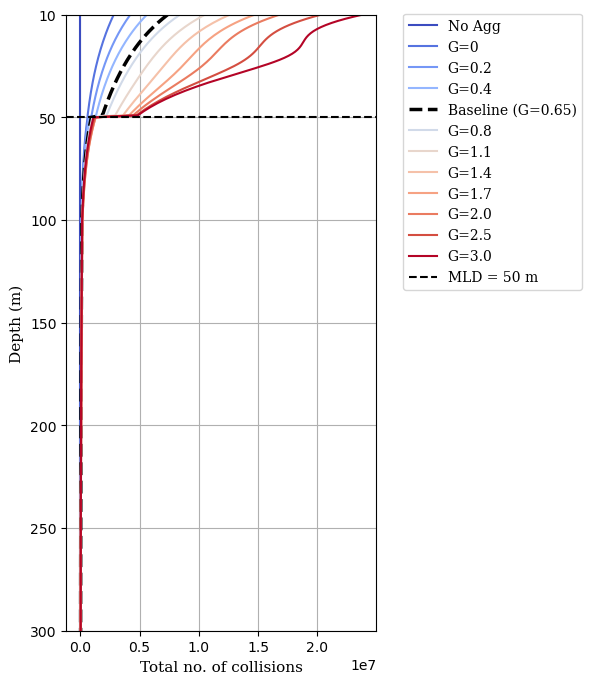

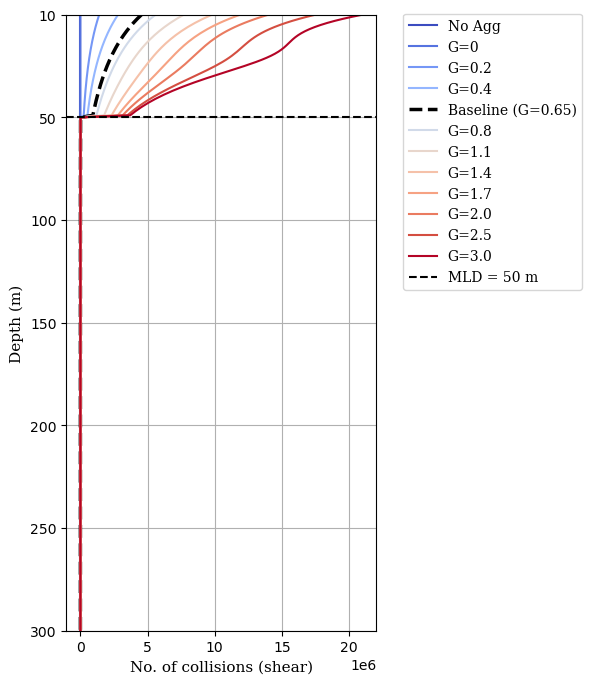

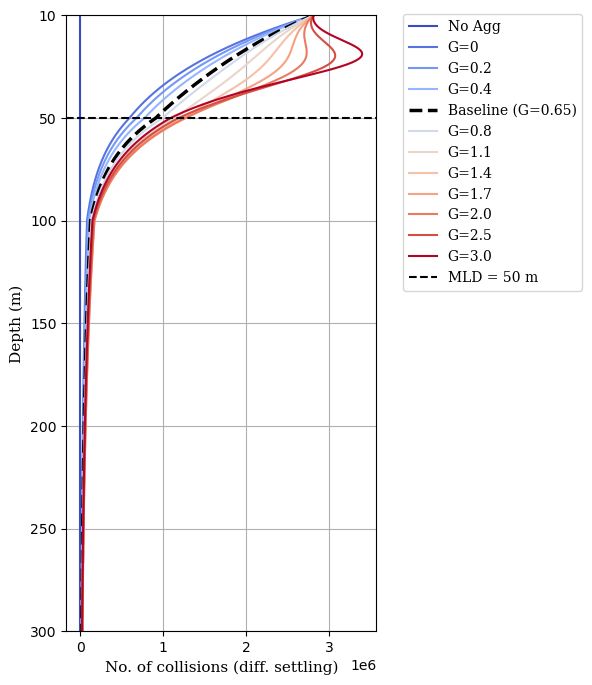

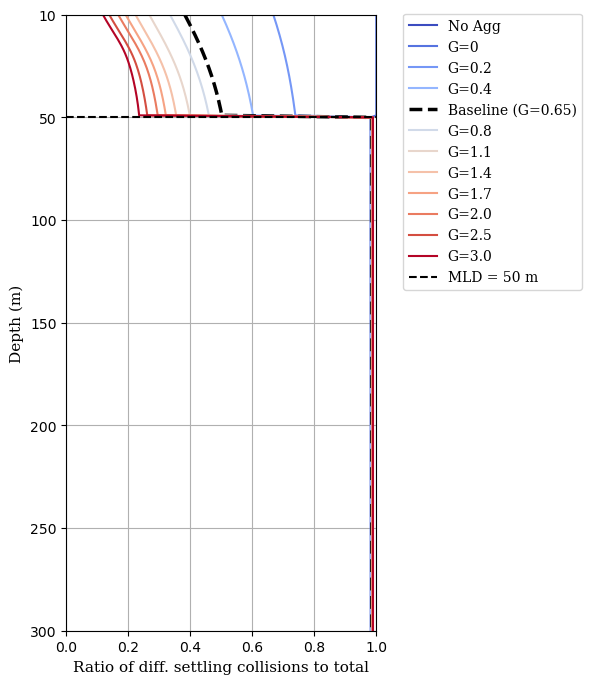

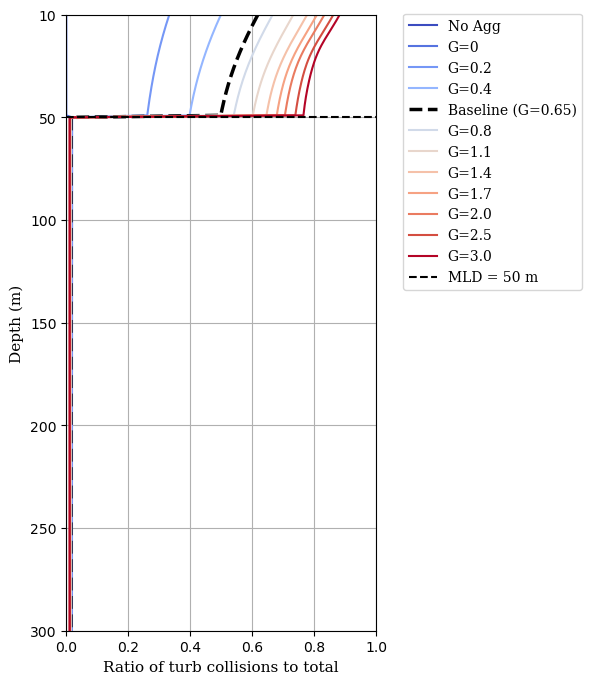

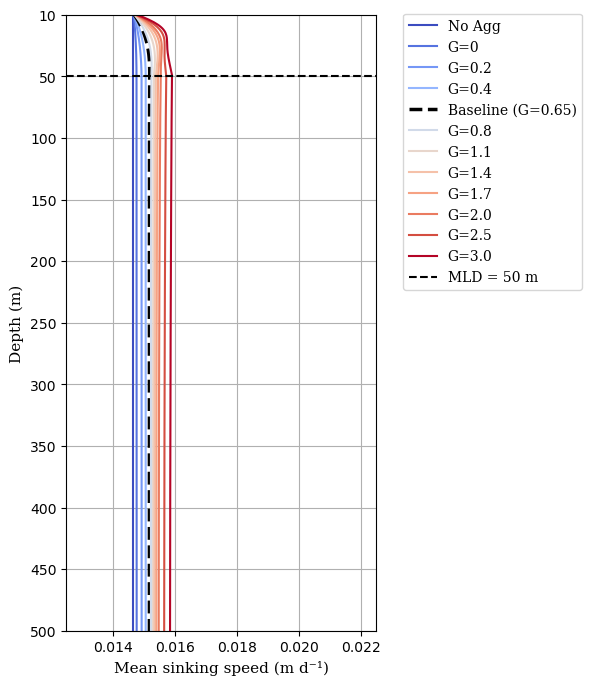

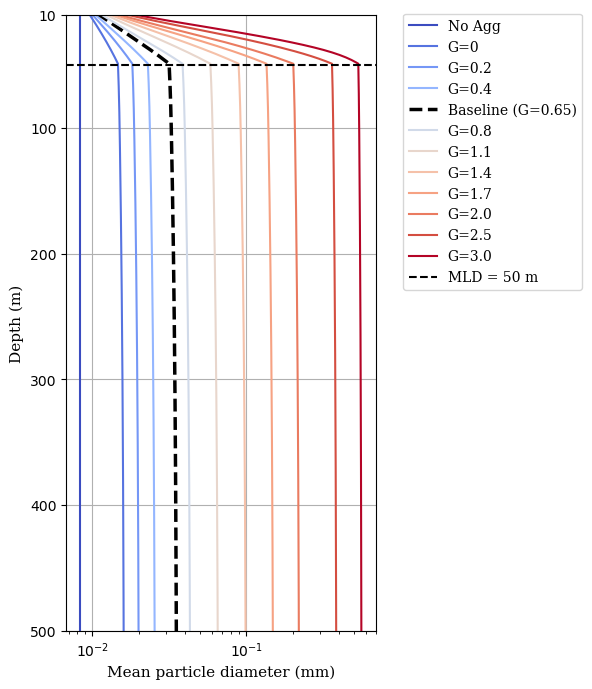

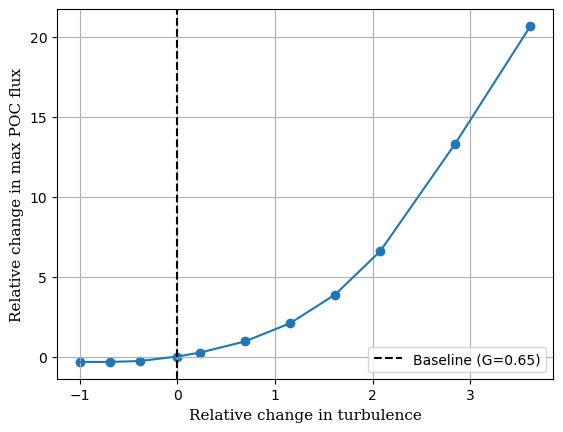

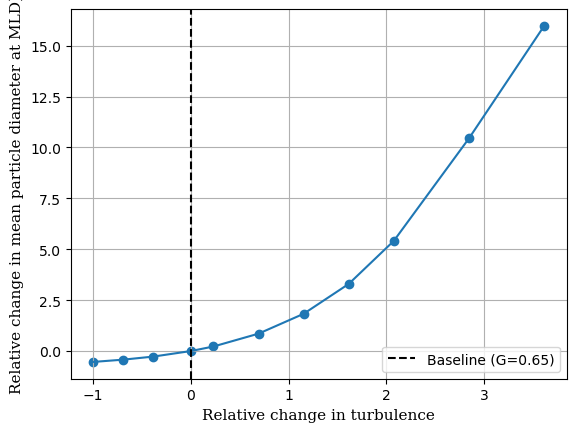

(11,) (11,)


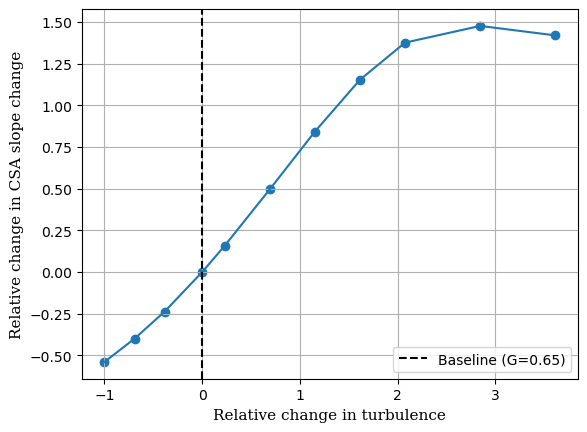

In [81]:
# SENSITIVITY ANALYSIS FOR PRE-BLOOM TURBULENCE    # need to change variable names

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]
    state_variables["diff_ratio"] = state_variables["diff_aggs"] / state_variables["aggs"]
    state_variables["turb_ratio"] = state_variables["turb_aggs"] / state_variables["aggs"]

    return state_variables


# DF RUNS # change this for each parameter

pre_bloom_turb_runs = {
    "No Agg": "F490_P3_no_agg",
    "G=0": "F490_P3_G_0",
    "G=0.2": "F490_P3_G_0.2",
    "G=0.4": "F490_P3_G_0.4",
    "G=0.65": "F490_P3_G_0.65",     # baseline
    "G=0.8": "F490_P3_G_0.8",
    "G=1.1": "F490_P3_G_1.1",
    "G=1.4": "F490_P3_G_1.4",
    "G=1.7": "F490_P3_G_1.7",
    "G=2.0": "F490_P3_G_2.0",
    "G=2.5": "F490_P3_G_2.5",
    "G=3.0": "F490_P3_G_3.0",
}


pre_bloom_turb_results = {label: load_run(filename)
                         for label, filename in pre_bloom_turb_runs.items()}

#print(pre_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_turb_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_turb_results["G=0.65"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(0, 1000)
    a.set_yticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    #ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
    a.set_yticklabels(["10", "100", "200", "300", "400", "500", "600", "700", "800", "900", "1000"])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_xscale("log")
#ax.set_xlim(10**-1, 10**7)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TOTAL NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### SHEAR NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["turb_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions (shear)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.ticklabel_format(style="sci", axis="x", scilimits=(6, 6))
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### DIFF SETTLING NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["diff_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions (diff. settling)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### DIFF SETTLING NO. OF AGGREGATIONS PLOT (RATIO)

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["diff_ratio"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Ratio of diff. settling collisions to total", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.set_xlim(0, 1.0)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TURB NO. OF AGGREGATIONS PLOT (RATIO)

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["turb_ratio"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Ratio of turb collisions to total", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.set_xlim(0, 1.0)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()






### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 500)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.set_xlim(0.0125, 0.0225)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=0.65":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=0.65)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_turb = 0.65
baseline_poc = np.max(pre_bloom_turb_results["G=0.65"]["poc_flux"]) 

delta_pre_bloom_turb = []
delta_poc_turb = []

for label, run in pre_bloom_turb_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_turb.append((parameter - baseline_turb) / baseline_turb)

    delta_poc_turb.append((max_poc - baseline_poc) / baseline_poc)

# Sort by df value for plotting
order = np.argsort(delta_pre_bloom_turb)

delta_parameter = np.array(delta_pre_bloom_turb)[order]
delta_poc_turb = np.array(delta_poc_turb)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_turb, delta_poc_turb)
ax.plot(delta_pre_bloom_turb, delta_poc_turb)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=0.65)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_turb = 0.65
baseline_diameter = (pre_bloom_turb_results["G=0.65"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_turb = []
delta_diameter_turb = []

for label, run in pre_bloom_turb_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_turb.append((df - baseline_turb) / baseline_turb)
    delta_diameter_turb.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_turb = np.array(delta_pre_bloom_turb)[order]
delta_diameter_turb = np.array(delta_diameter_turb)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_turb, delta_diameter_turb)
ax.plot(delta_pre_bloom_turb, delta_diameter_turb)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=0.65)")

ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
baseline_turb = 0.65 # change this when needed

'''
print(type(pre_bloom_turb_results["df=2.1"]["csa_slope"]))
print(np.asarray(pre_bloom_turb_results["df=2.1"]["csa_slope"]).shape)
'''

baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_turb_results["G=0.65"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_turb = []
delta_csa_change_turb = []

for label, run in pre_bloom_turb_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_turb.append((df - baseline_turb) / baseline_turb)

    delta_csa_change_turb.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_pre_bloom_turb)

delta_pre_bloom_turb = np.array(delta_pre_bloom_turb)[order]
delta_csa_change_turb = np.array(delta_csa_change_turb)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_turb), np.shape(delta_csa_change_turb))

ax.scatter(delta_pre_bloom_turb, delta_csa_change_turb)
ax.plot(delta_pre_bloom_turb, delta_csa_change_turb)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=0.65)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()



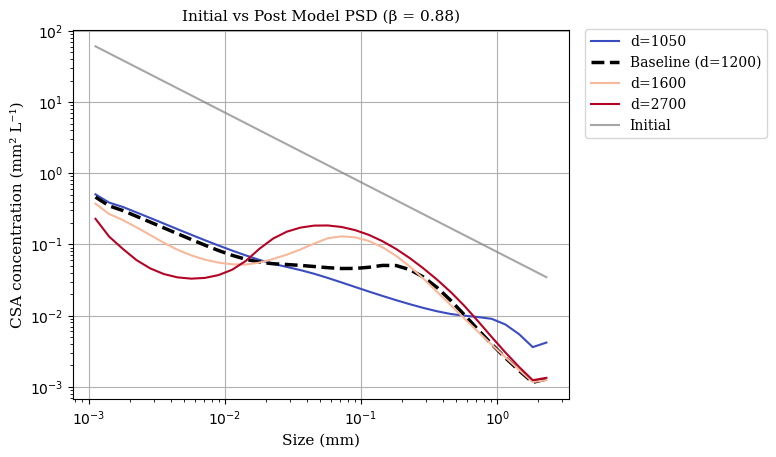

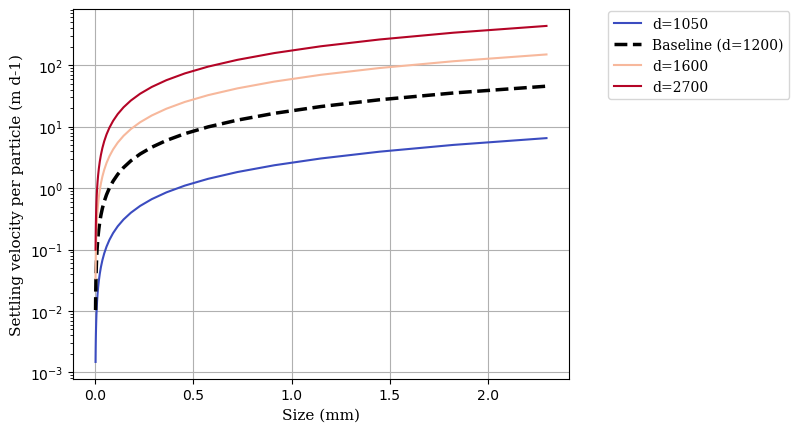

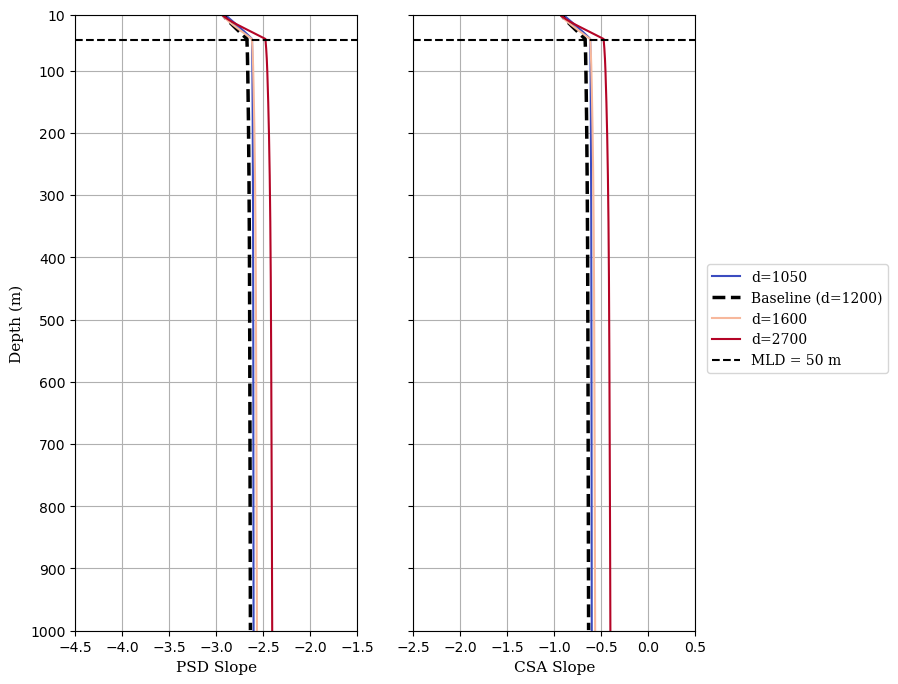

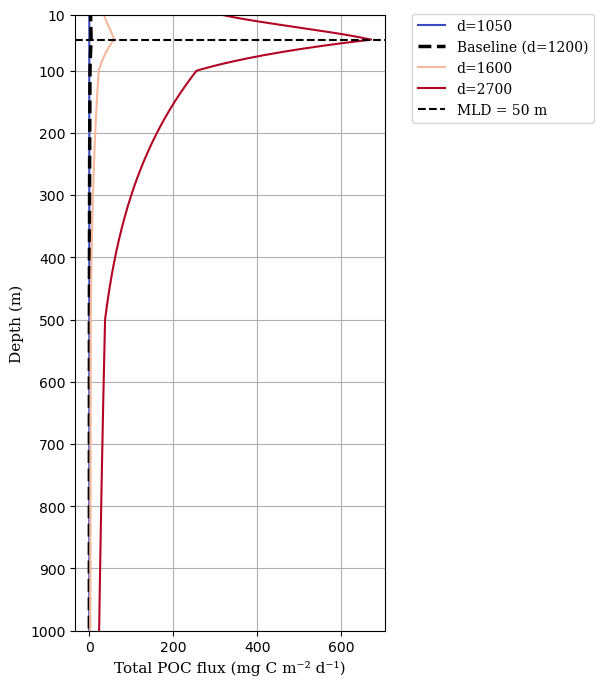

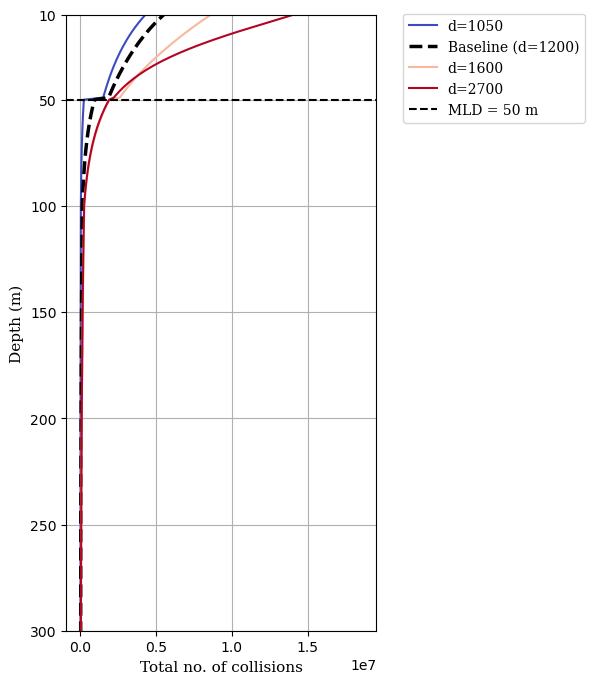

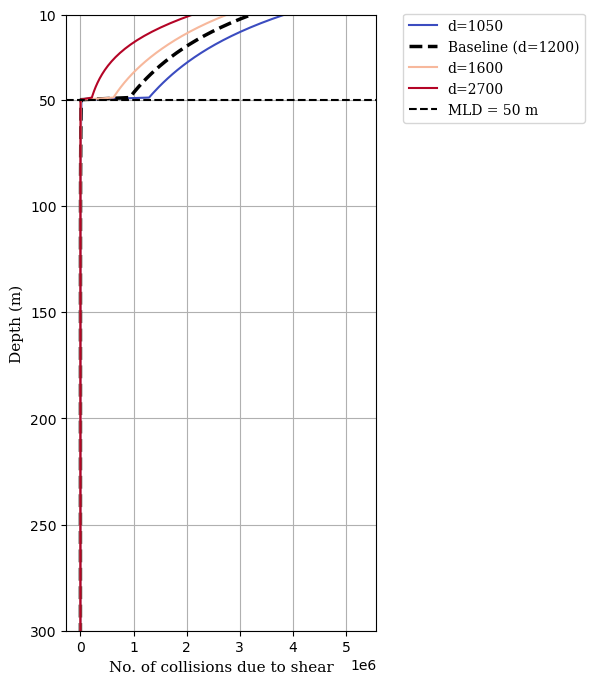

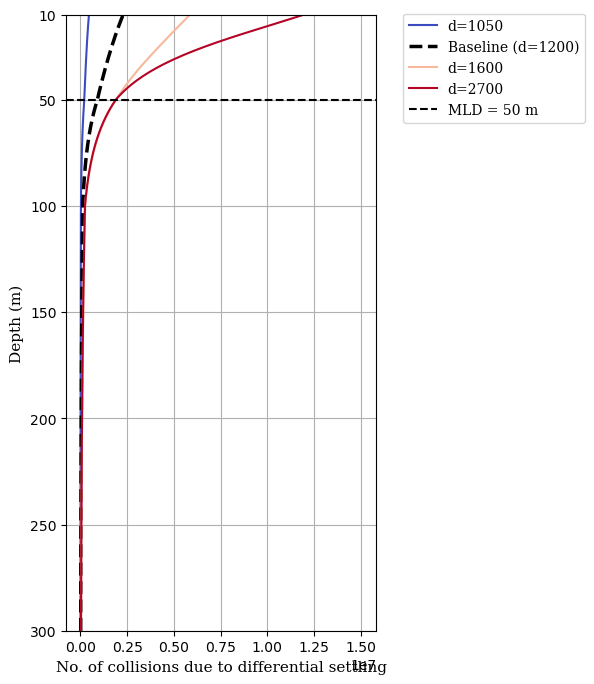

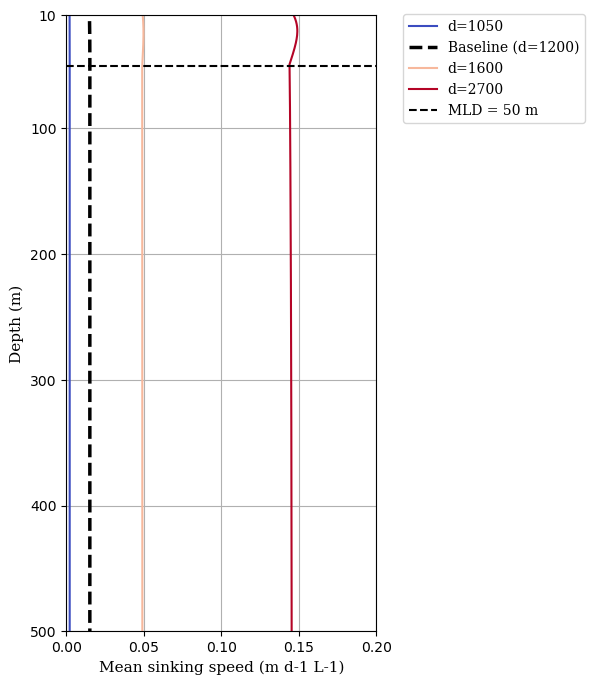

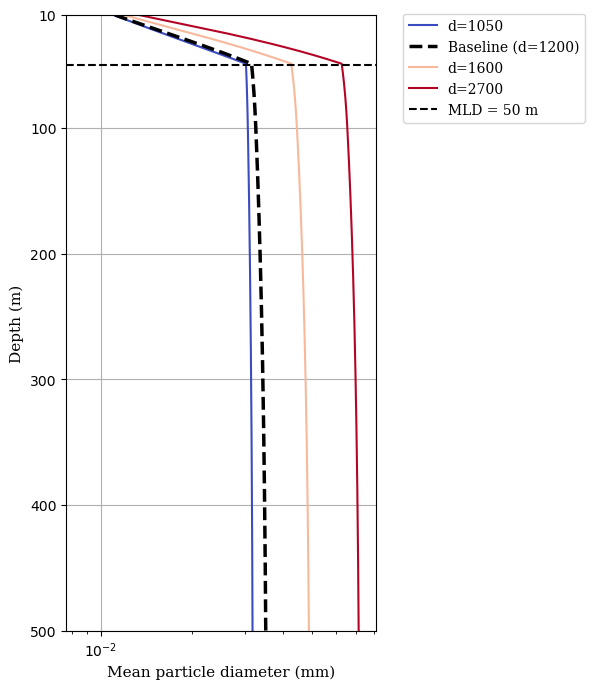

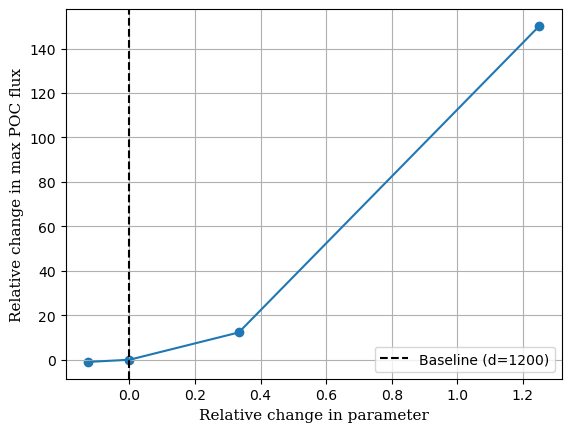

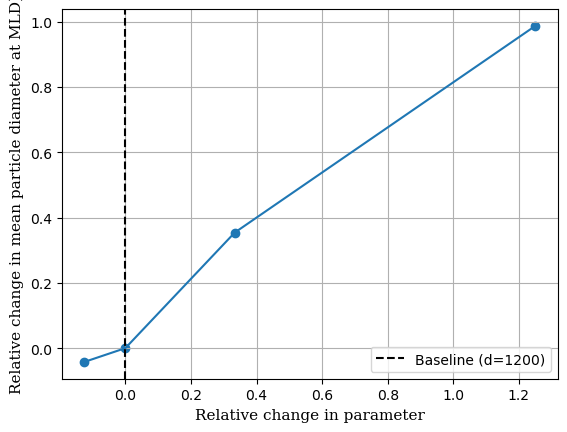

(4,) (4,)


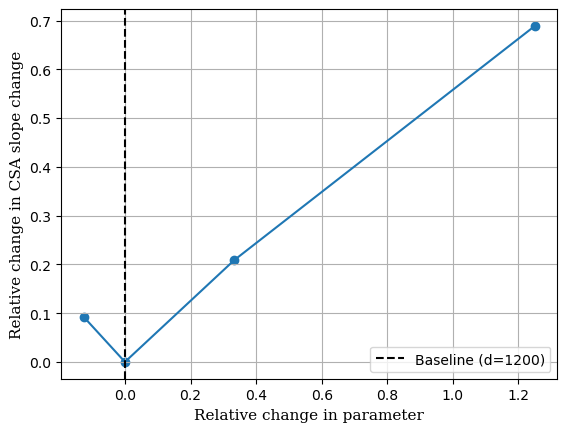

'\n# ALL VARIABLES SENSITIVITY ANALYSIS GRAPHS\n# TEST\nx_common = np.unique(\n    np.concatenate([\n        delta_pre_bloom_df,\n        delta_pre_bloom_stickiness,\n        delta_pre_bloom_turb\n    ])\n)\n\ny_df = np.interp(x_common, delta_pre_bloom_df, delta_poc_df)\ny_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_poc_stick)\ny_turb = np.interp(x_common, delta_pre_bloom_turb, delta_poc_turb)\n\n\nfig, ax = plt.subplots()\n\nax.plot(x_common, y_df, label="Fractal Dimension")\nax.plot(x_common, y_stick, label="Stickiness")\nax.plot(x_common, y_turb, label="Turbulence")\nax.axvline(x=0,color="black",linestyle="--",label="Baseline")\n#ax.axhline(y=0,color="grey",linestyle=":")\nax.set_xticks(x_common)\nax.set_xlabel("Relative change in parameter",fontdict=font)\nax.set_ylabel("Relative change in max POC flux",fontdict=font)\nax.set_title("Sensitivity Analysis of max POC flux (pre-bloom)")\nax.legend()\nplt.show()\n\n\n\n# ORIGINAL\n\n# Max POC Flux\nfig, ax = plt.subplo

In [ ]:
# SENSITIVITY ANALYSIS FOR PRIMARY PARTICLE DENSITY    # need to change variable names

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# PP RUNS # change this for each parameter

pre_bloom_pp_runs = {
    "d=1050": "F490_P3_PP_1050",
    "d=1200": "F490_P3_PP_1200",
    "d=1600": "F490_P3_PP_1600",
    "d=2700": "F490_P3_PP_2700"
}


pre_bloom_pp_results = {label: load_run(filename)
                         for label, filename in pre_bloom_pp_runs.items()}

#print(pre_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_pp_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_pp_results["d=1200"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(1.22, 0.895), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-4.5, -1.5)
ax[1].set_xlim(-2.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_xscale("log")
#ax.set_xlim(10**-1, 10**7)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TOTAL NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### SHEAR NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["turb_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions due to shear", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### DIFF SETTLING NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["diff_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions due to differential settling", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
#ax.set_xscale("log")
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xlim(0, 0.2)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_pp = 1200
baseline_poc = np.max(pre_bloom_pp_results["d=1200"]["poc_flux"]) 

delta_pre_bloom_pp = []
delta_poc_pp = []

for label, run in pre_bloom_pp_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_pp.append((parameter - baseline_pp) / baseline_pp)

    delta_poc_pp.append((max_poc - baseline_poc) / baseline_poc)

# Sort by df value for plotting
order = np.argsort(delta_pre_bloom_pp)

delta_parameter = np.array(delta_pre_bloom_pp)[order]
delta_poc_pp = np.array(delta_poc_pp)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_pp, delta_poc_pp)
ax.plot(delta_pre_bloom_pp, delta_poc_pp)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
#baseline_turb = 0.65
baseline_diameter = (pre_bloom_pp_results["d=1200"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_pp = []
delta_diameter_pp = []

for label, run in pre_bloom_pp_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_pp.append((df - baseline_pp) / baseline_pp)
    delta_diameter_pp.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_pp = np.array(delta_pre_bloom_pp)[order]
delta_diameter_pp = np.array(delta_diameter_pp)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_pp, delta_diameter_pp)
ax.plot(delta_pre_bloom_pp, delta_diameter_pp)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")

ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
#baseline_turb = 0.65 # change this when needed



baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_pp_results["d=1200"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_pp = []
delta_csa_change_pp = []

for label, run in pre_bloom_pp_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_pp.append((df - baseline_pp) / baseline_pp)

    delta_csa_change_pp.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_pre_bloom_pp)

delta_pre_bloom_pp = np.array(delta_pre_bloom_pp)[order]
delta_csa_change_pp = np.array(delta_csa_change_pp)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_pp), np.shape(delta_csa_change_pp))

ax.scatter(delta_pre_bloom_pp, delta_csa_change_pp)
ax.plot(delta_pre_bloom_pp, delta_csa_change_pp)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()



# WOULD NEED TO DO THIS FOR MID BLOOM
'''



def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# PP RUNS # change this for each parameter

pre_bloom_pp_runs = {
    "d=1050": "F490_P3_PP_1050",
    "d=1200": "F490_P3_PP_1200",
    "d=1600": "F490_P3_PP_1600",
    "d=2700": "F490_P3_PP_2700"
}


pre_bloom_pp_results = {label: load_run(filename)
                         for label, filename in pre_bloom_pp_runs.items()}

#print(pre_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_pp_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_pp_results["d=1200"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(1.22, 0.895), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-4.5, -1.5)
ax[1].set_xlim(-2.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_xscale("log")
#ax.set_xlim(10**-1, 10**7)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TOTAL NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### SHEAR NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["turb_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions due to shear", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### DIFF SETTLING NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["diff_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions due to differential settling", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
#ax.set_xscale("log")
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xlim(0, 0.2)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_pp_results.items()):

    lw = 1.5
    ls = "-"

    if label == "d=1200":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (d=1200)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_pp = 1200
baseline_poc = np.max(pre_bloom_pp_results["d=1200"]["poc_flux"]) 

delta_pre_bloom_pp = []
delta_poc_pp = []

for label, run in pre_bloom_pp_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_pp.append((parameter - baseline_pp) / baseline_pp)

    delta_poc_pp.append((max_poc - baseline_poc) / baseline_poc)

# Sort by df value for plotting
order = np.argsort(delta_pre_bloom_pp)

delta_parameter = np.array(delta_pre_bloom_pp)[order]
delta_poc_pp = np.array(delta_poc_pp)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_pp, delta_poc_pp)
ax.plot(delta_pre_bloom_pp, delta_poc_pp)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
#baseline_turb = 0.65
baseline_diameter = (pre_bloom_pp_results["d=1200"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_pp = []
delta_diameter_pp = []

for label, run in pre_bloom_pp_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_pp.append((df - baseline_pp) / baseline_pp)
    delta_diameter_pp.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_df)

delta_pre_bloom_pp = np.array(delta_pre_bloom_pp)[order]
delta_diameter_pp = np.array(delta_diameter_pp)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_pp, delta_diameter_pp)
ax.plot(delta_pre_bloom_pp, delta_diameter_pp)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")

ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
#baseline_turb = 0.65 # change this when needed



baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_pp_results["d=1200"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_pp = []
delta_csa_change_pp = []

for label, run in pre_bloom_pp_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_pp.append((df - baseline_pp) / baseline_pp)

    delta_csa_change_pp.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_pre_bloom_pp)

delta_pre_bloom_pp = np.array(delta_pre_bloom_pp)[order]
delta_csa_change_pp = np.array(delta_csa_change_pp)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_pp), np.shape(delta_csa_change_pp))

ax.scatter(delta_pre_bloom_pp, delta_csa_change_pp)
ax.plot(delta_pre_bloom_pp, delta_csa_change_pp)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (d=1200)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()



'''
# ALL VARIABLES SENSITIVITY ANALYSIS GRAPHS
# TEST
x_common = np.unique(
    np.concatenate([
        delta_pre_bloom_df,
        delta_pre_bloom_stickiness,
        delta_pre_bloom_turb
    ])
)

y_df = np.interp(x_common, delta_pre_bloom_df, delta_poc_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_poc_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_poc_turb)


fig, ax = plt.subplots()

ax.plot(x_common, y_df, label="Fractal Dimension")
ax.plot(x_common, y_stick, label="Stickiness")
ax.plot(x_common, y_turb, label="Turbulence")
ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xticks(x_common)
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)
ax.set_title("Sensitivity Analysis of max POC flux (pre-bloom)")
ax.legend()
plt.show()



# ORIGINAL

# Max POC Flux
fig, ax = plt.subplots()
#ax.scatter(delta_pre_bloom_df, delta_poc_df, label="Fractal Dimension")
#ax.plot(delta_pre_bloom_df, delta_poc_df)
ax.scatter(delta_pre_bloom_stickiness, delta_poc_stick, label="Stickiness")
ax.plot(delta_pre_bloom_stickiness, delta_poc_stick)
ax.scatter(delta_pre_bloom_turb, delta_poc_turb, label="Turbulence")
ax.plot(delta_pre_bloom_turb, delta_poc_turb)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)
ax.set_title("Sensitivity Analysis of max POC flux (pre-bloom)")

ax.grid()
ax.legend()
plt.show()





# TEST
x_common = np.unique(
    np.concatenate([
        delta_pre_bloom_df,
        delta_pre_bloom_stickiness,
        delta_pre_bloom_turb
    ])
)

y_df = np.interp(x_common, delta_pre_bloom_df, delta_diameter_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_diameter_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_diameter_turb)


fig, ax = plt.subplots()

ax.plot(x_common, y_df, label="Fractal Dimension")
ax.plot(x_common, y_stick, label="Stickiness")
ax.plot(x_common, y_turb, label="Turbulence")
ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xticks(x_common)
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in mean MLD diameter flux",fontdict=font)
ax.set_title("Sensitivity Analysis of mean MLD diameter (pre-bloom)")
ax.legend()
plt.show()



# Mean Particle Diameter at MLD
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_df, delta_diameter, label="Fractal Dimension")
ax.plot(delta_pre_bloom_df, delta_diameter)
ax.scatter(delta_pre_bloom_stickiness, delta_diameter, label="Stickiness")
ax.plot(delta_pre_bloom_stickiness, delta_diameter)

#ax.scatter(delta_pre_bloom_shear, delta_diameter)
#ax.plot(delta_pre_bloom_shear, delta_diameter)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in MLD mean particle diameter",fontdict=font)
ax.set_title("Sensitivity Analysis of MLD mean particle diameter (pre-bloom)")

ax.grid()
ax.legend()
plt.show()





# TEST
x_common = np.unique(
    np.concatenate([
        delta_pre_bloom_df,
        delta_pre_bloom_stickiness,
        delta_pre_bloom_turb
    ])
)

y_df = np.interp(x_common, delta_pre_bloom_df, delta_csa_change_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_csa_change_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_csa_change_turb)


fig, ax = plt.subplots()

ax.plot(x_common, y_df, label="Fractal Dimension")
ax.plot(x_common, y_stick, label="Stickiness")
ax.plot(x_common, y_turb, label="Turbulence")
ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xticks(x_common)
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)
ax.set_title("Sensitivity Analysis of CSA slope change (pre-bloom)")
ax.legend()
plt.show()


# CSA slope change
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_df, delta_csa_change, label="Fractal Dimension")
ax.plot(delta_pre_bloom_df, delta_csa_change)
ax.scatter(delta_pre_bloom_stickiness, delta_csa_change, label="Stickiness")
ax.plot(delta_pre_bloom_stickiness, delta_csa_change)

#ax.scatter(delta_pre_bloom_shear, delta_csa_change)
#ax.plot(delta_pre_bloom_shear, delta_csa_change)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in parameter",fontdict=font)
ax.set_ylabel("Relative change in CSA slope evolution",fontdict=font)
ax.set_title("Sensitivity Analysis of CSA slope evolution (pre-bloom)")

ax.grid()
ax.legend()
plt.show()



#fig, ax = plt.subplots()
#ax.scatter(delta_pre_bloom_df, delta_csa_change)
#ax.plot(delta_pre_bloom_df, delta_csa_change)
'''

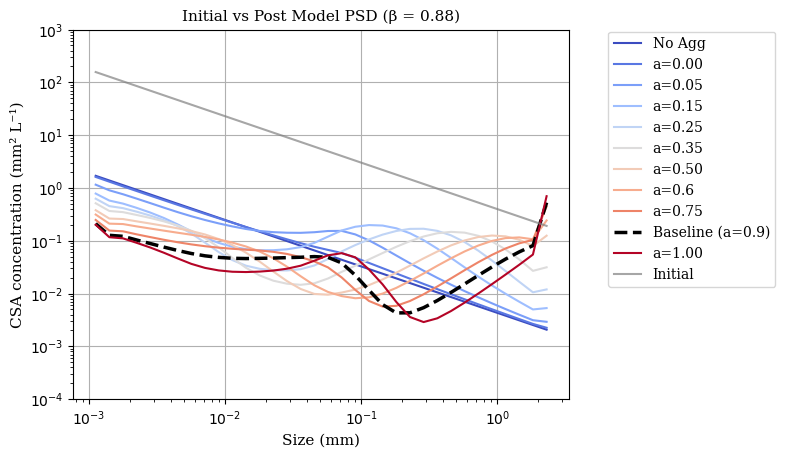

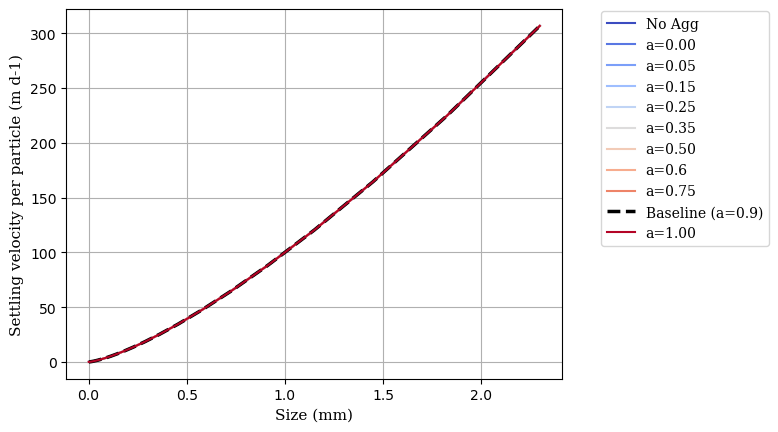

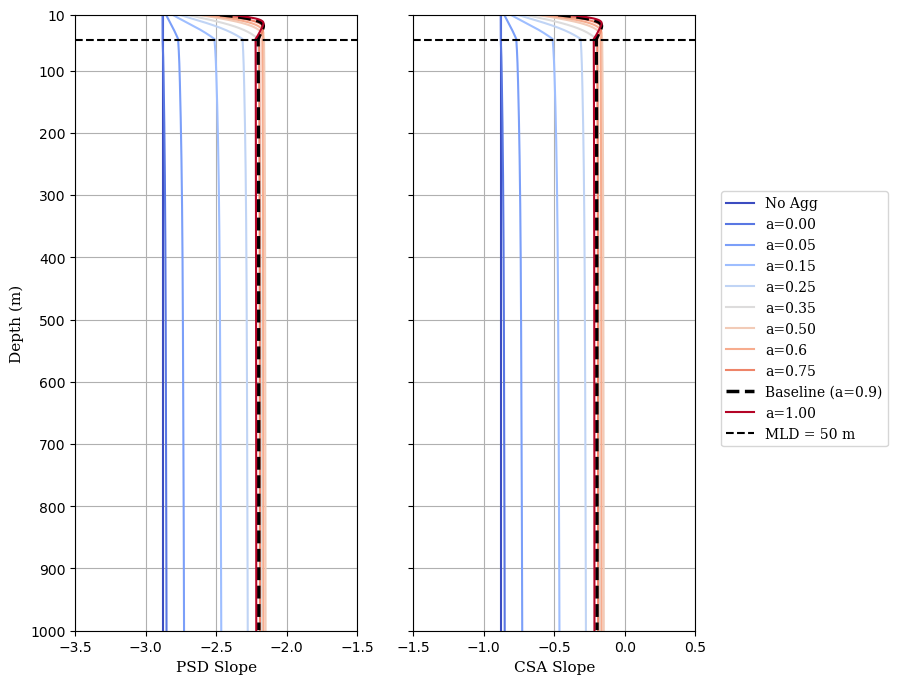

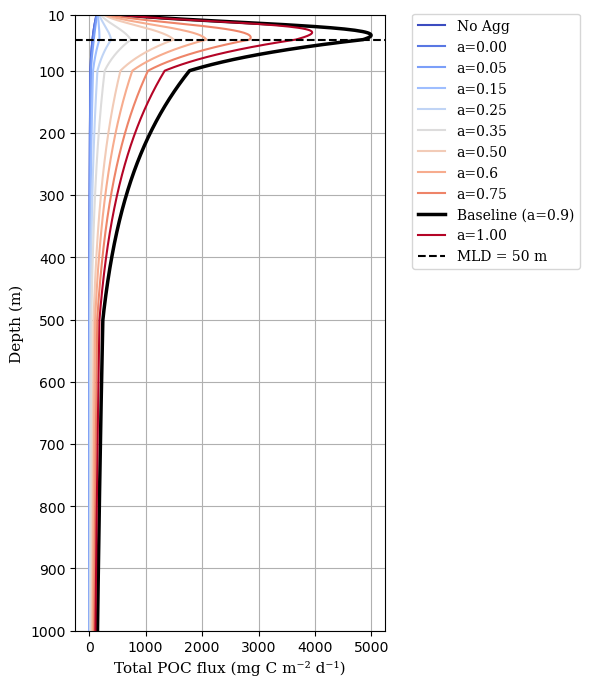

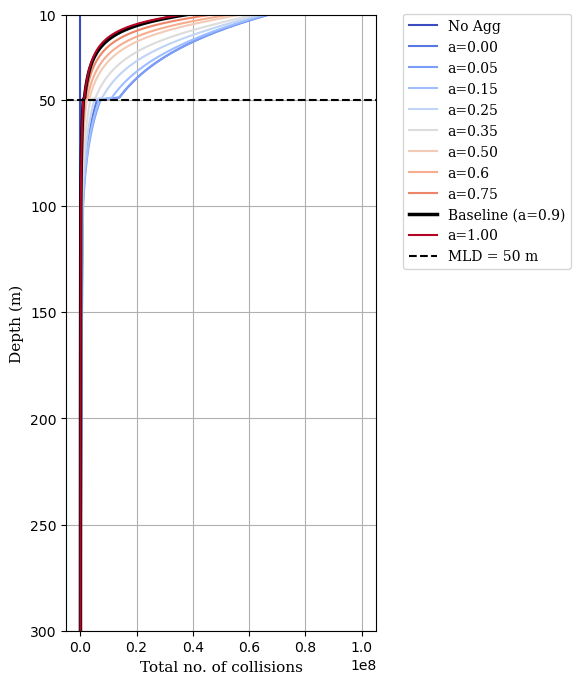

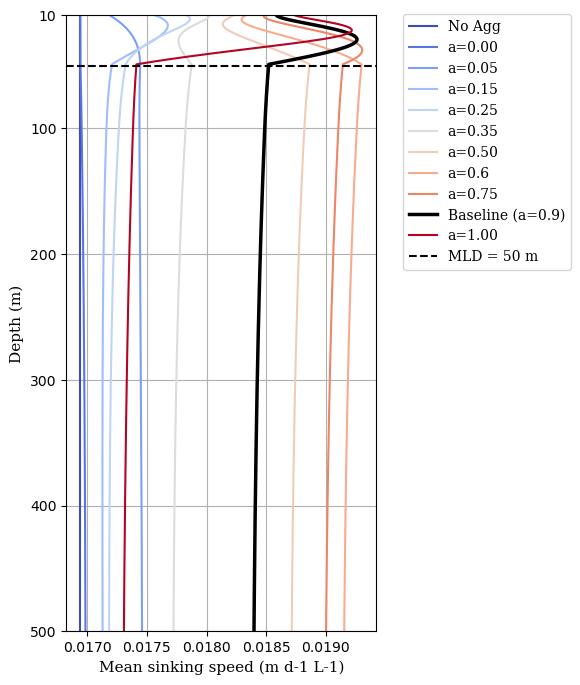

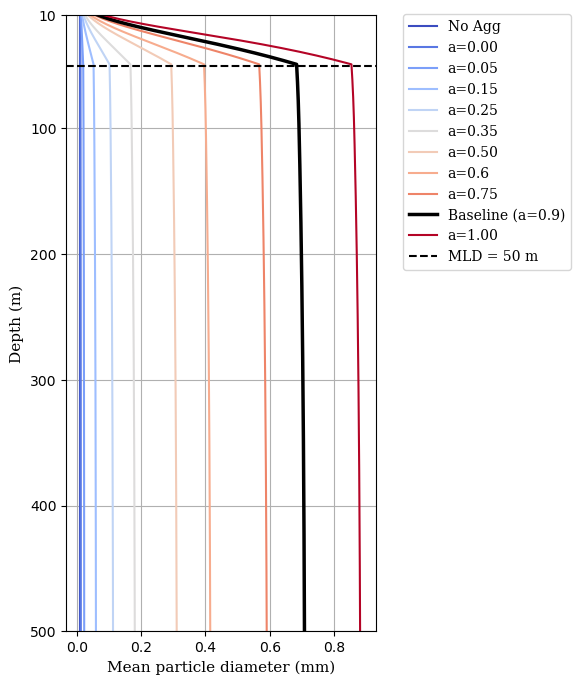

[-0.9229916333513508, -0.9229916333513508, -0.9126325902269106, -0.8120355353663901, -0.6449176663950283, -0.27809009408637364, 0.0, 0.37891269090383034, 1.4070349945119196, 0.9035116996922786]


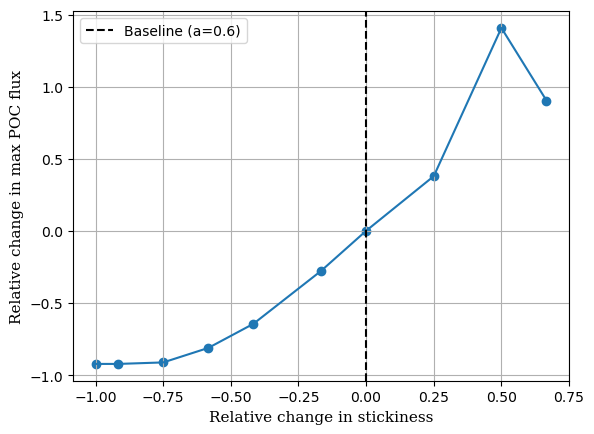

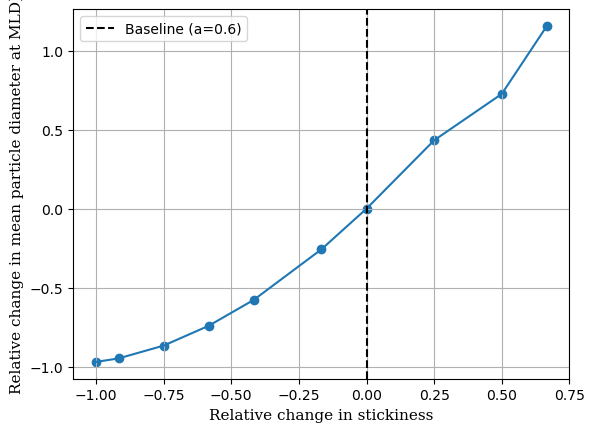

<class 'pandas.core.frame.DataFrame'>
(1000, 1)
(10,) (10,)


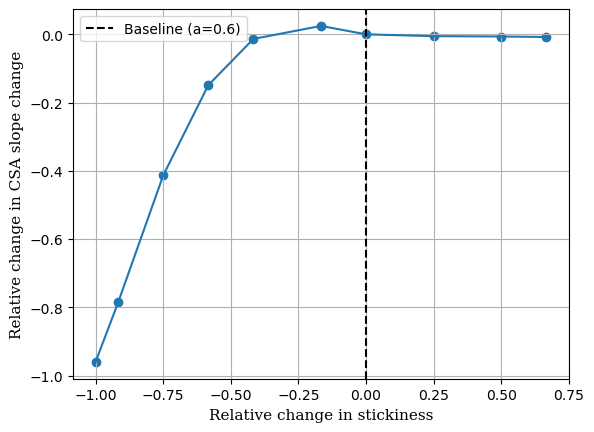

In [94]:
# SENSITIVITY ANALYSIS FOR MID-BLOOM STICKINESS

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# STICKINESS # change this for each parameter

mid_bloom_stickiness_runs = {
    "No Agg": "F490_P16_no_agg",
    "a=0.00": "F490_P16_a_0",
    "a=0.05": "F490_P16_a_0.05",
    "a=0.15": "F490_P16_a_0.15",
    "a=0.25": "F490_P16_a_0.25",     # baseline
    "a=0.35": "F490_P16_a_0.35",
    "a=0.50": "F490_P16_a_0.5",
    "a=0.6": "F490_P16_a_0.6",
    "a=0.75": "F490_P16_a_0.75",
    "a=0.90": "F490_P16_a_0.9",
    "a=1.00": "F490_P16_a_1.0",
}

mid_bloom_stickiness_results = {label: load_run(filename)
                         for label, filename in mid_bloom_stickiness_runs.items()}

#print(mid_bloom_stickiness_results["a=0.25"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(mid_bloom_stickiness_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.9)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, mid_bloom_stickiness_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = 0.88)", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.set_ylim(10**-4, 10**3)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.9)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, mid_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (a=0.9)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.9)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.9)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.9)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_stickiness_results.items()):

    lw = 1.5
    ls = "-"

    if label == "a=0.90":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (a=0.9)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xlim(0.014, 0.015)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_stickiness = 0.6 
baseline_poc = np.max(mid_bloom_stickiness_results["a=0.6"]["poc_flux"]) 

delta_mid_bloom_stickiness = []
delta_poc_stick = []

for label, run in mid_bloom_stickiness_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_mid_bloom_stickiness.append((parameter - baseline_stickiness) / baseline_stickiness)

    delta_poc_stick.append((max_poc - baseline_poc) / baseline_poc)

print(delta_poc_stick)

# Sort by stickiness value for plotting
order = np.argsort(delta_mid_bloom_stickiness)

delta_parameter = np.array(delta_mid_bloom_stickiness)[order]
delta_poc = np.array(delta_poc_stick)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_mid_bloom_stickiness, delta_poc_stick)
ax.plot(delta_mid_bloom_stickiness, delta_poc_stick)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.6)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_diameter = (mid_bloom_stickiness_results["a=0.6"]["mean_diameter"].iloc[mld_idx])

delta_mid_bloom_stickiness = []
delta_diameter_stick = []

for label, run in mid_bloom_stickiness_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    stickiness = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_mid_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)
    delta_diameter_stick.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_stickiness)

delta_mid_bloom_stickiness = np.array(delta_mid_bloom_stickiness)[order]
delta_diameter_stick = np.array(delta_diameter_stick)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_mid_bloom_stickiness, delta_diameter_stick)
ax.plot(delta_mid_bloom_stickiness, delta_diameter_stick)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.6)")

ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 

print(type(mid_bloom_stickiness_results["a=0.6"]["csa_slope"]))
print(np.asarray(mid_bloom_stickiness_results["a=0.6"]["csa_slope"]).shape)



baseline_csa_change = np.ptp(
    np.asarray(mid_bloom_stickiness_results["a=0.6"]["csa_slope"]))
 # change this when needed

delta_mid_bloom_stickiness = []
delta_csa_change_stick = []

for label, run in mid_bloom_stickiness_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    stickiness = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_mid_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)

    delta_csa_change_stick.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by stickiness value for plotting 
order = np.argsort(delta_mid_bloom_stickiness)

delta_mid_bloom_stickiness = np.array(delta_mid_bloom_stickiness)[order]
delta_csa_change_stick = np.array(delta_csa_change_stick)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_mid_bloom_stickiness), np.shape(delta_csa_change_stick))

ax.scatter(delta_mid_bloom_stickiness, delta_csa_change_stick)
ax.plot(delta_mid_bloom_stickiness, delta_csa_change_stick)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (a=0.6)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in stickiness",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


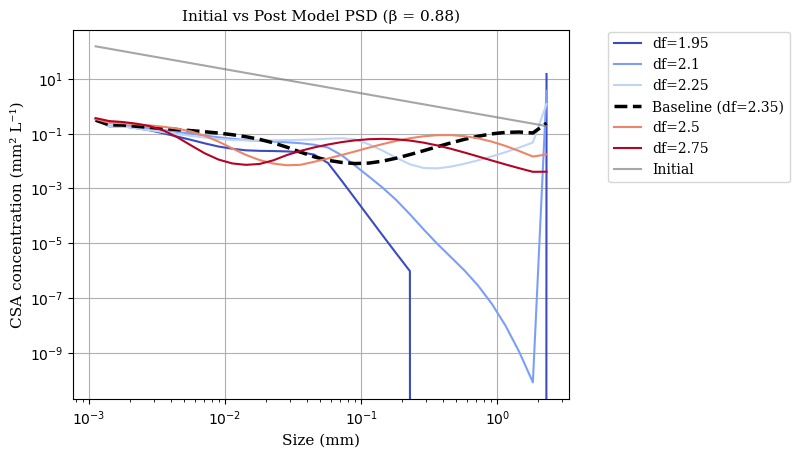

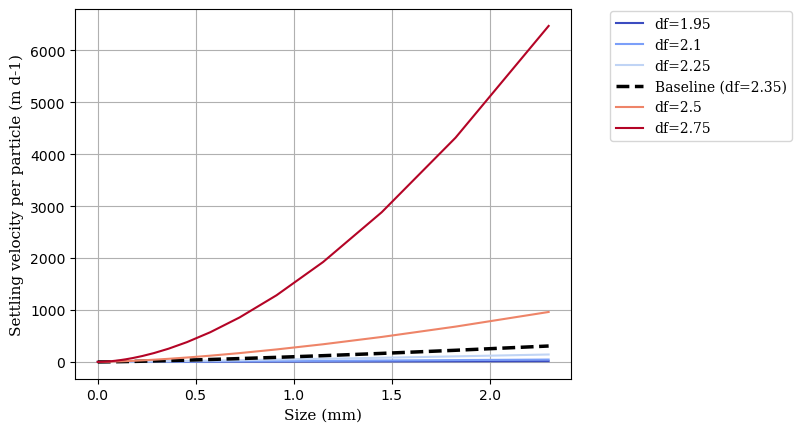

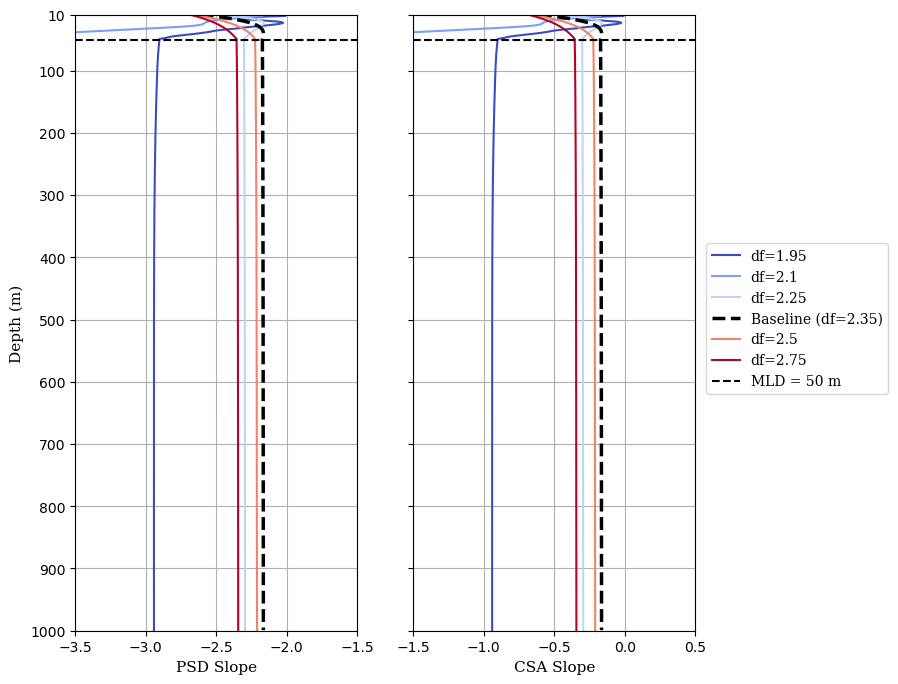

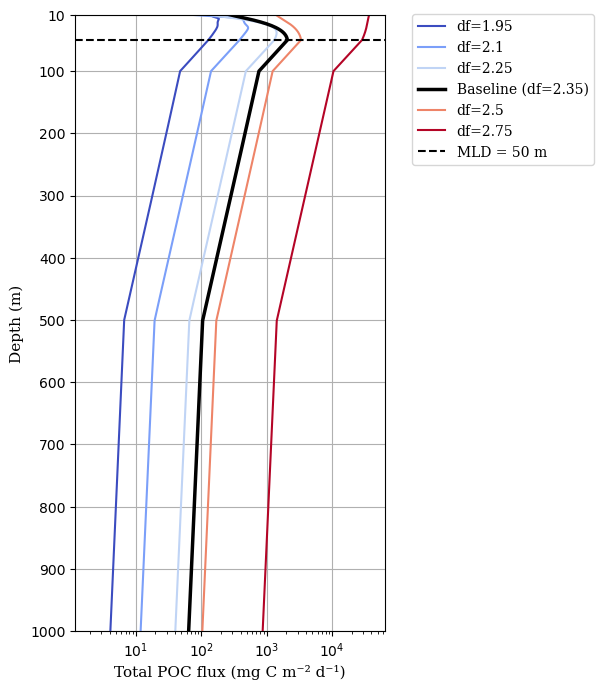

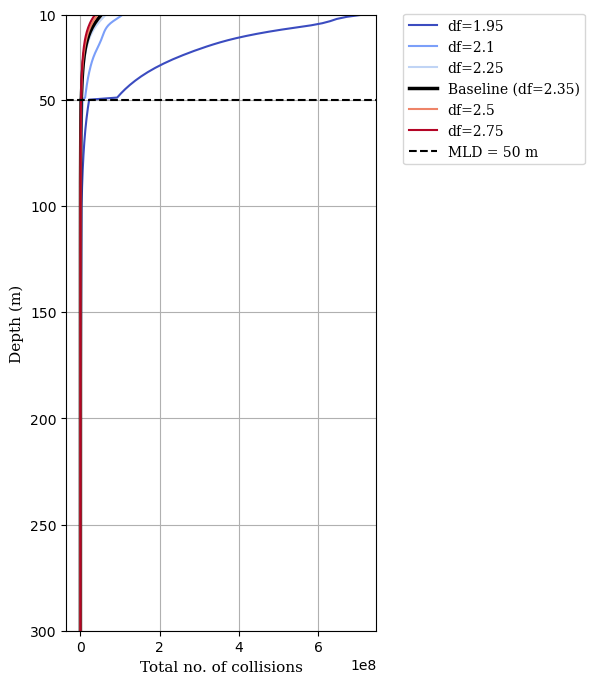

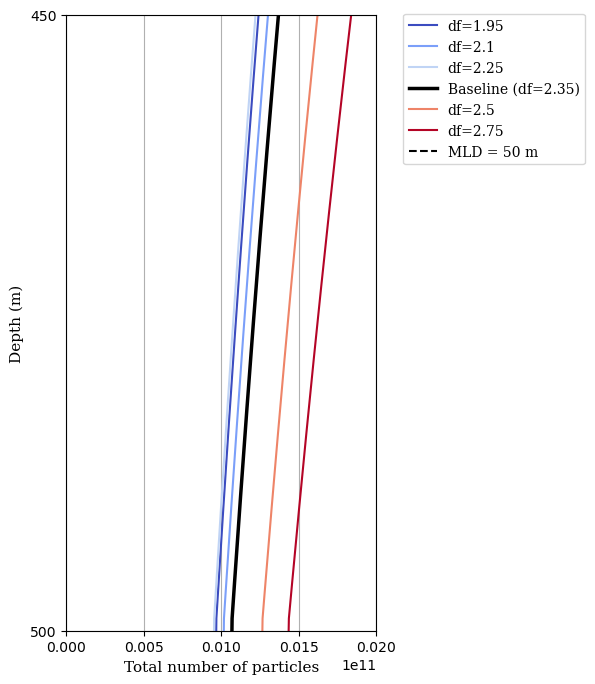

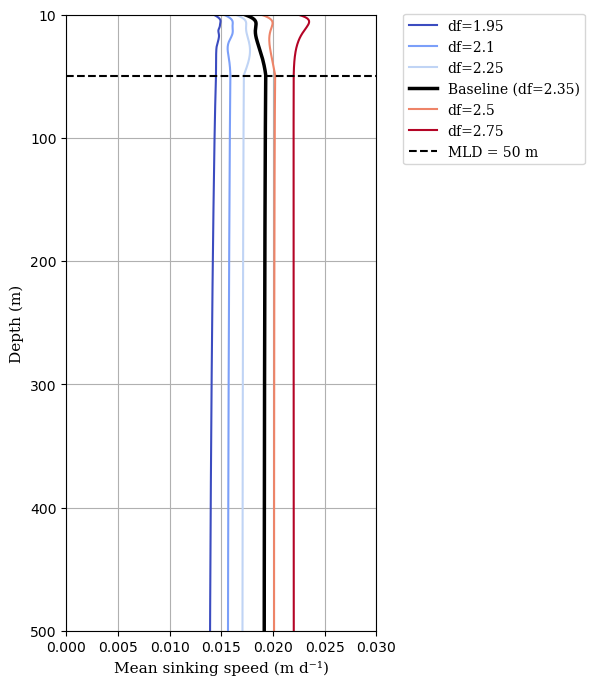

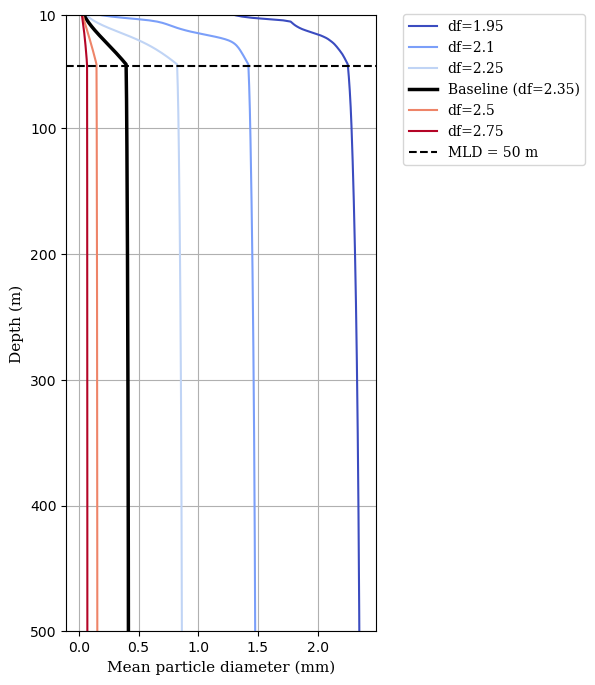

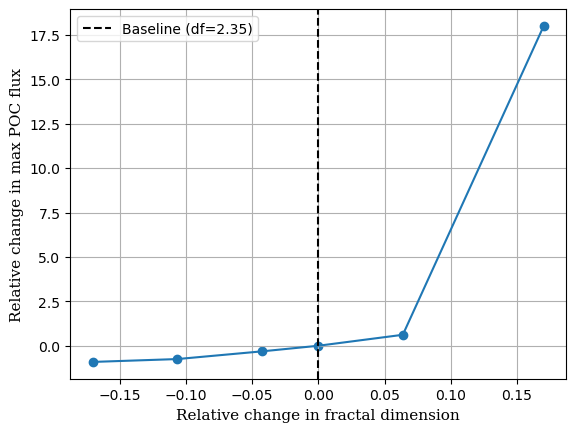

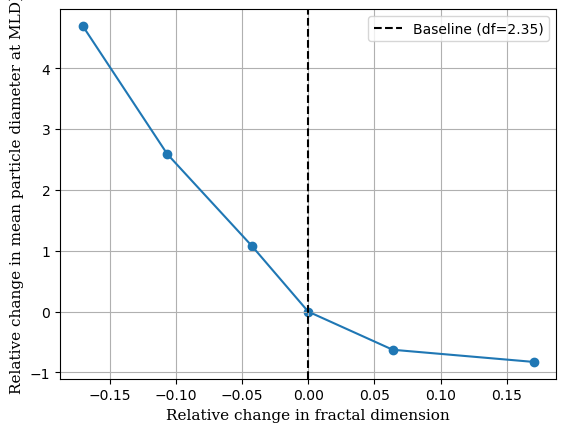

<class 'pandas.core.frame.DataFrame'>
(1000, 1)
(6,) (6,)


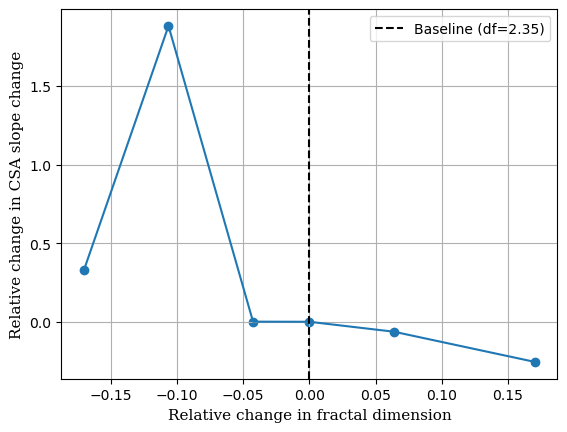

In [95]:
# SENSITIVITY ANALYSIS FOR MID-BLOOM FRACTAL DIMENSION

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# FRACTAL DIMENSION # change this for each parameter

mid_bloom_df_runs = {
    #"No Agg": "F490_P16_no_agg",
    #"df=1.35": "F490_P16_df_1.35",     # NEED TO RUN 1.35 AND 1.5 WITH NEW TUNING IF DESIRED
    #"df=1.5": "F490_P16_df_1.5",
    #"df=1.7": "F490_P16_df_1.7",
    "df=1.95": "F490_P16_df_1.95",     
    "df=2.1": "F490_P16_df_2.1",
    "df=2.25": "F490_P16_df_2.25",
    "df=2.35": "F490_P16_df_2.35",    # baseline change name
    "df=2.5": "F490_P16_df_2.5",
    "df=2.75": "F490_P16_df_2.75",
    #"df=3.00": "F490_P16_df_3.00",
}

mid_bloom_df_results = {label: load_run(filename)
                         for label, filename in mid_bloom_df_runs.items()}

#print(mid_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(mid_bloom_df_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (df=2.35)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, mid_bloom_df_results["df=2.35"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (df=2.35)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, mid_bloom_df_results["df=2.35"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (df=2.35)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.35)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_xscale("log")
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.35)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



# Number of particles at depth

N_dictionary = {}

for label, run in mid_bloom_df_results.items():

    M_profile = run["mass"]

    # Shape: (34, n_depths)
    N_profile = M_profile.div(particle_mass, axis=1) 

    # Shape: (n_depths,)
    N_total_profile = N_profile.sum(axis=1)

    N_dictionary[label] = N_total_profile


fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, N_total_profile) in zip(colors, N_dictionary.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.35)"

    ax.plot(N_total_profile, depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total number of particles", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(450, 500)
ax.set_yticks([450, 500])
ax.set_yticklabels(["450", "500"])
#ax.set_ylim(0, 500)
#ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
#ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.ticklabel_format(style="sci", axis="x", scilimits=(11, 11))
#ax.set_xscale("log")
ax.set_xlim(0, 2000000000)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()











### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.35)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 500)
#ax.set_xscale("log")
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_yticklabels([10, 100, 200, 300, 400, 500])
ax.set_xlim(0, 0.03)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_df_results.items()):

    lw = 1.5
    ls = "-"

    if label == "df=2.35":
        color = "black"
        lw = 2.5
        ls = "-"
        label = "Baseline (df=2.35)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xlim(0.014, 0.015)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_df = 2.35 
baseline_poc = np.max(mid_bloom_df_results["df=2.35"]["poc_flux"]) 

delta_mid_bloom_df = []
delta_poc_df = []

for label, run in mid_bloom_df_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_mid_bloom_df.append((parameter - baseline_df) / baseline_df)

    delta_poc_df.append((max_poc - baseline_poc) / baseline_poc)

# Sort by fractal dimension value for plotting
order = np.argsort(delta_mid_bloom_df)

delta_parameter = np.array(delta_mid_bloom_df)[order]
delta_poc_df = np.array(delta_poc_df)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_mid_bloom_df, delta_poc_df)
ax.plot(delta_mid_bloom_df, delta_poc_df)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.35)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_df = 2.35
baseline_diameter = (mid_bloom_df_results["df=2.35"]["mean_diameter"].iloc[mld_idx])

delta_mid_bloom_df = []
delta_diameter_df = []

for label, run in mid_bloom_df_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_mid_bloom_df.append((df - baseline_df) / baseline_df)
    delta_diameter_df.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_stickiness)

delta_mid_bloom_df = np.array(delta_mid_bloom_df)[order]
delta_diameter_df = np.array(delta_diameter_df)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_mid_bloom_df, delta_diameter_df)
ax.plot(delta_mid_bloom_df, delta_diameter_df)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.35)")

ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
baseline_df = 2.35 # change this when needed


print(type(mid_bloom_df_results["df=2.35"]["csa_slope"]))
print(np.asarray(mid_bloom_df_results["df=2.35"]["csa_slope"]).shape)



baseline_csa_change = np.ptp(
    np.asarray(mid_bloom_df_results["df=2.35"]["csa_slope"]))
 # change this when needed

delta_mid_bloom_df = []
delta_csa_change_df = []

for label, run in mid_bloom_df_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_mid_bloom_df.append((df - baseline_df) / baseline_df)

    delta_csa_change_df.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_mid_bloom_df)

delta_mid_bloom_df = np.array(delta_mid_bloom_df)[order]
delta_csa_change_df = np.array(delta_csa_change_df)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_mid_bloom_df), np.shape(delta_csa_change_df))

ax.scatter(delta_mid_bloom_df, delta_csa_change_df)
ax.plot(delta_mid_bloom_df, delta_csa_change_df)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (df=2.35)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in fractal dimension",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


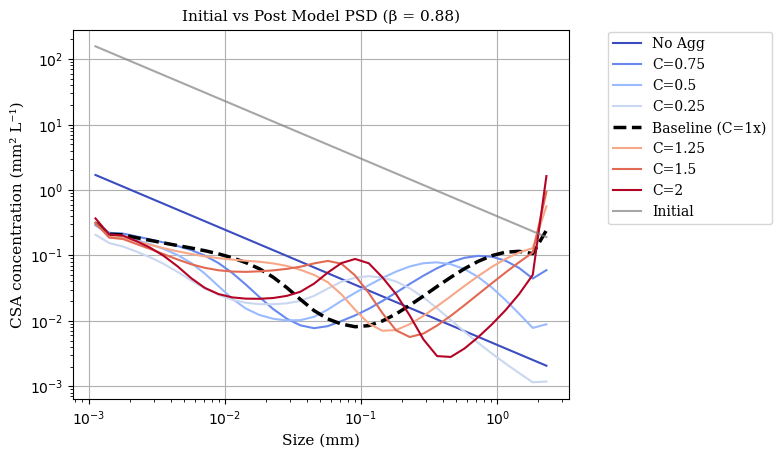

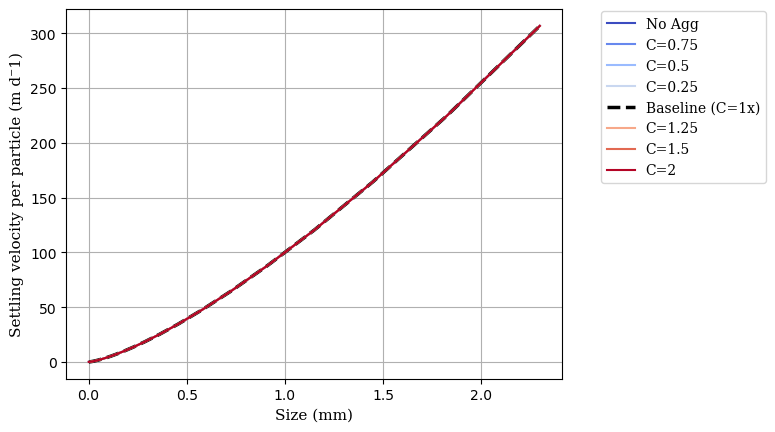

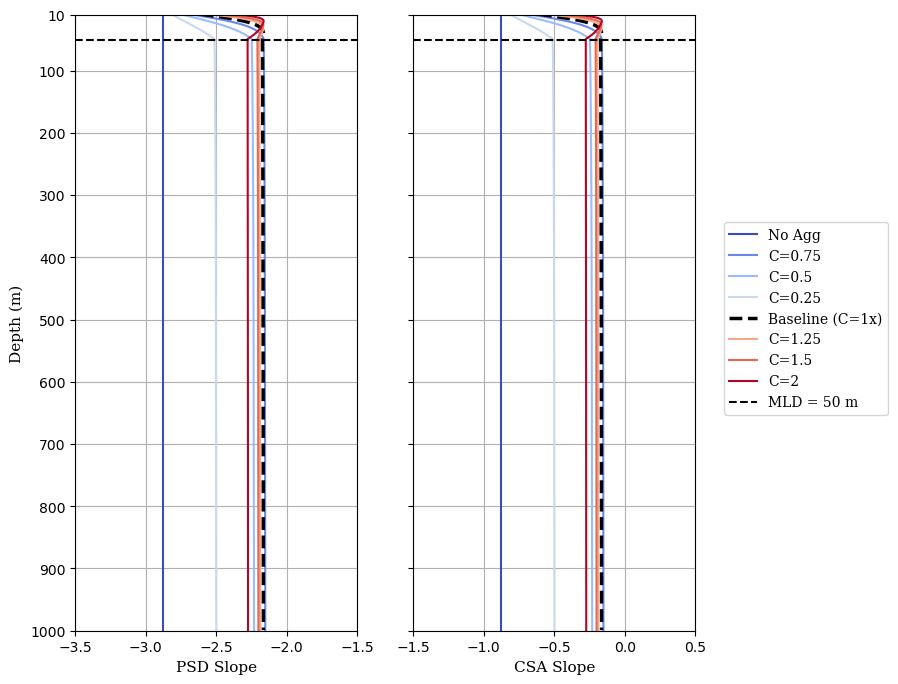

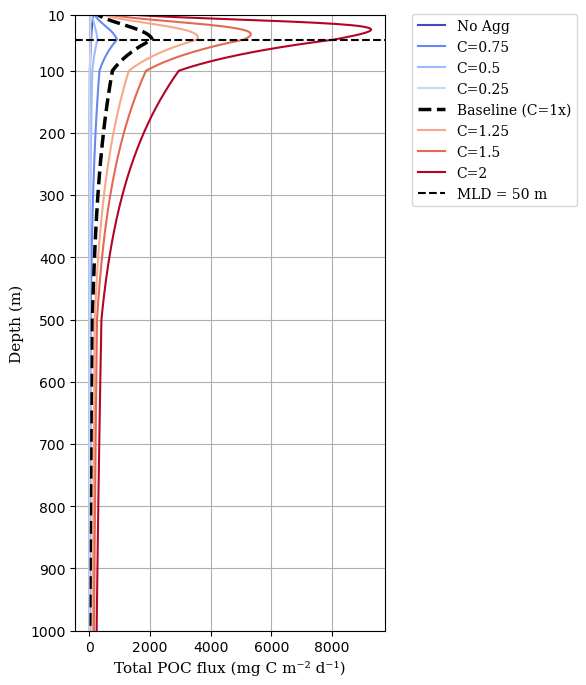

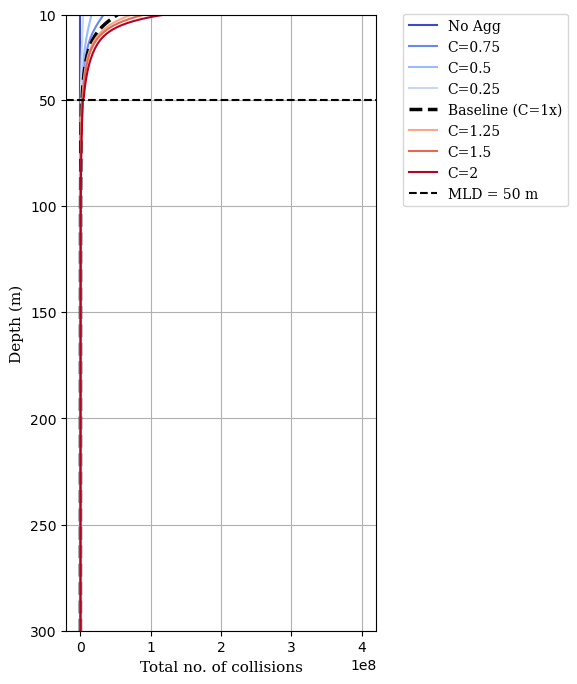

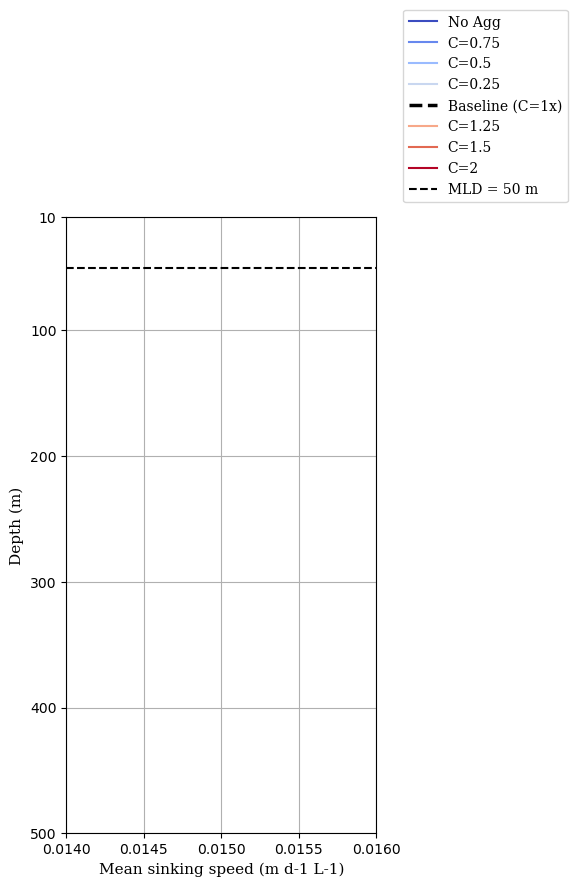

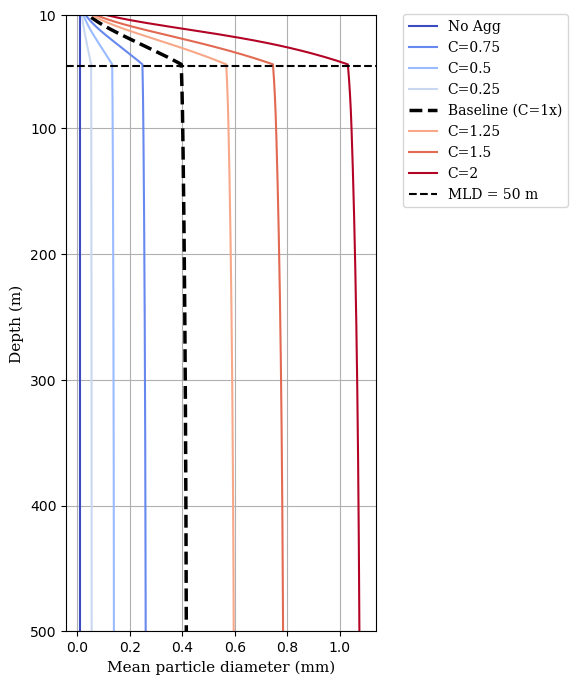

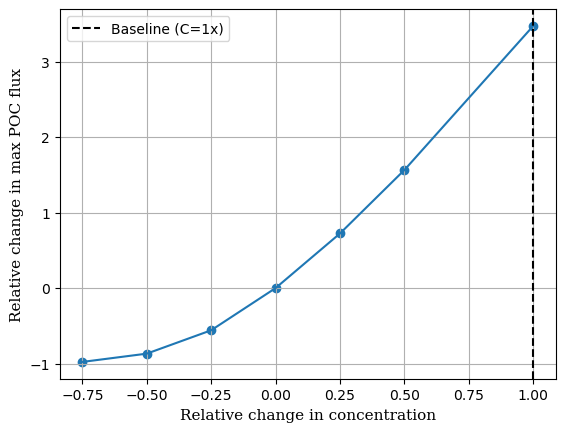

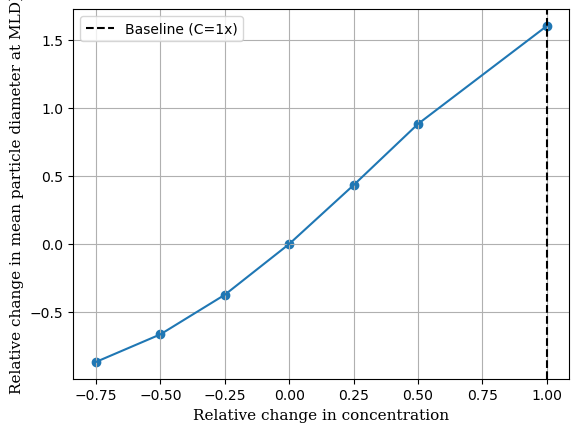

(7,) (7,)


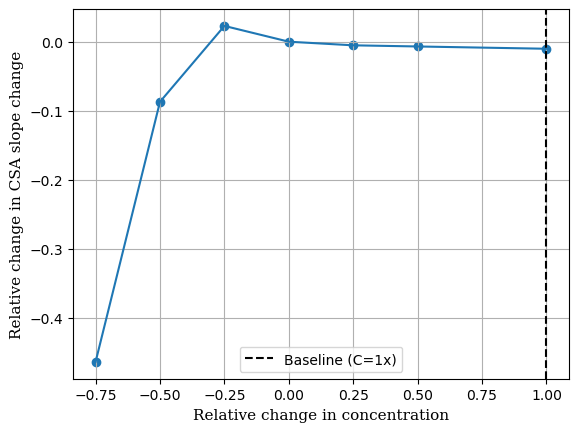

In [96]:
# SENSITIVITY ANALYSIS FOR CONCENTRATION RUNS
#Early bloom
'''
def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# STICKINESS # change this for each parameter

pre_bloom_conc_runs = {
    "No Agg": "F490_P3_no_agg",
    "C=0.75": "F490_P3_C_075",
    "C=0.5": "F490_P3_C_05",
    "C=0.25": "F490_P3_C_025",
    "C=1": "F490_P3_C_1",     # baseline
    "C=1.25": "F490_P3_C_125",
    "C=1.5": "F490_P3_C_15",
    "C=2": "F490_P3_C_2"}

pre_bloom_conc_results = {label: load_run(filename)
                         for label, filename in pre_bloom_conc_runs.items()}

#print(pre_bloom_agg_results["a=0.25"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_conc_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_conc_results["C=1"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d⁻1)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xlim(0.014, 0.016)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xlim(0.014, 0.015)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_conc = 300000 
baseline_poc = np.max(pre_bloom_conc_results["C=1"]["poc_flux"]) 

delta_pre_bloom_conc = []
delta_poc_conc = []

for label, run in pre_bloom_conc_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_conc.append(parameter-1)
    #delta_pre_bloom_stickiness.append((parameter - baseline_stickiness) / baseline_stickiness)

    delta_poc_conc.append((max_poc - baseline_poc) / baseline_poc)

# Sort by stickiness value for plotting
order = np.argsort(delta_pre_bloom_conc)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_poc_conc = np.array(delta_poc_conc)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_conc, delta_poc_conc)
ax.plot(delta_pre_bloom_conc, delta_poc_conc)
ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_diameter = (pre_bloom_conc_results["C=1"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_conc = []
delta_diameter_conc = []

for label, run in pre_bloom_conc_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    stickiness = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_conc.append(stickiness-1)
    #delta_pre_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)
    delta_diameter_conc.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_stickiness)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_diameter_conc = np.array(delta_diameter_conc)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_conc, delta_diameter_conc)
ax.plot(delta_pre_bloom_conc, delta_diameter_conc)

ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")

ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD ({MLD:.0f} m)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 

print(type(pre_bloom_conc_results["C=1"]["csa_slope"]))
print(np.asarray(pre_bloom_conc_results["C=1"]["csa_slope"]).shape)



baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_conc_results["C=1"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_conc = []
delta_csa_change_conc = []

for label, run in pre_bloom_conc_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    stickiness = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_conc.append(stickiness-1)

    delta_csa_change_conc.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by stickiness value for plotting 
order = np.argsort(delta_pre_bloom_conc)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_csa_change_conc = np.array(delta_csa_change_conc)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_conc), np.shape(delta_csa_change_conc))

ax.scatter(delta_pre_bloom_conc, delta_csa_change_conc)
ax.plot(delta_pre_bloom_conc, delta_csa_change_conc)
ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()

'''


#Mid bloom     # BE AWARE THAT THE VARIABLE NAMES ARE NOT CHANGED HERE, SO COMMENT OUT
               # WHICH RUN YOU'RE NOT GOING TO DO

# SENSITIVITY ANALYSIS FOR MID-BLOOM CONCENTRATION RUNS

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]

    return state_variables


# STICKINESS # change this for each parameter

pre_bloom_conc_runs = {
    "No Agg": "F490_P16_no_agg",
    "C=0.75": "F490_P16_C_075",
    "C=0.5": "F490_P16_C_05",
    "C=0.25": "F490_P16_C_025",
    "C=1": "F490_P16_C_1",     # baseline
    "C=1.25": "F490_P16_C_125",
    "C=1.5": "F490_P16_C_15",
    "C=2": "F490_P16_C_2"}

pre_bloom_conc_results = {label: load_run(filename)
                         for label, filename in pre_bloom_conc_runs.items()}

#print(pre_bloom_agg_results["a=0.25"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(pre_bloom_conc_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, pre_bloom_conc_results["C=1"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d⁻1)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-3.5, -1.5)
ax[1].set_xlim(-1.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 300)
ax.set_yticks([10, 50, 100, 150, 200, 250, 300])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xlim(0.014, 0.016)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_conc_results.items()):

    lw = 1.5
    ls = "-"

    if label == "C=1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (C=1x)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
#ax.set_xlim(0.014, 0.015)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
#baseline_ = 300000 
baseline_poc = np.max(pre_bloom_conc_results["C=1"]["poc_flux"]) 

delta_pre_bloom_conc = []
delta_poc_conc = []

for label, run in pre_bloom_conc_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_pre_bloom_conc.append(parameter-1)
    #delta_pre_bloom_stickiness.append((parameter - baseline_stickiness) / baseline_stickiness)

    delta_poc_conc.append((max_poc - baseline_poc) / baseline_poc)

# Sort by stickiness value for plotting
order = np.argsort(delta_pre_bloom_conc)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_poc_conc = np.array(delta_poc_conc)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_pre_bloom_conc, delta_poc_conc)
ax.plot(delta_pre_bloom_conc, delta_poc_conc)
ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_diameter = (pre_bloom_conc_results["C=1"]["mean_diameter"].iloc[mld_idx])

delta_pre_bloom_conc = []
delta_diameter_conc = []

for label, run in pre_bloom_conc_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    stickiness = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_pre_bloom_conc.append(stickiness-1)
    #delta_pre_bloom_stickiness.append((stickiness - baseline_stickiness) / baseline_stickiness)
    delta_diameter_conc.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_stickiness)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_diameter_conc = np.array(delta_diameter_conc)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_pre_bloom_conc, delta_diameter_conc)
ax.plot(delta_pre_bloom_conc, delta_diameter_conc)

ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")

ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 



baseline_csa_change = np.ptp(
    np.asarray(pre_bloom_conc_results["C=1"]["csa_slope"]))
 # change this when needed

delta_pre_bloom_conc = []
delta_csa_change_conc = []

for label, run in pre_bloom_conc_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    stickiness = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_pre_bloom_conc.append(stickiness-1)

    delta_csa_change_conc.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by stickiness value for plotting 
order = np.argsort(delta_pre_bloom_conc)

delta_pre_bloom_conc = np.array(delta_pre_bloom_conc)[order]
delta_csa_change_conc = np.array(delta_csa_change_conc)[order]

# Plot
fig, ax = plt.subplots()
print(np.shape(delta_pre_bloom_conc), np.shape(delta_csa_change_conc))

ax.scatter(delta_pre_bloom_conc, delta_csa_change_conc)
ax.plot(delta_pre_bloom_conc, delta_csa_change_conc)
ax.axvline(x=1,color="black",linestyle="--",label="Baseline (C=1x)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in concentration",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


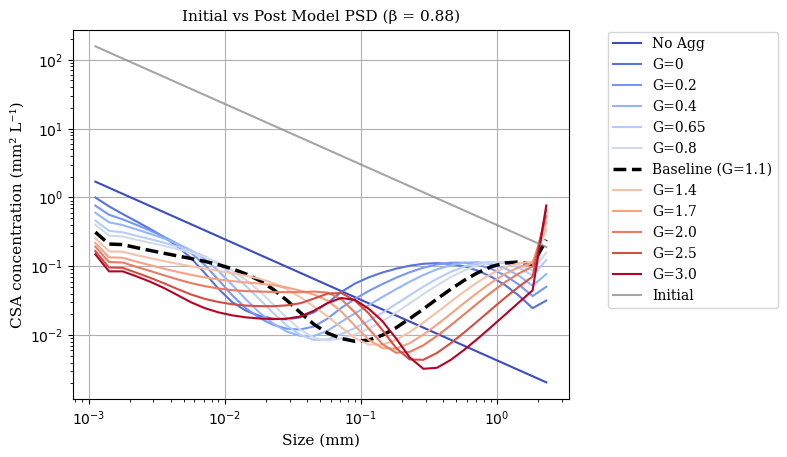

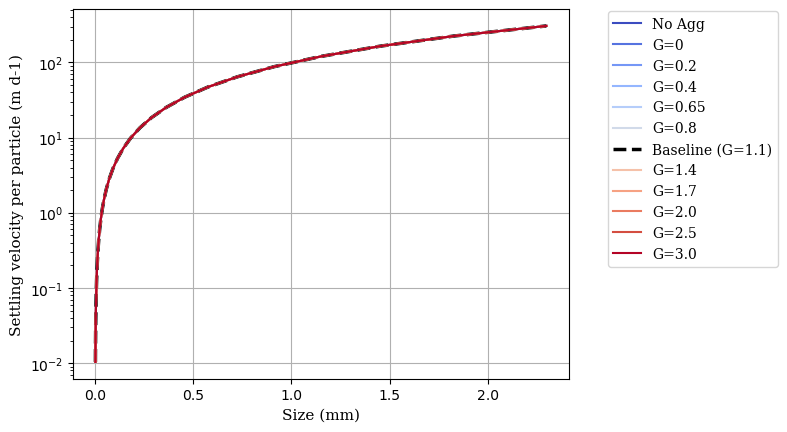

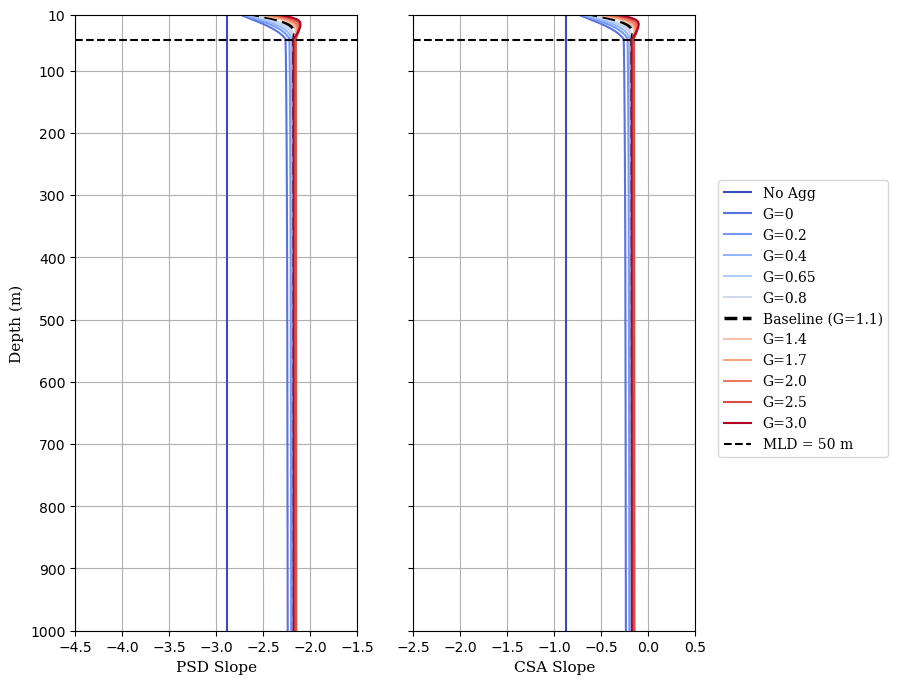

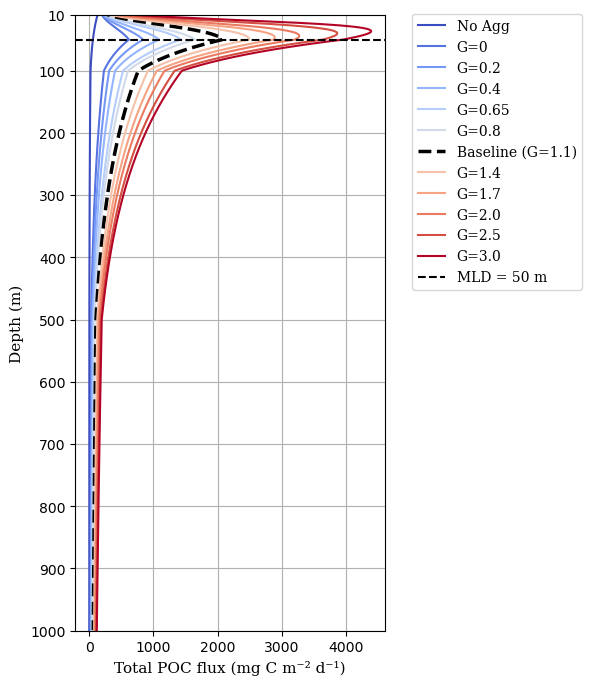

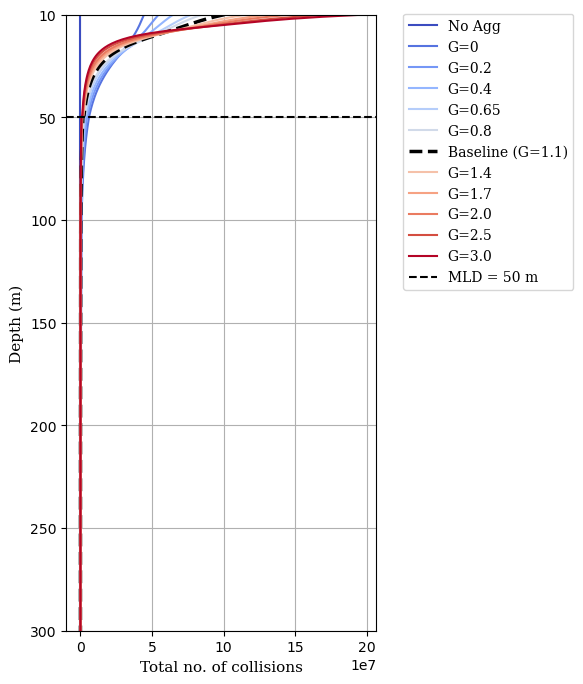

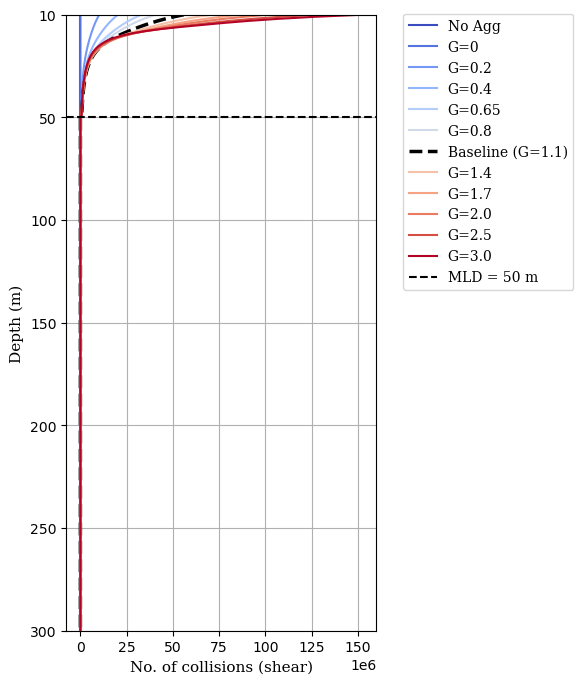

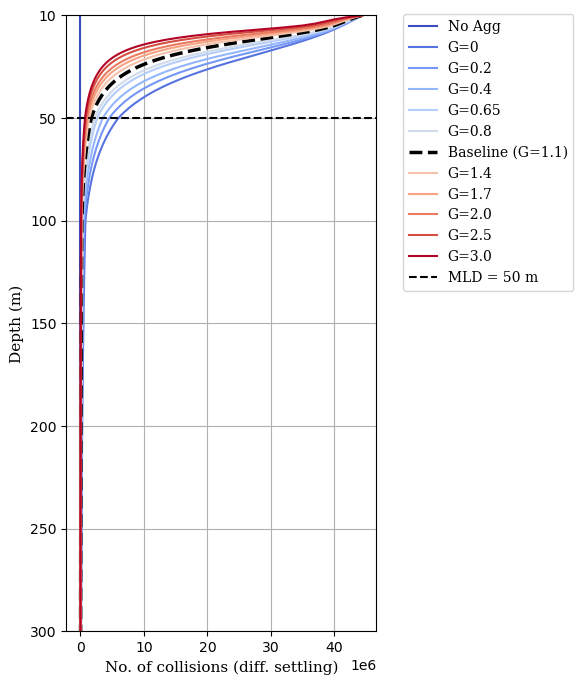

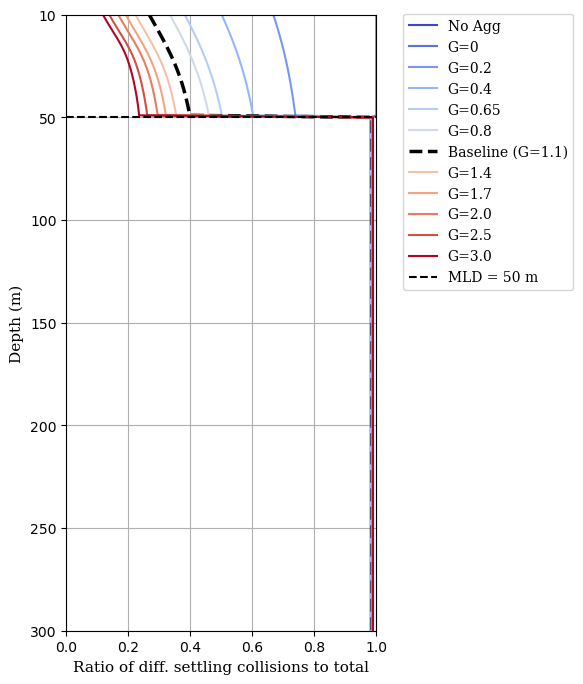

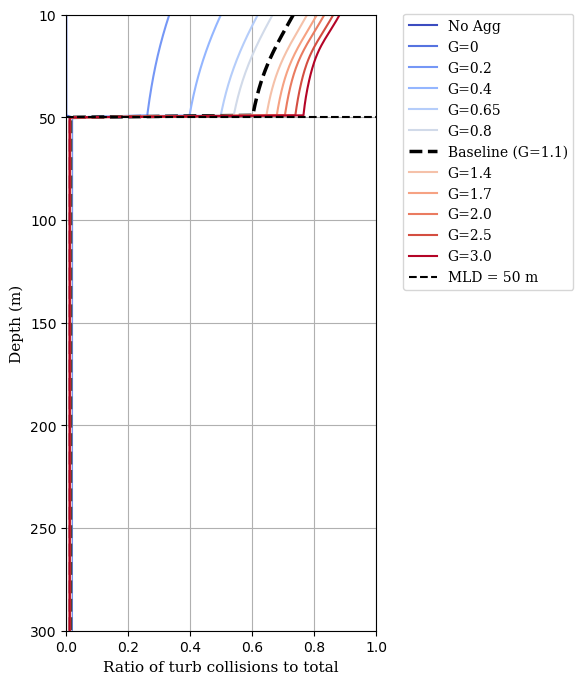

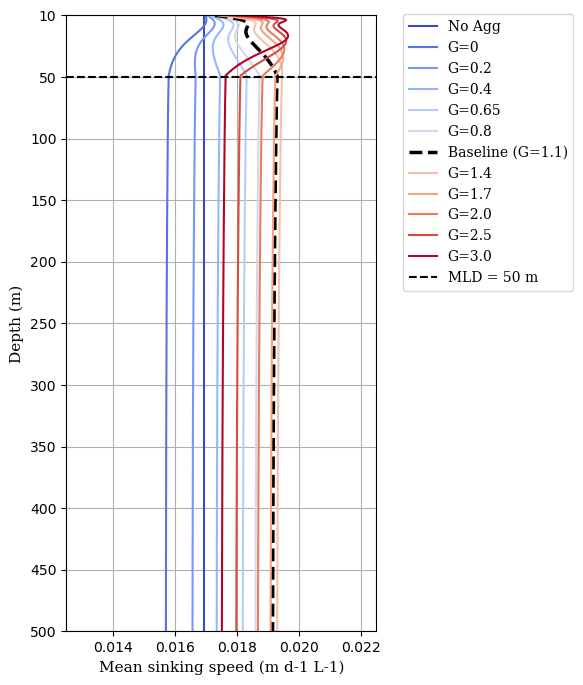

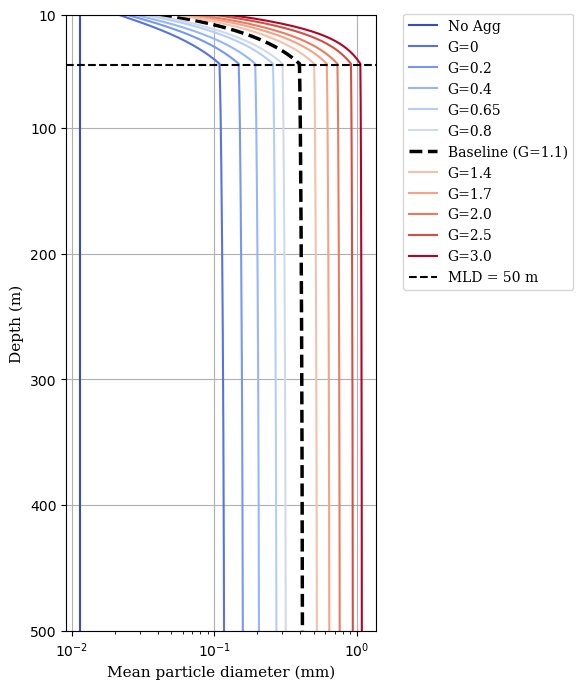

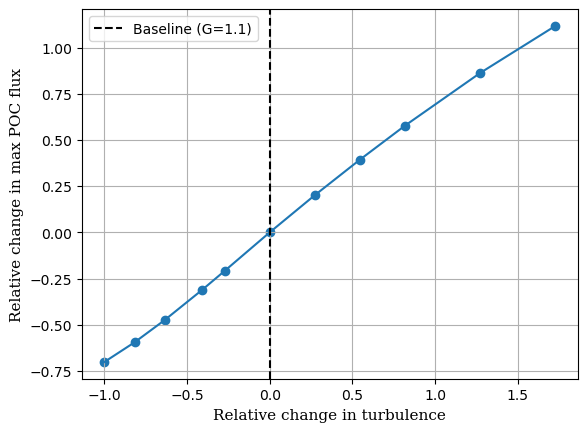

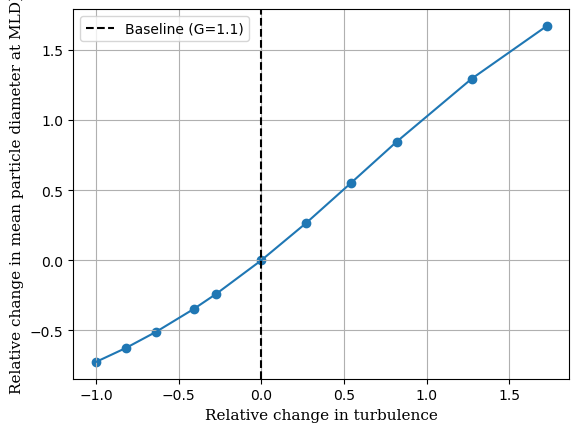

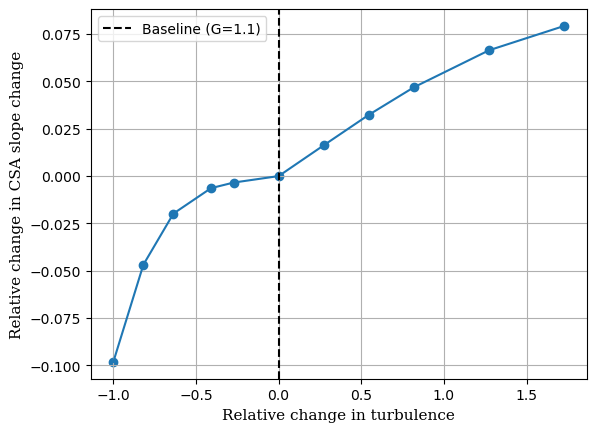

In [97]:
# SENSITIVITY ANALYSIS FOR MID-BLOOM TURBULENCE    # need to change variable names

def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "mass": pd.read_excel(file, sheet_name="Mass"),
        "csa_profile": pd.read_excel(file, sheet_name="CSA"),
        "psd_profile": pd.read_excel(file, sheet_name="PSD Slope"),
        "csa_slope": pd.read_excel(file, sheet_name="CSA PSD Slope"),
        "poc_flux": pd.read_excel(file, sheet_name="POC Flux"),
        "initial_csa": pd.read_excel(file, sheet_name="Initial CSA"),
        "final_csa": pd.read_excel(file, sheet_name="Start and End CSA"),
        "turb_aggs": pd.read_excel(file, sheet_name="Turb Aggs Profile"),
        "diff_aggs": pd.read_excel(file, sheet_name="Diff Aggs Profile"),
        "mean_diameter": pd.read_excel(file, sheet_name="Mean Diameter"),
        "sink_velocity": pd.read_excel(file, sheet_name="Sink Velocities"),
        "sink_velocity_profile": pd.read_excel(file, sheet_name="Mean Sink Velocities"),
    }

    state_variables["aggs"] = state_variables["turb_aggs"] + state_variables["diff_aggs"]
    state_variables["diff_ratio"] = state_variables["diff_aggs"] / state_variables["aggs"]
    state_variables["turb_ratio"] = state_variables["turb_aggs"] / state_variables["aggs"]

    return state_variables


# DF RUNS # change this for each parameter

mid_bloom_turb_runs = {
    "No Agg": "F490_P16_no_agg",
    "G=0": "F490_P16_G_0",
    "G=0.2": "F490_P16_G_0.2",
    "G=0.4": "F490_P16_G_0.4",
    "G=0.65": "F490_P16_G_0.65",     # baseline
    "G=0.8": "F490_P16_G_0.8",
    "G=1.1": "F490_P16_G_1.1",
    "G=1.4": "F490_P16_G_1.4",
    "G=1.7": "F490_P16_G_1.7",
    "G=2.0": "F490_P16_G_2.0",
    "G=2.5": "F490_P16_G_2.5",
    "G=3.0": "F490_P16_G_3.0",
}


mid_bloom_turb_results = {label: load_run(filename)
                         for label, filename in mid_bloom_turb_runs.items()}

#print(pre_bloom_df_results["df=1.95"]["poc_flux"])


#---------------------------------------------
## PLOTTING
#---------------------------------------------
colors = plt.cm.coolwarm(np.linspace(0, 1, len(mid_bloom_turb_results)))

### CSA PARTICLE SIZE DISTRIBUTION

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.loglog(size_bins_mm, run["final_csa"] / 1000, color=color, linewidth=lw, linestyle=ls, label=label)

ax.loglog(size_bins_mm, mid_bloom_turb_results["G=1.1"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()


### SINKING SPEED PER SIZE BIN

fig, ax = plt.subplots()

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(size_bins_mm, run["sink_velocity"], color=color, linewidth=lw, linestyle=ls, label=label)

#ax.loglog(size_bins, pre_bloom_agg_results["a=0.00"]["initial_csa"] / 1000, color="grey", alpha=0.7, label="Initial")
ax.set_xlabel("Size (mm)", fontdict=font)
ax.set_ylabel("Settling velocity per particle (m d-1)", fontdict=font)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.grid()
plt.show()



### CSA SLOPE AND PSD SLOPE DEPTH PROFILE

fig, ax = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax[0].plot(run["psd_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)
    ax[1].plot(run["csa_slope"], depths, color=color, linewidth=lw, linestyle=ls, label=label)


for a in ax:
    a.axhline(y=MLD,color="black",linestyle="--",label=f"MLD = {MLD} m")
    a.set_ylim(10, 1000)
    a.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    a.invert_yaxis()
    a.grid()

ax[0].set_xlim(-4.5, -1.5)
ax[1].set_xlim(-2.5, 0.5)
ax[0].set_xlabel("PSD Slope", fontdict=font)   # check units
ax[1].set_xlabel("CSA Slope", fontdict=font)
ax[0].set_ylabel("Depth (m)", fontdict=font)


# Single shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.15, 0.5), prop=legend_font)

plt.show()



### POC FLUX

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["poc_flux"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total POC flux (mg C m⁻² d⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_xscale("log")
#ax.set_xlim(10**-1, 10**7)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TOTAL NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Total no. of collisions", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.ticklabel_format(style="sci", axis="x", scilimits=(7, 7))
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### SHEAR NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"
    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["turb_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions (shear)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
#ax.set_xlim(0, 90000000)
ax.ticklabel_format(style="sci", axis="x", scilimits=(6, 6))
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.invert_yaxis()
ax.grid()
plt.show()


### DIFF SETTLING NO. OF AGGREGATIONS PLOT

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["diff_aggs"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("No. of collisions (diff. settling)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.ticklabel_format(style="sci", axis="x", scilimits=(6, 6))
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()


### DIFF SETTLING NO. OF AGGREGATIONS PLOT (RATIO)

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["diff_ratio"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Ratio of diff. settling collisions to total", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.set_xlim(0, 1.0)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### TURB NO. OF AGGREGATIONS PLOT (RATIO)

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, pre_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["turb_ratio"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Ratio of turb collisions to total", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 300)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300"])
ax.set_xlim(0, 1.0)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()




### MEAN SINKING SPEED DEPTH PROFILE

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["sink_velocity_profile"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean sinking speed (m d-1 L-1)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(0, 500)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
ax.set_yticklabels(["10", "50", "100", "150", "200", "250", "300", "350", "400", "450", "500"])
ax.set_xlim(0.0125, 0.0225)
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()



### CSA-WEIGHTED MEAN PARTICLE DIAMETER WITH DEPTH 

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, mid_bloom_turb_results.items()):

    lw = 1.5
    ls = "-"

    if label == "G=1.1":
        color = "black"
        lw = 2.5
        ls = "--"
        label = "Baseline (G=1.1)"

    ax.plot(run["mean_diameter"], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Mean particle diameter (mm)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 500)
ax.set_yticks([10, 100, 200, 300, 400, 500])
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()





### SENSITIVITY ANALYSIS

# MAX POC FLUX    - add another block for turb and then Df, to be able to plot the slopes together

# Baseline value
baseline_turb = 1.1
baseline_poc = np.max(mid_bloom_turb_results["G=1.1"]["poc_flux"]) 

delta_mid_bloom_turb = []
delta_poc_turb = []

for label, run in mid_bloom_turb_results.items(): 

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    parameter = float(label.split("=")[1])
    max_poc = np.max(run["poc_flux"])
    delta_mid_bloom_turb.append((parameter - baseline_turb) / baseline_turb)

    delta_poc_turb.append((max_poc - baseline_poc) / baseline_poc)

# Sort by df value for plotting
order = np.argsort(delta_mid_bloom_turb)

delta_parameter = np.array(delta_mid_bloom_turb)[order]
delta_poc_turb = np.array(delta_poc_turb)[order]

# Plot
fig, ax = plt.subplots()
ax.scatter(delta_mid_bloom_turb, delta_poc_turb)
ax.plot(delta_mid_bloom_turb, delta_poc_turb)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=1.1)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel("Relative change in max POC flux",fontdict=font)

ax.grid()
ax.legend()
plt.show()




# MEAN PARTICLE DIAMETER AT MLD

# Find the model depth closest to the MLD
mld_idx = np.argmin(np.abs(np.array(depths) - MLD))

# Baseline value
baseline_turb = 1.1
baseline_diameter = (mid_bloom_turb_results["G=1.1"]["mean_diameter"].iloc[mld_idx])

delta_mid_bloom_turb = []
delta_diameter_turb = []

for label, run in mid_bloom_turb_results.items():

    # Skip No Agg run if present
    if label == "No Agg":
        continue
    df = float(label.split("=")[1])
    diameter_at_mld = run["mean_diameter"].iloc[mld_idx]
    delta_mid_bloom_turb.append((df - baseline_turb) / baseline_turb)
    delta_diameter_turb.append((diameter_at_mld - baseline_diameter) / baseline_diameter)

# Sort for plotting
#order = np.argsort(delta_pre_bloom_df)

delta_mid_bloom_turb = np.array(delta_mid_bloom_turb)[order]
delta_diameter_turb = np.array(delta_diameter_turb)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_mid_bloom_turb, delta_diameter_turb)
ax.plot(delta_mid_bloom_turb, delta_diameter_turb)

ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=1.1)")

ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel(f"Relative change in mean particle diameter at MLD)",fontdict=font)

ax.grid()
ax.legend()
plt.show()





# CSA SLOPE CHANGE

# Baseline value 
baseline_turb = 1.1 # change this when needed

'''
print(type(pre_bloom_turb_results["df=2.1"]["csa_slope"]))
print(np.asarray(pre_bloom_turb_results["df=2.1"]["csa_slope"]).shape)
'''

baseline_csa_change = np.ptp(
    np.asarray(mid_bloom_turb_results["G=1.1"]["csa_slope"]))
 # change this when needed

delta_mid_bloom_turb = []
delta_csa_change_turb = []

for label, run in mid_bloom_turb_results.items(): # change this when needed

    # Skip No Agg run if present
    if label == "No Agg":
        continue

    df = float(label.split("=")[1])
    # range = max - min for this run

    csa_change = np.ptp(np.asarray(run["csa_slope"]))
    delta_mid_bloom_turb.append((df - baseline_turb) / baseline_turb)

    delta_csa_change_turb.append((csa_change - baseline_csa_change) / baseline_csa_change)

# Sort by df value for plotting 
order = np.argsort(delta_mid_bloom_turb)

delta_mid_bloom_turb = np.array(delta_mid_bloom_turb)[order]
delta_csa_change_turb = np.array(delta_csa_change_turb)[order]

# Plot
fig, ax = plt.subplots()

ax.scatter(delta_mid_bloom_turb, delta_csa_change_turb)
ax.plot(delta_mid_bloom_turb, delta_csa_change_turb)
ax.axvline(x=0,color="black",linestyle="--",label="Baseline (G=1.1)")
#ax.axhline(y=0,color="grey",linestyle=":")
ax.set_xlabel("Relative change in turbulence",fontdict=font)
ax.set_ylabel("Relative change in CSA slope change",fontdict=font)

ax.grid()
ax.legend()
plt.show()


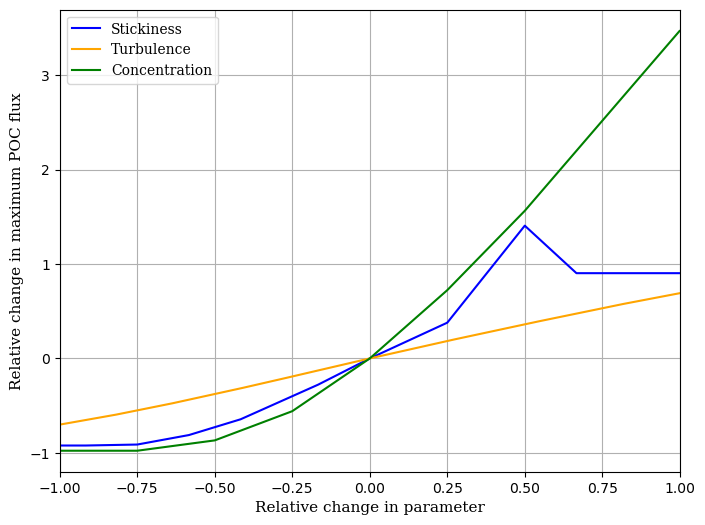

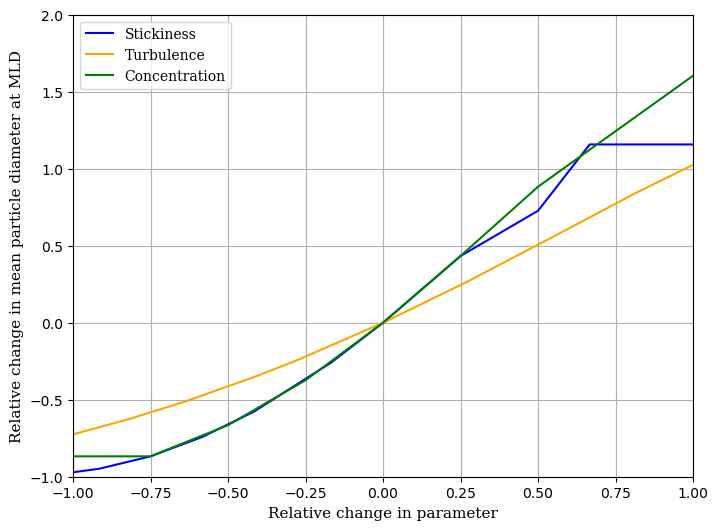

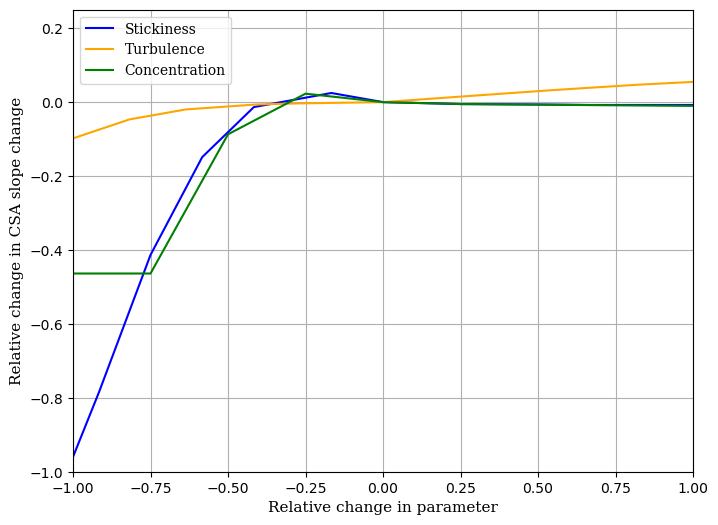

In [99]:
# COMBINED SENSITIVITY ANALYSES

# Pre bloom
'''
# POC flux
x_common = np.unique(np.concatenate([
    #delta_pre_bloom_df,
    delta_pre_bloom_stickiness,
    delta_pre_bloom_turb,
    delta_pre_bloom_conc
]))

#y_df = np.interp(x_common, delta_pre_bloom_df, delta_poc_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_poc_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_poc_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_poc_conc)


fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")


#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
#ax.set_ylim(0, 10**6)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in maximum POC flux", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()




# Mean Particle Diameter at MLD

x_common = np.unique(np.concatenate([
    #delta_pre_bloom_df,
    delta_pre_bloom_stickiness,
    delta_pre_bloom_turb,
    delta_pre_bloom_conc
]))

#delta_diameter_df = np.ravel(delta_diameter_df)
delta_diameter_stick = np.ravel(delta_diameter_stick)
delta_diameter_turb = np.ravel(delta_diameter_turb)
delta_diameter_conc = np.ravel(delta_diameter_conc)

#y_df = np.interp(x_common, delta_pre_bloom_df, delta_diameter_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_diameter_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_diameter_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_diameter_conc)


fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension", color="purple")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")

#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
ax.set_ylim(-1, 4)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in mean particle diameter at MLD", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()






# CSA slope change

x_common = np.unique(np.concatenate([
    #delta_pre_bloom_df,
    delta_pre_bloom_stickiness,
    delta_pre_bloom_turb,
    delta_pre_bloom_conc
]))

#y_df = np.interp(x_common, delta_pre_bloom_df, delta_csa_change_df)
y_stick = np.interp(x_common, delta_pre_bloom_stickiness, delta_csa_change_stick)
y_turb = np.interp(x_common, delta_pre_bloom_turb, delta_csa_change_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_csa_change_conc)


fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension", color="purple")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")

#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
ax.set_ylim(-1, 2)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in CSA slope change", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()

'''




# Mid bloom

# POC flux
x_common = np.unique(np.concatenate([
    #delta_mid_bloom_df,
    delta_mid_bloom_stickiness,
    delta_mid_bloom_turb,
    delta_pre_bloom_conc
]))

#y_df = np.interp(x_common, delta_mid_bloom_df, delta_poc_df)
y_stick = np.interp(x_common, delta_mid_bloom_stickiness, delta_poc_stick)
y_turb = np.interp(x_common, delta_mid_bloom_turb, delta_poc_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_poc_conc)


fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")


#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
#ax.set_ylim(0, 10**6)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in maximum POC flux", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()



# Mean Particle Diameter at MLD

x_common = np.unique(np.concatenate([
    #delta_mid_bloom_df,
    delta_mid_bloom_stickiness,
    delta_mid_bloom_turb,
    delta_pre_bloom_conc
]))

#delta_diameter_df = np.ravel(delta_diameter_df)
delta_diameter_stick = np.ravel(delta_diameter_stick)
delta_diameter_turb = np.ravel(delta_diameter_turb)
delta_diameter_conc = np.ravel(delta_diameter_conc)

#y_df = np.interp(x_common, delta_mid_bloom_df, delta_diameter_df)
y_stick = np.interp(x_common, delta_mid_bloom_stickiness, delta_diameter_stick)
y_turb = np.interp(x_common, delta_mid_bloom_turb, delta_diameter_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_diameter_conc)


fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension", color="purple")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")

#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
ax.set_ylim(-1, 2)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in mean particle diameter at MLD", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()



# CSA slope change

x_common = np.unique(np.concatenate([
    #delta_mid_bloom_df,
    delta_mid_bloom_stickiness,
    delta_mid_bloom_turb,
    delta_pre_bloom_conc
]))

#y_df = np.interp(x_common, delta_mid_bloom_df, delta_csa_change_df)
y_stick = np.interp(x_common, delta_mid_bloom_stickiness, delta_csa_change_stick)
y_turb = np.interp(x_common, delta_mid_bloom_turb, delta_csa_change_turb)
y_conc = np.interp(x_common, delta_pre_bloom_conc, delta_csa_change_conc)

fig, ax = plt.subplots(figsize=(8, 6))

#ax.plot(x_common, y_df, label="Fractal Dimension", color="purple")
ax.plot(x_common, y_stick, label="Stickiness", color="blue")
ax.plot(x_common, y_turb, label="Turbulence", color="orange")
ax.plot(x_common, y_conc, label="Concentration", color="green")


#ax.scatter(x_common, y_df)
#ax.scatter(x_common, y_stick)
#ax.scatter(x_common, y_turb)
#ax.scatter(x_common, y_conc)


#ax.set_title("Sensitivity of POC flux to drivers", fontdict=font)
#ax.set_yscale("log")
ax.set_ylim(-1, 0.25)
ax.set_xlim(-1, 1)
ax.set_xlabel("Relative change in parameter", fontdict=font)
ax.set_ylabel("Relative change in CSA slope change", fontdict=font)
ax.legend(prop=legend_font)
ax.grid()
plt.show()





In [ ]:
# SENSITIVITY ANALYSIS FOR PRIMARY PARTICLE RUNS

In [ ]:
# Sinking speed hypothesis

# 

46
[1.00000000e+00 1.25992105e+00 1.58740105e+00 2.00000000e+00
 2.51984210e+00 3.17480210e+00 4.00000000e+00 5.03968420e+00
 6.34960421e+00 8.00000000e+00 1.00793684e+01 1.26992084e+01
 1.60000000e+01 2.01587368e+01 2.53984168e+01 3.20000000e+01
 4.03174736e+01 5.07968337e+01 6.40000000e+01 8.06349472e+01
 1.01593667e+02 1.28000000e+02 1.61269894e+02 2.03187335e+02
 2.56000000e+02 3.22539789e+02 4.06374669e+02 5.12000000e+02
 6.45079578e+02 8.12749339e+02 1.02400000e+03 1.29015916e+03
 1.62549868e+03 2.04800000e+03 2.58031831e+03 3.25099735e+03
 4.09600000e+03 5.16063662e+03 6.50199471e+03 8.19200000e+03
 1.03212732e+04 1.30039894e+04 1.63840000e+04 2.06425465e+04
 2.60079788e+04 3.27680000e+04 4.12850930e+04]


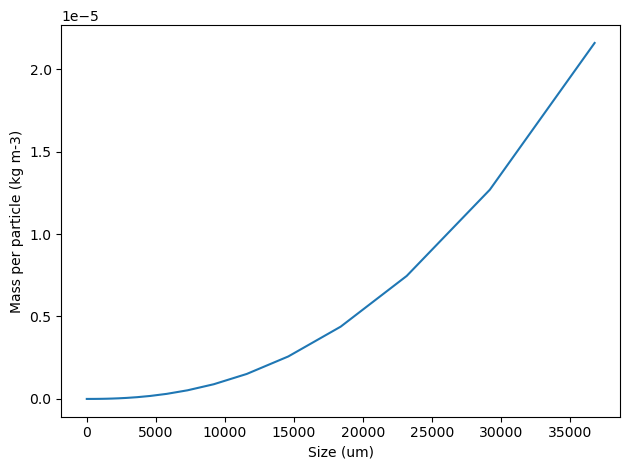

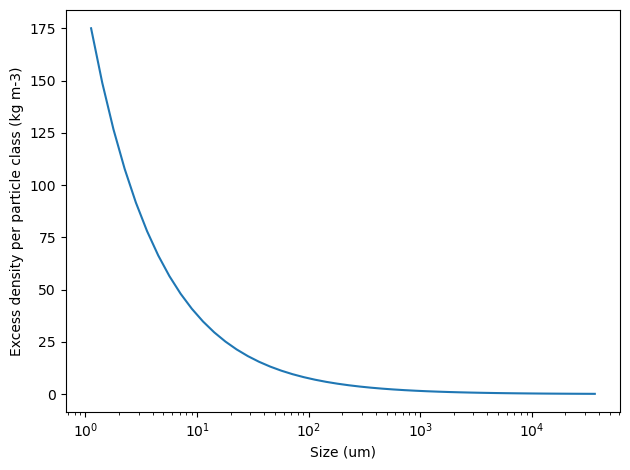

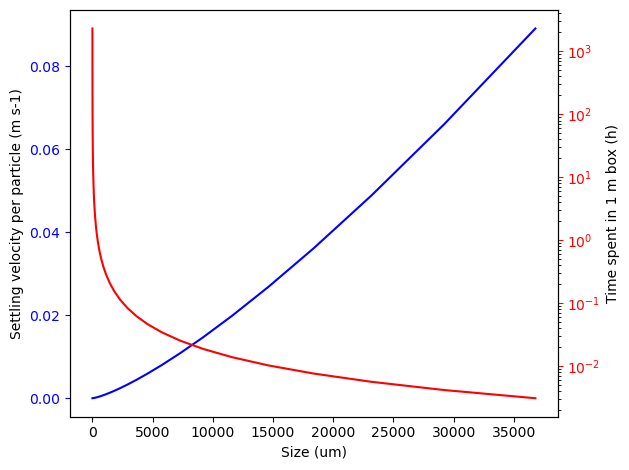

step=0, mass=1.5547e+00, N=6.8900e+14
step=100, mass=1.1444e+02, N=2.3903e+13
step=200, mass=1.1444e+02, N=1.3833e+13
step=300, mass=1.1444e+02, N=9.7572e+12
step=400, mass=1.1444e+02, N=7.6260e+12
step=500, mass=1.1444e+02, N=6.3046e+12
step=600, mass=1.1444e+02, N=5.4025e+12
step=700, mass=1.1444e+02, N=4.7453e+12
step=800, mass=1.1444e+02, N=4.2491e+12
step=900, mass=1.1444e+02, N=3.8522e+12


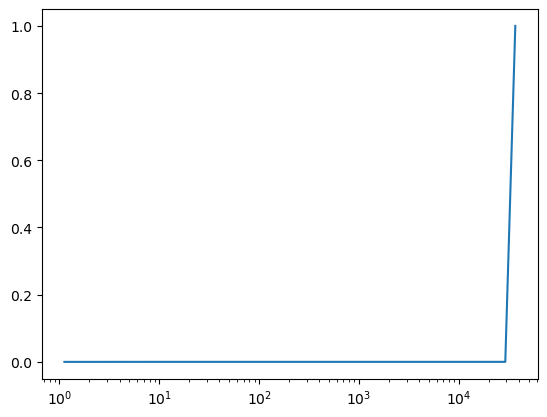

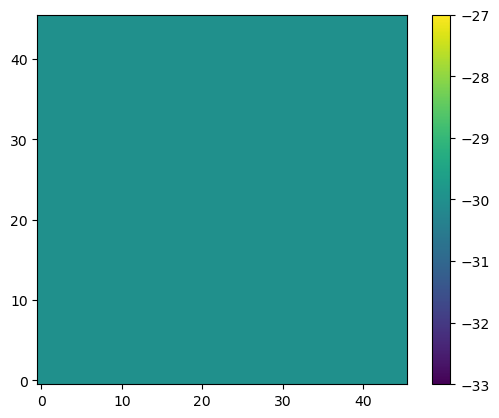

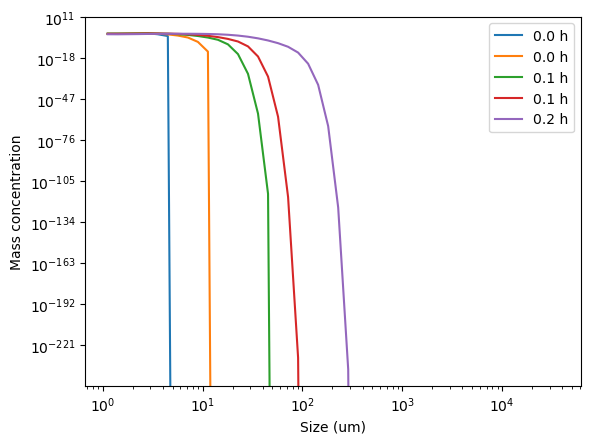

[1.76770592e-003 9.43616686e-004 1.05302117e-003 9.71161288e-004
 9.29331231e-004 8.95078007e-004 8.70690837e-004 8.55029016e-004
 8.45838525e-004 8.36545089e-004 8.12130140e-004 7.39083639e-004
 5.41318110e-004 4.35468152e-005 2.64983055e-007 1.80633687e-009
 1.13491004e-011 7.68232813e-014 5.65227046e-016 4.38472712e-018
 3.55013506e-020 2.96736982e-022 2.46825917e-024 1.97391927e-026
 1.43798620e-028 8.48590320e-031 3.75689165e-033 1.01589320e-035
 1.74268039e-038 2.02951292e-041 1.78532459e-044 9.43826250e-048
 2.91708282e-051 5.35914358e-055 5.92966324e-059 4.05659144e-063
 1.80365533e-067 5.67899597e-072 1.25273484e-076 1.62997007e-081
 1.25726984e-086 5.80985826e-092 1.64314332e-097 2.96528489e-103
 3.67989305e-109 1.14432186e+002]


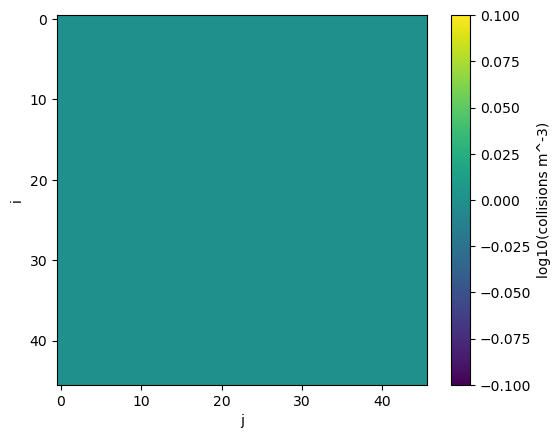

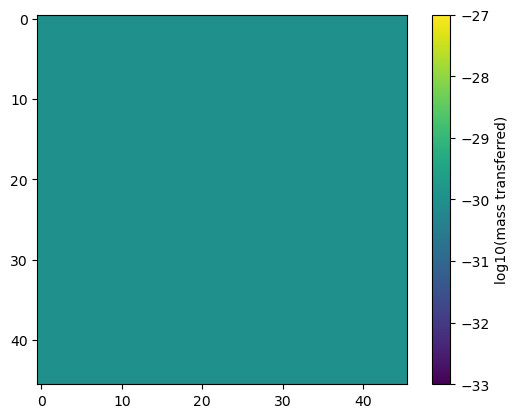

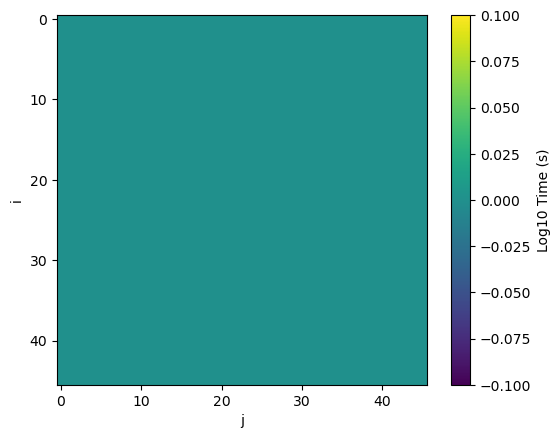

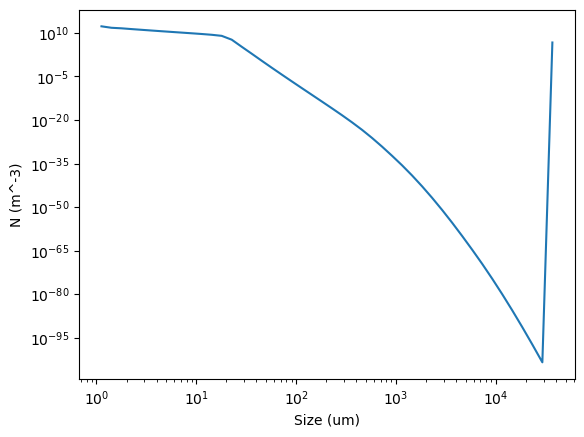

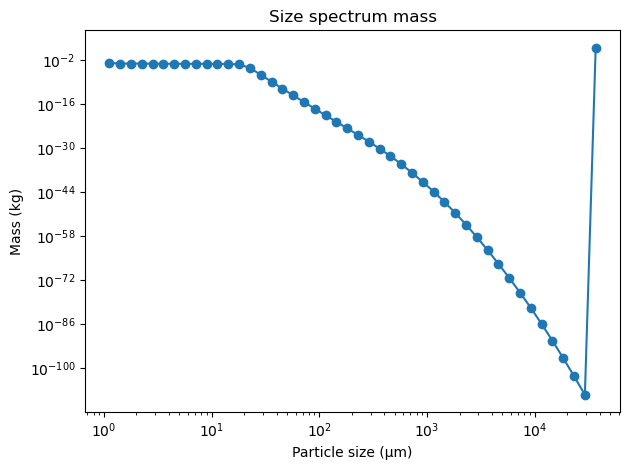

'\n\n# CSA CUMULATIVE PLOT\n\nfig, ax = plt.subplots(figsize=(6,8))\n\ncumulative = np.cumsum(CSA_profile.T, axis=0)\n\ncmap = plt.cm.jet\ncolors = cmap(np.linspace(0, 1, n_bins))\n\nfor i in range(n_bins):\n\n    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=2)\n\nax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")\n\n#ax.set_xscale("log")\nax.invert_yaxis()\n\nax.set_xlabel("Cumulative CSA concentration (mm² m-3)")\nax.set_ylabel("Depth (m)")\nnorm = plt.Normalize(\n    vmin=min(size_bins/1000),\n    vmax=max(size_bins/1000)\n)\nax.set_title(f"Model cumulative particle CSA profiles")\nax.legend(loc="lower right", fontsize=12)\nax.set_ylim(0, 1000)\n\nsm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)\n\nplt.colorbar(sm, ax=ax, label="Particle size (mm)")\nax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=12,\n        bbox=dict(boxstyle=\'round, pad=0.3\', facecolor="white", edgecolor="grey", alpha=0.4, linewidt

In [ ]:
# PRIMARY PARTICLES ONLY

# ------------------------------
# SIZE BINS
# ------------------------------

size_bounds = 2 ** np.arange(0, 15 + 1/3, 1/3) #um     # OG 4       # 1 um to 2050 um (17 bins)
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:]) # um        # calculates mid-size diameter of each bin as geometric mean (due to log spacing)
n_bins = len(size_bins)                                             # specifying the number of size bins
print(n_bins)
print(size_bounds)


radius = size_bins / 2.0 #um                                       # calculates radius from diameter (um)
radius_m = radius / 1e6  #m                                        # converts radius into metres
radius_mm = radius / 1000  #mm                                     # converts radius into mm

area_per_particle = np.pi * radius_mm**2  # mm2                    # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin


# ------------------------------
# PARAMETERS
# ------------------------------
Df = 2.3                                                         # Fractal Dimension
rho_f = 1025                         # kg m-3                       # Seawater Density (kg m-3)
rho0 = 1200 #(Li et al, 2004)        # kg m-3                       # Primary Particle Density (kg m-3)
mu = 1e-3                            # Pa s                           # Viscosity of seawater
g = 9.81                             # m s-2                        # Acceleration due to gravity
surface_a = 0.5                                                     # Stickiness (probability of successful collisions) at the surface
deep_a = 0.01                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1                    # s-1   (Maerz et al 2020)     # Turbulent Shear at the surface
deep_G = 0.01                        # s-1   (Maerz et al 2020)     # Turbulent Shear at depth
MLD = 50                             # m                            # Mixed Layer Depth


# ------------------------------
# INITIAL CSA DISTRIBUTION
# ------------------------------

# Use a CSA spectrum more consistent with UVP data (uses a shallower slope)

CSA0 = 3e12 #(mm2 m-3)                                                # total surface starting particle cross-sectional area concentration

CSA = np.zeros_like(size_bins, dtype=float)

CSA[0] = CSA0  # maybe assign to all three

'''
CSA_slope = 1   # higher = steep, more small particles, lower = gentler, more large particles           # specifies how aggressively the starting distribution varies between small and large particles

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up
'''
# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class



# Mass
r0 = radius_m[0]    #reference particle (m)
V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg
particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle (mass propor. to r^x)
M = N * particle_mass    # particles m-3 * kg = kg associated with particles per m-3 per size class

# -------------------------------------------------------------------
# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
# -------------------------------------------------------------------

def particle_density(r):
    """
    Calculates the density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]  # m                                      # reference particle = radius of smallest particle in range                                                                                         
    rho = (rho0 - rho_f) * (r / r0)**(Df - 3) # kg m-3 * (m/m)^2 = kg m-3 
    return rho
    """
    if delta_rho > rho_f:
        return (delta_rho)                                         # spits out excess density of particle
    else:
        return (rho_f)                                             # spits out excess density of particle
    """                                                                                                     
                                                                                                                                 
excess_densities = []                                                      
for r in radius_m:                                                  
    density = particle_density(r)
    excess_densities.append(density)

fig, ax = plt.subplots()
ax.plot(size_bins, particle_mass)
#ax.set_xscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(size_bins, excess_densities)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout()
plt.show()


# ------------------------------
# SETTLING
# ------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """
    rho_eff = particle_density(r) # kg m-3                                   

    return (2/9) * (rho_eff) * g * r**2 / mu # kg m-3 * m s-2 * m^2 / (Pa s) = m s-1               # The Stokes formula, incorporating excess density

sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

sink_velocities = np.array(sink_velocities)
time_at_depth = 1 / sink_velocities # m / m-s = s
time_at_depth = time_at_depth / 3600

fig, ax1 = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax2 = ax1.twinx()
ax1.plot(size_bins, sink_velocities, color="blue")                                    # Currently 
ax2.plot(size_bins, time_at_depth, color="red")
ax1.set_xlabel("Size (um)")
ax1.set_ylabel("Settling velocity per particle (m s-1)")
ax2.set_ylabel("Time spent in 1 m box (h)")
ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')
ax2.set_yscale("log")
plt.tight_layout()
plt.show() 


# ------------------------------
# SHEAR
# ------------------------------

def shear_rate(depth):

    if depth < MLD:                                                 # Pretty self-explanatory, MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
# ------------------------------
# COLLISION KERNELS
# ------------------------------

def shear_kernel(r1, r2, depth, use_shear=True):                                    # Need to update for it to be curvilinear rather than rectilinear, for better realism
    """
    Turbulent shear collision kernel.
    """
    if use_shear:
        G = shear_rate(depth)
        return 1.3 * G * (r1 + r2)**3  # s-1 * m^3 = m^3 s-1              
    else:
        return 0.0


def settling_kernel(r1, r2, use_settling=True):
    """
    Differential settling collision kernel.
    """
    if use_settling:
        w1 = settling_velocity(r1)
        w2 = settling_velocity(r2)
        return np.pi * (r1 + r2)**2 * abs(w1 - w2) # m^2 * m s-1 = m^3 s-1 (* other factors James included?)
    else:
        return 0.0


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear == True:
        beta += shear_kernel(r1, r2, depth, use_shear=use_shear)
    if use_shear == False:
        beta += 0.0

    if use_settling == True:
        beta += settling_kernel(r1, r2, use_settling=use_settling)
    if use_settling == False:
        beta += 0.0

    return beta

# ------------------------------
# DEPTH GRID
# ------------------------------
'''
dz = 1 # m                                                          # Depth step
z_max = 1000 # m                                                    # Max depth
nz = int(z_max / dz)
depth = 50
'''
# ------------------------------
# STORAGE
# ------------------------------

'''
# N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                                  # Profile of mass, appended at each depth step
Flux_profile = np.zeros((nz, n_bins))
for i in range(n_bins):
    Flux_profile[0, i] = (M[i] * settling_velocity(radius_m[i]))
CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step
'''
particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []

def number_concentration(M):
    N = np.zeros_like(M)                                             
                                                                    
    mask = particle_mass > 0                                        # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles
    N[mask] = M[mask] / particle_mass[mask]                         # Calculating no. of particles from mass for a bin / mass per particle
    return N

# --------------------------------------
# SENSITIVITY ANALYSIS - KERNEL SWITCHES
# --------------------------------------

shear = True                                                   # Set to False or True depending on the variation
settling = True
'''
shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)


collision_matrix = np.zeros((n_bins, n_bins))
mass_transfer_matrix = np.zeros((n_bins, n_bins))
time_matrix = np.zeros((n_bins, n_bins))

depth = 5
# --------------------------------
# INITIAL CONDITIONS
# --------------------------------

M = N * particle_mass      # initial mass distribution

dt = 60                    # s
n_steps = 1000             # run for ~17 hours

M_history = np.zeros((n_steps, n_bins))
N_history = np.zeros((n_steps, n_bins))

# --------------------------------
# TIME LOOP
# --------------------------------

for t in range(n_steps):

    N = number_concentration(M)

    M_new = np.zeros_like(M)

    for i in range(n_bins):

        for j in range(i, n_bins):

            if N[i] <= 0 or N[j] <= 0:
                continue

            r1 = radius_m[i]
            r2 = radius_m[j]

            beta = jackson_kernel(
                r1,
                r2,
                depth=25,
                use_shear=shear,
                use_settling=settling,
            )

            collisions = beta * N[i] * N[j] * dt

            if i == j:
                collisions *= 0.5

            agg = surface_a * collisions

            # limit removals
            if i == j:
                agg = min(agg, N[i] / 2)
            else:
                agg = min(agg, N[i], N[j])

            # parent mass removed
            mass_i = agg * particle_mass[i]
            mass_j = agg * particle_mass[j]

            total_mass = mass_i + mass_j

            M_new[i] -= mass_i
            M_new[j] -= mass_j

            # daughter aggregate
            new_particle_mass = (
                particle_mass[i]
                + particle_mass[j]
            )

            new_radius = (
                r0
                * (new_particle_mass / m0)**(1 / Df)
            )

            new_size = 2 * new_radius * 1e6

            k_upper = np.searchsorted(
                size_bins,
                new_size
            )

            if k_upper <= 0:
                M_new[0] += total_mass
                continue

            if k_upper >= n_bins:
                M_new[-1] += total_mass
                continue

            k_lower = k_upper - 1

            size_lower = size_bins[k_lower]
            size_upper = size_bins[k_upper]

            w_upper = (
                (new_size - size_lower)
                / (size_upper - size_lower)
            )

            w_lower = 1.0 - w_upper

            M_new[k_lower] += total_mass * w_lower
            M_new[k_upper] += total_mass * w_upper

    # update spectrum
    M += M_new

    # prevent tiny negative values from roundoff
    M[M < 0] = 0

    # save history
    M_history[t, :] = M
    N_history[t, :] = number_concentration(M)

    # diagnostics
    if t % 100 == 0:
        print(
            f"step={t}, "
            f"mass={np.sum(M):.4e}, "
            f"N={np.sum(number_concentration(M)):.4e}"
        )
 
'''
# send downward
if z_step < nz - 1:

    Flux_profile[z_step + 1, :] += F_new
    
'''    
cum_mass = np.cumsum(M)
plt.semilogx(size_bins, cum_mass / np.sum(M))
plt.show()

plt.imshow(
    np.log10(mass_transfer_matrix + 1e-30),
    origin="lower"
)
plt.colorbar()

N = number_concentration(M)
CSA = N * area_per_particle
CSA_profile = CSA




times_to_plot = [0, 10, 100, 500, 999]

fig, ax = plt.subplots()

for t in times_to_plot:
    ax.loglog(
        size_bins,
        M_history[t],
        label=f"{t*dt/3600:.1f} h"
    )

ax.set_xlabel("Size (um)")
ax.set_ylabel("Mass concentration")
ax.legend()

plt.show()
    

    # ------------------------------
    # DERIVED TOTAL VALUES
    # ------------------------------
  
    # diagnostics
total_number = np.sum(N) 
total_mass = np.sum(M)
  
particle_counts.append(total_number)
particle_masses.append(total_mass)
depths.append(depth)

print(M)


plt.imshow(np.log10(collision_matrix + 1))
plt.colorbar(label="log10(collisions m^-3)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.imshow(np.log10(mass_transfer_matrix + 1e-30))
plt.colorbar(label="log10(mass transferred)")
plt.show()

plt.imshow(np.log10(time_matrix + 1))
plt.colorbar(label="Log10 Time (s)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

fig, ax = plt.subplots()

ax.loglog(size_bins, N)
ax.set_xlabel("Size (um)")
ax.set_ylabel("N (m^-3)")

# --------------------------------
# PLOTTING OUTPUTS
# --------------------------------

parameters = f"Stickiness: {surface_a}(surface), {deep_a}(deep)\nShear: {surface_G}(surface), {deep_G}(deep)\nDf: {Df}"

'''
# CROSS-SECTIONAL AREA DEPTH CHECK

total_CSA = np.sum(CSA_profile, axis=1)

fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()


# MASS CONSERVATION CHECK

fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()


# NUMBER OF PARTICLES CHECK

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()
'''

# SIZE BIN BEHAVIOUR CHECK

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()

'''

# CSA CUMULATIVE PLOT

fig, ax = plt.subplots(figsize=(6,8))

cumulative = np.cumsum(CSA_profile.T, axis=0)

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):

    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=2)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")

#ax.set_xscale("log")
ax.invert_yaxis()

ax.set_xlabel("Cumulative CSA concentration (mm² m-3)")
ax.set_ylabel("Depth (m)")
norm = plt.Normalize(
    vmin=min(size_bins/1000),
    vmax=max(size_bins/1000)
)
ax.set_title(f"Model cumulative particle CSA profiles")
ax.legend(loc="lower right", fontsize=12)
ax.set_ylim(0, 1000)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

plt.colorbar(sm, ax=ax, label="Particle size (mm)")
ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=12,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of aggregations due to different mechanisms")
ax.set_xlabel("No. of aggregations (m-3)")
#ax.set_xscale("log")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.legend()
ax.invert_yaxis()
plt.show()



C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\

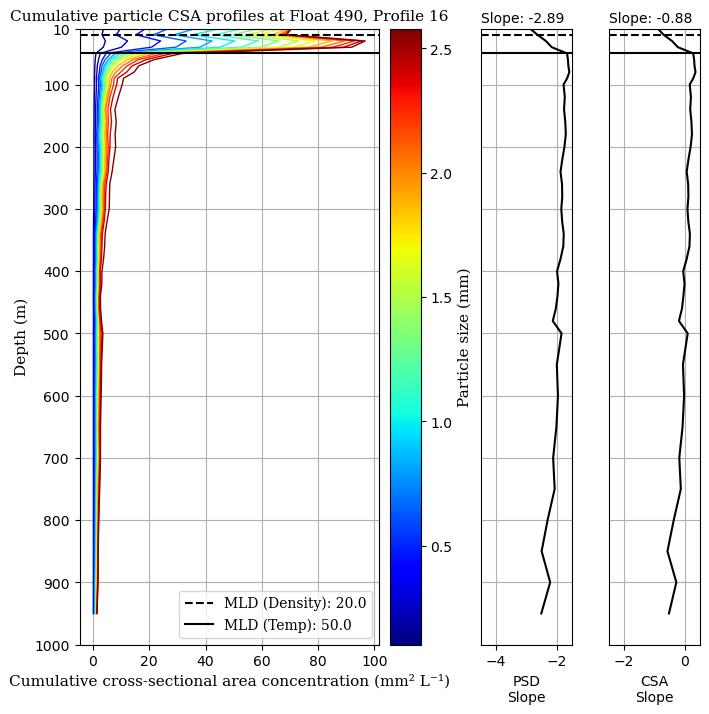

C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_7612\774621704.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\

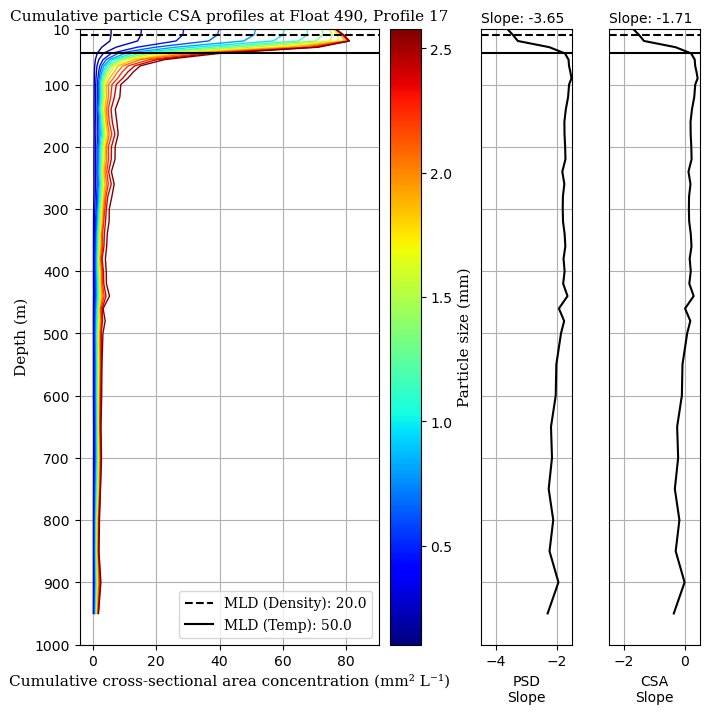

[np.float64(-2.8852761466976684), np.float64(-3.646963983836076)]
[np.float64(-0.8837151034375362), np.float64(-1.7072935515546277)]


ValueError: x and y must be the same size

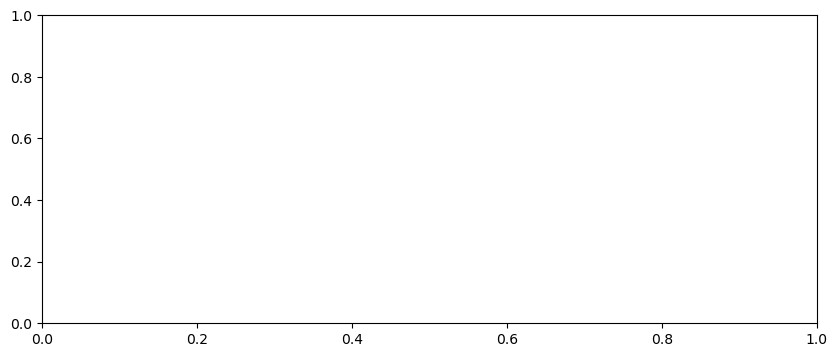

In [ ]:
## OBSERVATIONAL DATA DEPTH PROFILE (DIAGNOSTIC FIGURE) 

# pick profile that will be used as a diagnostic, maybe close to super station or something
# would need to calculate cross-sectional area of particles (method in notebook) for each size class
# then expand that over depth

mid_size = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data").iloc[3:18, 16]     # (size_mid_um)
mid_size.drop_duplicates()
mid_size = mid_size.to_numpy(dtype=float)
mid_size[-1] = 2580



# Choose which float and profile to investigate
UVP6_float = 490
number = np.arange(1, 43, 1)

PSD_initial = []
CSA_initial = []

for i in number:
    profile = getattr(f490, f"p{i}", None) #f490.p10  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

    if profile is None:
        print(f"p{i} not found")
        continue

    depth_obs = part_conc_490["depth_bin"].iloc[:60] # change title for 699 if needed

    # process profile here

    float_temp = temp_490[f"P{i}"]
    float_sal = sal_490[f"P{i}"]


    # Apply mid-size scaling
    # shape = (n_sizes, n_depth)
    concs = np.array([profile[s] for s in sizes], dtype=float)
    circle_scale = np.pi * ((mid_size / 2) ** 2)  # calculate the cross-sectional area of a circle for each mid-size
    cross_sectional_area = (concs * circle_scale[:, None]) / 1000000

    ## calculate mixed layer depth depending on profile
    # extract temperature and density from relevant biogeochemical float data
    # does that mean binning the temperature and density data to match the particle concentration depth bins?

    import gsw
    float_temp_CT = gsw.CT_from_t(float_sal, float_temp, depth_obs)
    float_density = gsw.rho(float_sal, float_temp_CT, depth_obs) - 1000                  ## look at this as either a) how I calculated density or b) the pressure values I fed into it, is wrong, as density MLD seems to be very shallow
                                                                              ## additionally look at the binning of temperature and density, maybe add a secondary y axis for continous depth to assess more accurately

    # reference values = first element
    ref_density = float_density[0]
    ref_temp = float_temp[0]

    # find first index where threshold is met
    density_diff = np.abs(float_density - ref_density)
    temp_diff = np.abs(float_temp - ref_temp)

    MLD_density_idx = np.where(density_diff >= 0.03)[0][0]
    MLD_temp_idx = np.where(temp_diff >= 0.2)[0][0]

    MLD_density = depth_obs[MLD_density_idx] + 10      # correction for surface? As the array calculates 20 m as 10 m
    MLD_temp = depth_obs[MLD_temp_idx] + 10


    PSD_results = []
    for d in range(concs.shape[1]): 
        PSD = psd_slope(sizes, concs[:, d], use_cumulative=False)
        PSD_results.append(PSD["slope"])

    PSD_initial.append(PSD_results[1])

    CSA_results = []
    for d in range(cross_sectional_area.shape[1]): 
        CSA_PSD = psd_slope(sizes, cross_sectional_area[:, d], use_cumulative=False)
        CSA_results.append(CSA_PSD["slope"])

    CSA_initial.append(CSA_results[1])

    # Plotting Cumulative stack

    fig, (ax, ax_psd, ax_csa) = plt.subplots(1, 3, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [4, 1, 1]})

    # cumulative sum across size bins
    cumulative = np.cumsum(cross_sectional_area, axis=0)

    # create a colour gradient
    cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
    colors = cmap(np.linspace(0, 1, len(sizes/1000)))

    # plot each cumulative boundary as a line
    for size_idx, s in enumerate(sizes):
        ax.plot(cumulative[size_idx], depth_obs,
            color=colors[size_idx],
            linewidth=1)

    '''
    # Writing respective runs to files
    CSA_max_profile = pd.DataFrame(cumulative[:, -1])

    with pd.ExcelWriter(f"Obs_Mid_Bloom_P{i}.xlsx") as writer:
        CSA_max_profile.to_excel(writer, sheet_name='CSA', index=False)
    '''

    ### CROSS-SECTIONAL AREA CONCENTRATION
    # Add mixed layer depth
    for a in (ax, ax_psd, ax_csa):
        a.axhline(y = MLD_density, color="black", linestyle="--", label=f"MLD (Density): {MLD_density}")    # as straight line across
        a.axhline(y = MLD_temp, color="black", linestyle="-", label=f"MLD (Temp): {MLD_temp}")    # as straight line across

    ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)", fontdict=font)
    ax.set_ylabel("Depth (m)", fontdict=font)
    ax.set_ylim(10, 1000)
    ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]) 
    ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {i}", fontdict=font)
    ax.legend(loc="lower right", prop=legend_font)
    ax.invert_yaxis()
    ax.grid()

    ### PSD (NUMBER METHOD)
    # PSD panel
    ax_psd.plot(PSD_results[1:], depth_obs[1:], color="black", linewidth=1.5)
    ax_psd.set_xlim(-4.5, -1.5)
    ax_psd.set_xlabel("PSD\nSlope")
    ax_psd.tick_params(axis="y", left=False, labelleft=False)
    ax_psd.text(-4.5, 0.5, f"Slope: {PSD_results[1]:.2f}")
    ax_psd.grid()

    ### PSD (CSA METHOD)
    ax_csa.plot(CSA_results[1:], depth_obs[1:], color="black", linewidth=1.5)
    ax_csa.set_xlim(-2.5, 0.5)
    ax_csa.set_xlabel("CSA\nSlope")
    ax_csa.tick_params(axis="y", left=False, labelleft=False)
    ax_csa.text(-2.5, 0.5, f"Slope: {CSA_results[1]:.2f}")
    ax_csa.grid()

    # Colourbar
    norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label("Particle size (mm)", fontdict=font)

    plt.savefig(f"Float_{UVP6_float}_p{i}.png", dpi=300)
    plt.show()

    plt.close()

print(PSD_initial)
print(CSA_initial)

df = pd.DataFrame(CSA_initial)
df.to_csv("CSA_PSD_initial_slopes_f490.csv")

filtered_number = number[(number != 13) & (number != 19)] 
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(filtered_number, PSD_initial, linewidth=2)
ax.plot(filtered_number, PSD_initial, linewidth=2)
ax.set_ylim(-2.0, -4.5)
ax.set_xlim(1, 43)
ax.set_title("Flux 1 Profiles: PSD Slope at 10 m", fontdict=font)
ax.set_ylabel("PSD slope", fontdict=font)
ax.set_xlabel("Profile no.", fontdict=font)
ax.grid()
plt.savefig("Float_490_surface_PSD_slopes.png", dpi=300)
plt.show()

filtered_number = number[(number != 13) & (number != 19)] 
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(filtered_number, CSA_initial, linewidth=2)
ax.plot(filtered_number, CSA_initial, linewidth=2)
ax.set_ylim(0, -2.5)
ax.set_xlim(1, 43)
ax.set_title("Flux 1 Profiles: PSD (CSA) Slope at 10 m", fontdict=font)
ax.set_ylabel("CSA PSD slope", fontdict=font)
ax.set_xlabel("Profile no.", fontdict=font)
ax.grid()
plt.savefig("Float_490_surface_CSA_slopes.png", dpi=300)
plt.show()



'''

# Choose which float and profile to investigate
UVP6_float = 699
number = np.arange(1, 65, 1)

PSD_initial = []
CSA_initial = []

for i in number:
    profile = getattr(f699, f"p{i}", None) #f490.p10  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

    if profile is None:
        print(f"p{i} not found")
        continue

    depth_obs = part_conc_699["depth_bin"].iloc[:60] # change title for 699 if needed
    
    # process profile here
    
    float_temp = temp_699[f"P{i}"]
    float_sal = sal_699[f"P{i}"]
    
    float_sal = pd.to_numeric(float_sal, errors="coerce")
    float_temp = pd.to_numeric(float_temp, errors="coerce")
    depth_obs = pd.to_numeric(depth_obs, errors="coerce")

    print(float_sal.dtype)
    print(float_temp.dtype)
    print(depth_obs.dtype)
    
    # Apply mid-size scaling
    # shape = (n_sizes, n_depth)
    concs = np.array([profile[s] for s in sizes], dtype=float)
    circle_scale = np.pi * ((mid_size / 2) ** 2)  # calculate the cross-sectional area of a circle for each mid-size
    cross_sectional_area = (concs * circle_scale[:, None]) / 1000000

    ## calculate mixed layer depth depending on profile
    # extract temperature and density from relevant biogeochemical float data
    # does that mean binning the temperature and density data to match the particle concentration depth bins?

    
    import gsw
    float_temp_CT = gsw.CT_from_t(float_sal, float_temp, depth_obs)
    float_density = gsw.rho(float_sal, float_temp_CT, depth_obs) - 1000                  ## look at this as either a) how I calculated density or b) the pressure values I fed into it, is wrong, as density MLD seems to be very shallow
                                                                              ## additionally look at the binning of temperature and density, maybe add a secondary y axis for continous depth to assess more accurately

    # reference values = first element
    ref_density = float_density[0]
    ref_temp = float_temp[0]

    # find first index where threshold is met
    density_diff = np.abs(float_density - ref_density)
    temp_diff = np.abs(float_temp - ref_temp)

    MLD_density_idx = np.where(density_diff >= 0.03)[0][0]
    MLD_temp_idx = np.where(temp_diff >= 0.2)[0][0]

    MLD_density = depth_obs[MLD_density_idx] + 10      # correction for surface? As the array calculates 20 m as 10 m
    MLD_temp = depth_obs[MLD_temp_idx] + 10
    

    PSD_results = []
    for d in range(concs.shape[1]): 
        PSD = psd_slope(sizes, concs[:, d], use_cumulative=False)
        PSD_results.append(PSD["slope"])

    PSD_initial.append(PSD_results[1])

    CSA_results = []
    for d in range(cross_sectional_area.shape[1]): 
        CSA_PSD = psd_slope(sizes, cross_sectional_area[:, d], use_cumulative=False)
        CSA_results.append(CSA_PSD["slope"])

    CSA_initial.append(CSA_results[1])

    # Plotting Cumulative stack

    fig, (ax, ax_psd, ax_csa) = plt.subplots(1, 3, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [4, 1, 1]})

    # cumulative sum across size bins
    cumulative = np.cumsum(cross_sectional_area, axis=0)

    # create a colour gradient
    cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
    colors = cmap(np.linspace(0, 1, len(sizes/1000)))

    print(f"Depth range: {depth_obs.min()} to {depth_obs.max()}")
    print(f"Concs shape: {concs.shape}")
    print(f"Cumulative shape: {cumulative.shape}")

    # plot each cumulative boundary as a line
    for size_idx, s in enumerate(sizes):
        ax.plot(cumulative[size_idx], depth_obs,
            color=colors[size_idx],
            linewidth=1)

    
    ### CROSS-SECTIONAL AREA CONCENTRATION
    
    # Add mixed layer depth
    for a in (ax, ax_psd, ax_csa):
        a.axhline(y = MLD_density, color="black", linestyle="--", label=f"MLD (Density): {MLD_density}")    # as straight line across
        a.axhline(y = MLD_temp, color="black", linestyle="-", label=f"MLD (Temp): {MLD_temp}")    # as straight line across
    
    ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)", fontdict=font)
    ax.set_ylabel("Depth (m)", fontdict=font)
    ax.set_ylim(10, 1000)
    ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {i}", fontdict=font)
    ax.legend(loc="lower right", prop=legend_font)
    ax.invert_yaxis()
    ax.grid()

    ### PSD (NUMBER METHOD)
    # PSD panel
    ax_psd.plot(PSD_results, depth_obs, color="black", linewidth=1.5)
    ax_psd.set_xlim(-5, 0)
    ax_psd.set_xlabel("PSD\nSlope")
    ax_psd.tick_params(axis="y", left=False, labelleft=False)
    ax_psd.text(-5, 0.5, f"Slope: {PSD_results[1]:.2f}")
    ax_psd.grid()

    ### PSD (CSA METHOD)
    ax_csa.plot(CSA_results, depth_obs, color="black", linewidth=1.5)
    ax_csa.set_xlim(-2.5, 0.5)
    ax_csa.set_xlabel("CSA\nSlope")
    ax_csa.tick_params(axis="y", left=False, labelleft=False)
    ax_csa.text(-2.5, 0.5, f"Slope: {CSA_results[1]:.2f}")
    ax_csa.grid()

    # Colourbar
    norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label("Particle size (mm)", fontdict=font)

    plt.savefig(f"Float_{UVP6_float}_p{i}.png", dpi=300)
    plt.show()

    plt.close()

print(PSD_initial)
print(CSA_initial)

filtered_number = number[(number != 4) & (number != 17) & (number != 29) 
& (number != 53) & (number != 72)] 
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(filtered_number, PSD_initial, linewidth=2)
ax.plot(filtered_number, PSD_initial, linewidth=2)
ax.set_ylabel("PSD slope", fontdict=font)
ax.set_xlabel("Profile no.", fontdict=font)
ax.set_title("Flux 2 Profiles: PSD Slope at 10 m", fontdict=font)
ax.invert_yaxis()
ax.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(filtered_number, CSA_initial, linewidth=2)
ax.plot(filtered_number, CSA_initial, linewidth=2)
ax.set_ylabel("CSA PSD slope", fontdict=font)
ax.set_xlabel("Profile no.", fontdict=font)
ax.set_title("Flux 2 Profiles: PSD (CSA) Slope at 10 m", fontdict=font)
ax.invert_yaxis()
ax.grid()
plt.show()
'''

ValueError: x and y must have same first dimension, but have shapes (1, 1) and (1000,)

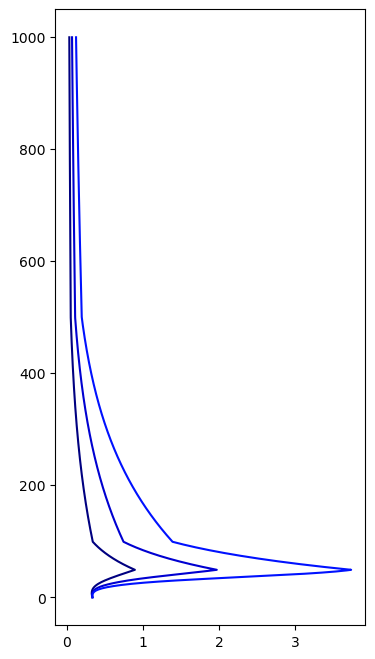

In [ ]:
# HAHA IS THAT ANOTHER CODE CELL HELP WHAT AM I DOING WITH MY LIFE

# stickiness can't be replicated
# STICKINESS # change this for each parameter
'''
def load_run(run_name):
    """
    Load all output sheets from a model run.
    """
    file = f"Model_Output_{run_name}.xlsx"

    state_variables = {
        "csa_profile": pd.read_excel(file, sheet_name="CSA")
    }

    return state_variables

#"Obs": "Obs_Mid_Bloom_P16",
obs = pd.read_excel("Obs_Mid_Bloom_P16.xlsx", header=None)

stickiness_hypothesis_runs = {
    "CSA1mil_turb1.1": "CSA1mil_turb1.1",
    "CSA1mil_turb1.8": "CSA1mil_turb1.8",
    "CSA1mil_turb2.5": "CSA1mil_turb2.5",
    #"CSA1mil_turb3.5": "CSA1mil_turb3.5",
}

stickiness_hypothesis_results = {label: load_run(filename)
                         for label, filename in stickiness_hypothesis_runs.items()}


# Plotting

fig, ax = plt.subplots(figsize=(4, 8))

for color, (label, run) in zip(colors, stickiness_hypothesis_results.items()):

    lw = 1.5
    ls = "-"
    ax.plot(run["csa_profile"].iloc[:, 31], depths, color=color, linewidth=lw, linestyle=ls, label=label)

ax.plot(obs, depths)
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
ax.set_xlabel("Cumulative CSA concentration (mm² L⁻¹)", fontdict=font)   # check units
ax.set_ylabel("Depth (m)", fontdict=font)
ax.set_ylim(10, 1000)
#ax.set_xscale("log")
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.legend(bbox_to_anchor=(0.95, 0.89), bbox_transform=fig.transFigure, prop=legend_font)
ax.invert_yaxis()
ax.grid()
plt.show()
'''




